In [199]:
import os
print(os.getcwd())  # Check

C:\Users\user\OneDrive\Desktop\ML


In [2]:
os.chdir("C:/Users/user/OneDrive/Desktop/ML")

In [3]:
print("New directory:", os.getcwd())

New directory: C:\Users\user\OneDrive\Desktop\ML


In [4]:
import pandas as pd
male = pd.read_csv("C:/Users/user/OneDrive/Desktop/ML/Male_features.csv")
female = pd.read_csv("C:/Users/user/OneDrive/Desktop/ML/Female_features.csv")


In [5]:


# Add a column to track gender
male["gender"] = "male"
female["gender"] = "female"

# Merge them
df = pd.concat([male, female], ignore_index=True)

print(df.shape)
df.head()


(85134, 60)


,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,labels,gender
0,-280.558350,118.419098,8.925080,29.063490,-17.713118,0.083584,-24.045542,-7.715221,-16.647551,-4.126383,...,4.785914,6.822370,6.465144,5.040742,4.462775,4.019160,3.692048,3.415411,happy,male
1,-138.495236,53.219675,19.017487,4.935156,-4.009660,-8.325881,-11.588456,-10.764145,-9.177705,-5.017083,...,3.079358,4.527467,5.122600,4.041961,2.732871,2.176067,2.955910,2.600446,happy,male
2,-299.933685,118.578461,8.348220,25.962524,-16.300257,-1.788243,-24.209568,-9.280386,-15.846799,-4.361415,...,4.882883,6.965629,6.520880,5.417891,4.888678,3.816338,3.659878,3.295839,happy,male
3,-280.343048,118.607193,9.081362,29.117228,-17.677935,0.041437,-24.069937,-7.778329,-16.729486,-4.217350,...,4.734492,6.781846,6.476598,5.069869,4.473549,4.050447,3.740353,3.456593,happy,male
4,-292.558380,121.191017,7.017522,22.656330,-19.091734,-3.386593,-26.960073,-7.652481,-17.392126,-0.461076,...,5.955528,6.064217,4.393935,4.429975,4.463602,4.980473,4.334596,4.759656,happy,male


In [6]:
df = pd.concat([male, female], ignore_index=True)

# Basic sanity
print(df.shape)
print(df.columns.tolist()[:10], "...")  # peek columns
print(df["labels"].value_counts())
print(df["gender"].value_counts())

(85134, 60)
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ...
labels
happy       13461
fear        13461
disgust     13461
angry       13461
sad         13461
neutral     11921
surprise     4564
calm         1344
Name: count, dtype: int64
gender
female    49224
male      35910
Name: count, dtype: int64


In [7]:
df = pd.concat([male, female], ignore_index=True)

# Basic sanity
print(df.shape)
print(df.columns.tolist()[:10], "...")  # peek columns
print(df["labels"].value_counts())
print(df["gender"].value_counts())

(85134, 60)
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ...
labels
happy       13461
fear        13461
disgust     13461
angry       13461
sad         13461
neutral     11921
surprise     4564
calm         1344
Name: count, dtype: int64
gender
female    49224
male      35910
Name: count, dtype: int64


In [8]:
df = pd.concat([male, female], ignore_index=True)

# Basic sanity
print(df.shape)
print(df.columns.tolist()[:10], "...")  # peek columns
print(df["labels"].value_counts())
print(df["gender"].value_counts())

(85134, 60)
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ...
labels
happy       13461
fear        13461
disgust     13461
angry       13461
sad         13461
neutral     11921
surprise     4564
calm         1344
Name: count, dtype: int64
gender
female    49224
male      35910
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

# Separate X / y
y = df["labels"].astype(str)
X = df.drop(columns=["labels"])

# Optionally one-hot encode gender (keeps it numeric)
X = pd.get_dummies(X, columns=["gender"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((68107, 59), (17027, 59))

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# a) Logistic Regression (good for interpretability)
logit = make_pipeline(
    StandardScaler(with_mean=False),  # sparse-safe & fast; works fine for numeric
    LogisticRegression(max_iter=200, n_jobs=-1, class_weight="balanced")
)
logit.fit(X_train, y_train)
y_pred_logit = logit.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logit))
print(classification_report(y_test, y_pred_logit))

# b) Random Forest (robust non-linear baseline)
rf = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced_subsample", n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== Logistic Regression ===
Accuracy: 0.4781817113995419
              precision    recall  f1-score   support

       angry       0.59      0.61      0.60      2692
        calm       0.29      0.94      0.44       269
     disgust       0.45      0.36      0.40      2692
        fear       0.43      0.34      0.38      2692
       happy       0.43      0.31      0.36      2693
     neutral       0.49      0.50      0.49      2384
         sad       0.52      0.58      0.55      2692
    surprise       0.45      0.80      0.58       913

    accuracy                           0.48     17027
   macro avg       0.46      0.56      0.48     17027
weighted avg       0.48      0.48      0.47     17027


=== Random Forest ===
Accuracy: 0.8789569507253187
              precision    recall  f1-score   support

       angry       0.87      0.94      0.90      2692
        calm       0.90      0.91      0.91       269
     disgust       0.88      0.83      0.85      2692
        fear       0.94

In [11]:
import numpy as np

importances = rf.feature_importances_
feat_names = np.array(X_train.columns)
idx = np.argsort(importances)[::-1][:15]

top_feats = pd.DataFrame({
    "feature": feat_names[idx],
    "importance": importances[idx]
})
top_feats


,feature,importance
0,0,0.075299
1,3,0.029874
2,2,0.028857
3,1,0.027636
4,17,0.026679
5,5,0.024314
6,10,0.023686
7,12,0.022473
8,4,0.021283
9,36,0.020764


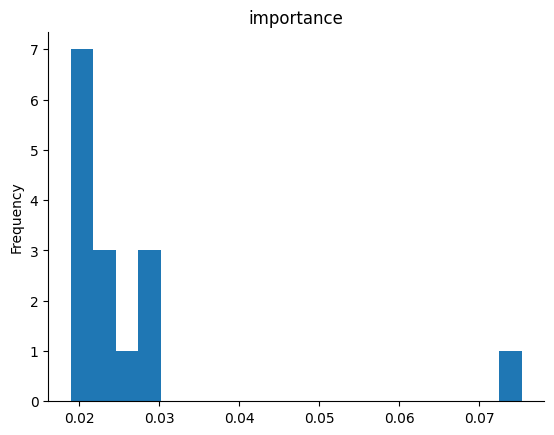

In [12]:
# @title importance

from matplotlib import pyplot as plt
top_feats['importance'].plot(kind='hist', bins=20, title='importance')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [13]:
# Pull the logistic regression step from the pipeline
logit_clf = logit.named_steps['logisticregression']
scaler    = logit.named_steps['standardscaler']

classes = logit_clf.classes_
coefs = logit_clf.coef_  # shape: [n_classes, n_features]

# Build nice per-class tables
per_class_top = {}
for cls, row in zip(classes, coefs):
    order = np.argsort(np.abs(row))[::-1][:10]
    per_class_top[cls] = pd.DataFrame({
        "feature": X_train.columns[order],
        "weight": row[order]
    })

per_class_top[classes[0]]  # peek one class


,feature,weight
0,0,1.334544
1,2,-0.838322
2,33,-0.408986
3,4,-0.408030
4,35,-0.398621
5,38,-0.396665
6,8,-0.396137
7,6,0.384070
8,36,0.293870
9,27,0.281560


In [14]:
def humanize_feature_name(name: str):
    """
    If your columns are plain indices (0,1,2...), leave as 'MFCC_0' etc.
    If you later rename them (e.g., 'mfcc_0','zcr','rms'), this function can map nicer text.
    """
    try:
        i = int(name)
        return f"MFCC_{i}"
    except:
        return name.replace("_", " ")

def summarize_rf_top(top_df, N=8):
    lines = []
    for i, row in top_df.head(N).iterrows():
        fname = humanize_feature_name(str(row['feature']))
        lines.append(f"• {fname} had notable influence (importance={row['importance']:.3f}).")
    return "\n".join(lines)

def summarize_logit_per_class(per_class_dict, N=5):
    out = []
    for cls, tbl in per_class_dict.items():
        pos = tbl.sort_values("weight", ascending=False).head(N)
        neg = tbl.sort_values("weight", ascending=True).head(N)
        pos_txt = ", ".join(humanize_feature_name(str(f)) for f in pos["feature"].tolist())
        neg_txt = ", ".join(humanize_feature_name(str(f)) for f in neg["feature"].tolist())
        out.append(
            f"For class '{cls}': higher values in [{pos_txt}] increased the odds, "
            f"while higher values in [{neg_txt}] decreased the odds."
        )
    return "\n\n".join(out)

print("=== Random Forest overall signals ===")
print(summarize_rf_top(top_feats, N=8))

print("\n=== Per-emotion patterns (Logistic) ===")
print(summarize_logit_per_class(per_class_top, N=5))


=== Random Forest overall signals ===
• MFCC_0 had notable influence (importance=0.075).
• MFCC_3 had notable influence (importance=0.030).
• MFCC_2 had notable influence (importance=0.029).
• MFCC_1 had notable influence (importance=0.028).
• MFCC_17 had notable influence (importance=0.027).
• MFCC_5 had notable influence (importance=0.024).
• MFCC_10 had notable influence (importance=0.024).
• MFCC_12 had notable influence (importance=0.022).

=== Per-emotion patterns (Logistic) ===
For class 'angry': higher values in [MFCC_0, MFCC_6, MFCC_36, MFCC_27, MFCC_8] increased the odds, while higher values in [MFCC_2, MFCC_33, MFCC_4, MFCC_35, MFCC_38] decreased the odds.

For class 'calm': higher values in [MFCC_8, MFCC_13, MFCC_30, gender male, MFCC_47] increased the odds, while higher values in [MFCC_0, MFCC_1, MFCC_3, MFCC_22, MFCC_39] decreased the odds.

For class 'disgust': higher values in [MFCC_10, MFCC_11, MFCC_1, MFCC_43, MFCC_0] increased the odds, while higher values in [MFCC_3

In [15]:
def train_eval_subset(df_sub):
    y = df_sub["labels"].astype(str)
    X = df_sub.drop(columns=["labels"])
    if "gender" in X.columns:
        X = pd.get_dummies(X, columns=["gender"], drop_first=True)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced_subsample', n_jobs=-1)
    model.fit(X_tr, y_tr)
    return model, X_tr, X_te, y_te

rf_male, Xm_tr, Xm_te, ym_te = train_eval_subset(df[df["gender"]=="male"])
rf_fem,  Xf_tr, Xf_te, yf_te = train_eval_subset(df[df["gender"]=="female"])

print("Male-only RF accuracy:", accuracy_score(ym_te, rf_male.predict(Xm_te)))
print("Female-only RF accuracy:", accuracy_score(yf_te, rf_fem.predict(Xf_te)))


Male-only RF accuracy: 0.8478139793929268
Female-only RF accuracy: 0.9111223971559167


In [16]:
# pick a local folder
out_dir = "./outputs/"
import os
os.makedirs(out_dir, exist_ok=True)

# save the CSVs
top_feats.to_csv(os.path.join(out_dir, "rf_top_features.csv"), index=False)

for cls, tbl in per_class_top.items():
    fname = f"logit_top_weights_{cls}.csv"
    tbl.to_csv(os.path.join(out_dir, fname), index=False)

print("Saved files:", os.listdir(out_dir))


Saved files: ['logit_top_weights_angry.csv', 'logit_top_weights_calm.csv', 'logit_top_weights_disgust.csv', 'logit_top_weights_fear.csv', 'logit_top_weights_happy.csv', 'logit_top_weights_neutral.csv', 'logit_top_weights_sad.csv', 'logit_top_weights_surprise.csv', 'rf_top_features.csv']


In [17]:
# make a small stratified slice of the TRAIN set
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=42)  # keep 20% of X_train
idx_small,_ = next(sss.split(X_train, y_train))
X_small, y_small = X_train.iloc[idx_small], y_train.iloc[idx_small]

# randomized search on the tiny slice
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators":[200,400,600],
    "max_depth":[None,30],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2],
    "max_features":["sqrt"]  # fixes feature subsampling; faster and usually strong
}
rf = RandomForestClassifier(random_state=42, class_weight="balanced_subsample", n_jobs=-1)
rand = RandomizedSearchCV(rf, param_dist, n_iter=8, cv=2, scoring="f1_weighted", n_jobs=-1, random_state=42)
rand.fit(X_small, y_small)
print("Best (small) params:", rand.best_params_)

# retrain BEST model on the FULL training set
best = RandomForestClassifier(**rand.best_params_, random_state=42, class_weight="balanced_subsample", n_jobs=-1)
best.fit(X_train, y_train)
print("Full-train accuracy:", best.score(X_test, y_test))


Best (small) params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Full-train accuracy: 0.881247430551477


              precision    recall  f1-score   support

       angry      0.868     0.941     0.903      2692
        calm      0.892     0.922     0.907       269
     disgust      0.887     0.832     0.859      2692
        fear      0.942     0.825     0.880      2692
       happy      0.881     0.861     0.871      2693
     neutral      0.859     0.889     0.874      2384
         sad      0.832     0.909     0.869      2692
    surprise      0.968     0.961     0.964       913

    accuracy                          0.881     17027
   macro avg      0.891     0.892     0.891     17027
weighted avg      0.884     0.881     0.881     17027



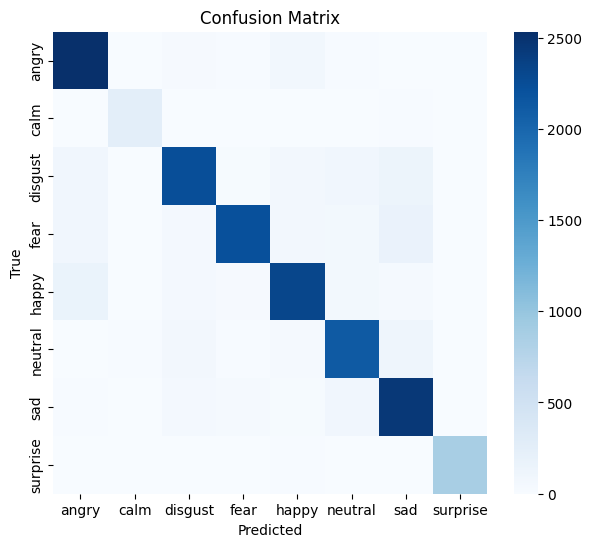

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

y_pred = best.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=best.classes_)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=best.classes_, yticklabels=best.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix"); plt.show()


In [19]:
male_only   = df[df['gender']=='male']
female_only = df[df['gender']=='female']

def fit_eval(sub):
    y=sub['labels']; X=pd.get_dummies(sub.drop(columns=['labels']), columns=['gender'], drop_first=True)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    m=RandomForestClassifier(**best.get_params()); m.fit(Xtr,ytr)
    return m.score(Xte,yte)

print("Male-only:", fit_eval(male_only))
print("Female-only:", fit_eval(female_only))

# Train on male, test on female (and reverse)
def train_on_A_test_on_B(A,B):
    yA=A['labels']; XA=pd.get_dummies(A.drop(columns=['labels']), columns=['gender'], drop_first=True)
    yB=B['labels']; XB=pd.get_dummies(B.drop(columns=['labels']), columns=['gender'], drop_first=True).reindex(columns=XA.columns, fill_value=0)
    m=RandomForestClassifier(**best.get_params()); m.fit(XA,yA)
    from sklearn.metrics import accuracy_score
    return accuracy_score(yB, m.predict(XB))

print("Train male → test female:", train_on_A_test_on_B(male_only,female_only))
print("Train female → test male:", train_on_A_test_on_B(female_only,male_only))


Male-only: 0.852548036758563
Female-only: 0.9107160995429152
Train male → test female: 0.2781569965870307
Train female → test male: 0.33238652186020606


In [20]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs=[]
for tr, te in skf.split(X, y):
    m=RandomForestClassifier(**best.get_params()); m.fit(X.iloc[tr], y.iloc[tr])
    accs.append(m.score(X.iloc[te], y.iloc[te]))
print("CV mean±sd:", np.mean(accs), np.std(accs))


CV mean±sd: 0.8803297960630807 0.0018434804734227751


In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# pick feature columns
feat_cols = [c for c in df.columns if c not in ["labels","gender"]]

# row-wise z-score: (x - row_mean)/row_std
X_feats = df[feat_cols]
row_mean = X_feats.mean(axis=1)
row_std  = X_feats.std(axis=1) + 1e-8
X_rowz   = (X_feats.sub(row_mean, axis=0)).div(row_std, axis=0)

# rebuild X with gender (one-hot)
X = pd.concat([X_rowz, pd.get_dummies(df["gender"], prefix="gender", drop_first=True)], axis=1)
y = df["labels"].astype(str)

# split + train with your tuned params
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
best = RandomForestClassifier(
    n_estimators=400, max_depth=30, max_features='sqrt',
    min_samples_split=2, min_samples_leaf=1,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
best.fit(X_train, y_train)
print("Row‑wise z-score accuracy:", accuracy_score(y_test, best.predict(X_test)))


Row‑wise z-score accuracy: 0.8670934398308568


In [22]:
def prep(df_sub):
    feats = [c for c in df_sub.columns if c not in ["labels","gender"]]
    Xm = df_sub[feats]
    rm = Xm.mean(axis=1); rs = Xm.std(axis=1)+1e-8
    Xz = (Xm.sub(rm, axis=0)).div(rs, axis=0)
    Xz = pd.concat([Xz, pd.get_dummies(df_sub["gender"], prefix="gender", drop_first=True)], axis=1)
    y  = df_sub["labels"].astype(str)
    return Xz, y

male_df   = df[df["gender"]=="male"].copy()
female_df = df[df["gender"]=="female"].copy()

Xm, ym = prep(male_df)
Xf, yf = prep(female_df)

# Train male → test female
m = RandomForestClassifier(n_estimators=400, max_depth=30, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=1,
                           class_weight="balanced_subsample", random_state=42, n_jobs=-1)
m.fit(Xm, ym)
from sklearn.metrics import accuracy_score
print("male→female:", accuracy_score(yf, m.predict(Xf)))


male→female: 0.2681618722574354


In [23]:
!pip -q install lightgbm xgboost


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import numpy as np

# df with columns: 59 numeric features + 'labels' + 'gender'
feat_cols = [c for c in df.columns if c not in ["labels","gender"]]

X_feats = df[feat_cols]
row_mean = X_feats.mean(axis=1); row_std = X_feats.std(axis=1) + 1e-8
Xz = (X_feats.sub(row_mean, axis=0)).div(row_std, axis=0)

X_full = pd.concat([Xz, pd.get_dummies(df["gender"], prefix="gender", drop_first=True)], axis=1)
y_full = df["labels"].astype(str)


In [30]:
from sklearn.model_selection import train_test_split

def split_xy(X, y, test_size=0.2, seed=42):
    return train_test_split(X, y, test_size=test_size, stratify=y, random_state=seed)

def prep_subset(dsub: pd.DataFrame):
    feats = [c for c in dsub.columns if c not in ["labels","gender"]]
    Xm = dsub[feats]
    rm = Xm.mean(axis=1); rs = Xm.std(axis=1) + 1e-8
    Xz = (Xm.sub(rm, axis=0)).div(rs, axis=0)
    Xz = pd.concat([Xz, pd.get_dummies(dsub["gender"], prefix="gender", drop_first=True)], axis=1)
    y  = dsub["labels"].astype(str)
    return Xz, y

male_df   = df[df["gender"]=="male"].copy()
female_df = df[df["gender"]=="female"].copy()

Xm, ym = prep_subset(male_df)
Xf, yf = prep_subset(female_df)


In [31]:
from sklearn.model_selection import train_test_split

def split_xy(X, y, test_size=0.2, seed=42):
    return train_test_split(X, y, test_size=test_size, stratify=y, random_state=seed)

def prep_subset(dsub: pd.DataFrame):
    feats = [c for c in dsub.columns if c not in ["labels","gender"]]
    Xm = dsub[feats]
    rm = Xm.mean(axis=1); rs = Xm.std(axis=1) + 1e-8
    Xz = (Xm.sub(rm, axis=0)).div(rs, axis=0)
    Xz = pd.concat([Xz, pd.get_dummies(dsub["gender"], prefix="gender", drop_first=True)], axis=1)
    y  = dsub["labels"].astype(str)
    return Xz, y

male_df   = df[df["gender"]=="male"].copy()
female_df = df[df["gender"]=="female"].copy()

Xm, ym = prep_subset(male_df)
Xf, yf = prep_subset(female_df)


In [32]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

models = {
    "RF": RandomForestClassifier(
        n_estimators=400, max_depth=30, max_features='sqrt',
        min_samples_split=2, min_samples_leaf=1,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=800, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        class_weight="balanced", random_state=42
    ),
    "SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced"))
}


In [33]:
import numpy as np, pandas as pd
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# X, y from row-wise z-scored setup
feat_cols = [c for c in df.columns if c not in ["labels","gender"]]
X_feats = df[feat_cols]
rm, rs = X_feats.mean(axis=1), X_feats.std(axis=1) + 1e-8
Xz = (X_feats.sub(rm, axis=0)).div(rs, axis=0)
X = pd.concat([Xz, pd.get_dummies(df["gender"], prefix="gender", drop_first=True)], axis=1)

# clean labels -> integers (LightGBM likes this)
le = LabelEncoder()
y = le.fit_transform(df["labels"].astype(str))  # e.g., 0..K-1

# sanitize features
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)  # or .fillna(X.median())

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# conservative LightGBM (fewer leaves, min gain/leaf)
lgb = LGBMClassifier(
    objective="multiclass",
    num_class=len(np.unique(y)),
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=31,          # smaller = smoother trees
    max_depth=-1,           # let leaves control depth
    min_data_in_leaf=40,    # more samples per leaf
    min_gain_to_split=1e-3, # require tiny positive gain
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    reg_alpha=0.0, reg_lambda=1.0,
    random_state=42,
    verbose=-1              # silence warnings
)

lgb.fit(X_train, y_train)
pred = lgb.predict(X_test)
print("LightGBM accuracy:", accuracy_score(y_test, pred))


LightGBM accuracy: 0.8400775239325776


In [34]:
import numpy as np, pandas as pd, gc
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# (RE)LOAD DATAFRAME df 

import pandas as pd
male = pd.read_csv("C:/Users/user/OneDrive/Desktop/ML/Male_features.csv"); male["gender"]="male"
female = pd.read_csv("C:/Users/user/OneDrive/Desktop/ML/Female_features.csv"); female["gender"]="female"
df = pd.concat([male, female], ignore_index=True)

assert 'df' in globals(), "Reload your CSVs and rebuild `df` before running."

# Row-wise z-score (RAM-lean, float32) 
feat_cols = [c for c in df.columns if c not in ["labels","gender"]]
X = df[feat_cols].to_numpy(dtype=np.float32)
y_text = df["labels"].astype(str).to_numpy()
g_num = (df["gender"].to_numpy()=="female").astype(np.int8)

rm = X.mean(axis=1, keepdims=True)
rs = X.std(axis=1, keepdims=True) + 1e-8
Xz = (X - rm) / rs  # float32

# encode labels to 0..K-1 
le = LabelEncoder()
y = le.fit_transform(y_text)

# helper to fit/eval one model
def fit_eval_xgb(Xtr, ytr, Xte, yte, seed=42):
    clf = XGBClassifier(
        objective="multi:softmax",
        num_class=len(np.unique(y)),
        tree_method="hist",          
        eval_metric="mlogloss",
        n_estimators=600,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,          # regularize
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1
    )
    clf.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
    return accuracy_score(yte, clf.predict(Xte)), clf

# POOLED evaluation 
Xtr, Xte, ytr, yte = train_test_split(Xz, y, test_size=0.2, stratify=y, random_state=42)
acc_pooled, xgb_pooled = fit_eval_xgb(Xtr, ytr, Xte, yte)
print(f"XGBoost pooled test acc: {acc_pooled:.3f}")

# WITHIN- and CROSS-gender 
male_idx   = (df["gender"].to_numpy()=="male")
female_idx = ~male_idx

Xm, ym = Xz[male_idx],   y[male_idx]
Xf, yf = Xz[female_idx], y[female_idx]

# within male
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.2, stratify=ym, random_state=42)
acc_male,   mdl_m = fit_eval_xgb(Xm_tr, ym_tr, Xm_te, ym_te)
# within female
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.2, stratify=yf, random_state=42)
acc_female, mdl_f = fit_eval_xgb(Xf_tr, yf_tr, Xf_te, yf_te)

# cross: train on male, test on female; and reverse
acc_m2f = accuracy_score(yf, mdl_m.predict(Xf))
acc_f2m = accuracy_score(ym, mdl_f.predict(Xm))

print(f"XGBoost male-only:   {acc_male:.3f}")
print(f"XGBoost female-only: {acc_female:.3f}")
print(f"XGBoost male→female: {acc_m2f:.3f}")
print(f"XGBoost female→male: {acc_f2m:.3f}")

# free a bit of memory
del X, Xz, Xtr, Xte, Xm_tr, Xm_te, Xf_tr, Xf_te; gc.collect()



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


XGBoost pooled test acc: 0.867
XGBoost male-only:   0.851
XGBoost female-only: 0.916
XGBoost male→female: 0.268
XGBoost female→male: 0.308


216

In [35]:
!pip -q install lightgbm xgboost shap

import os, gc, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
import shap, joblib
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.width", 140)



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd

male   = pd.read_csv("./Male_features.csv");   male["gender"]   = "male"
female = pd.read_csv("./Female_features.csv"); female["gender"] = "female"

# Combine into one DataFrame
df = pd.concat([male, female], ignore_index=True)

# Infer feature columns (exclude labels + gender)
FEATS = [c for c in df.columns if c not in ("labels", "gender")]

# Quick checks
print(df.shape, df['labels'].nunique(), "classes | gender counts:\n", df['gender'].value_counts())


(85134, 60) 8 classes | gender counts:
 gender
female    49224
male      35910
Name: count, dtype: int64


In [38]:
def row_z(X):  # per-sample z-score
    X = X.astype(np.float32, copy=False)
    m = X.mean(axis=1, keepdims=True); s = X.std(axis=1, keepdims=True) + 1e-8
    return (X - m) / s

def make_xy(d: pd.DataFrame):
    X = d[FEATS].to_numpy(np.float32)
    y_text = d["labels"].astype(str).to_numpy()
    Xz = row_z(X)
    le = LabelEncoder()
    y = le.fit_transform(y_text)
    return Xz, y, le

def rf_model():
    return RandomForestClassifier(
        n_estimators=400, max_depth=30, max_features='sqrt',
        min_samples_split=2, min_samples_leaf=1,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1
    )

def lgbm_model(num_class):
    return LGBMClassifier(
        objective="multiclass", num_class=num_class,
        n_estimators=600, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        min_data_in_leaf=40, min_gain_to_split=1e-3,
        class_weight="balanced", random_state=42, verbose=-1
    )

def xgb_model(num_class):
    return XGBClassifier(
        objective="multi:softmax", num_class=num_class,
        tree_method="hist", eval_metric="mlogloss",
        n_estimators=600, learning_rate=0.05,
        max_depth=8, subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, reg_lambda=1.0, random_state=42, n_jobs=-1
    )

def eval_split(clf, X, y, test_size=0.2, seed=42, title=""):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, stratify=y, random_state=seed)
    clf.fit(Xtr, ytr)
    acc = accuracy_score(yte, clf.predict(Xte))
    print(f"{title} acc: {acc:.3f}")
    return acc, clf, (Xtr, Xte, ytr, yte)


In [39]:
# Pooled baseline (RF)
Xz, y, le = make_xy(df)
acc_pooled, rf_pool, _ = eval_split(rf_model(), Xz, y, title="RF pooled")

# Gender-router (two models)
male_df   = df[df.gender=="male"].copy()
female_df = df[df.gender=="female"].copy()
Xm, ym, _ = make_xy(male_df)
Xf, yf, _ = make_xy(female_df)

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.2, stratify=ym, random_state=42)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.2, stratify=yf, random_state=42)

m_model = rf_model().fit(Xm_tr, ym_tr)
f_model = rf_model().fit(Xf_tr, yf_tr)

print("Router male-only acc  :", accuracy_score(ym_te, m_model.predict(Xm_te)))
print("Router female-only acc:", accuracy_score(yf_te, f_model.predict(Xf_te)))


RF pooled acc: 0.867
Router male-only acc  : 0.841687552213868
Router female-only acc: 0.8992381919756222


In [40]:
from sklearn.decomposition import PCA

def pca_gender_scrub(Xz, g_binary, k=1):
    # PCA on features
    pca = PCA(n_components=min(Xz.shape[1], 60), svd_solver='full', random_state=42)
    Z = pca.fit_transform(Xz.astype(np.float32))
    # correlate PCs with gender (0/1)
    cors = [np.corrcoef(Z[:,i], g_binary)[0,1] for i in range(Z.shape[1])]
    order = np.argsort(np.abs(cors))[::-1][:k]
    Z[:, order] = 0.0  # zero out top-k gender PCs
    Xr = pca.inverse_transform(Z).astype(np.float32)
    return Xr, cors, order

g_bin = (df["gender"].to_numpy()=="female").astype(np.int8)
for k in [1,2,3]:
    Xr, cors, dropped = pca_gender_scrub(Xz, g_bin, k=k)
    acc, _, _ = eval_split(rf_model(), Xr, y, title=f"RF pooled (PCA-scrub k={k})")
    print("Dropped PCs:", dropped, "corrs:", [round(cors[i],3) for i in dropped])


RF pooled (PCA-scrub k=1) acc: 0.877
Dropped PCs: [0] corrs: [np.float64(-0.3)]
RF pooled (PCA-scrub k=2) acc: 0.878
Dropped PCs: [0 1] corrs: [np.float64(-0.3), np.float64(-0.256)]
RF pooled (PCA-scrub k=3) acc: 0.875
Dropped PCs: [ 0  1 20] corrs: [np.float64(-0.3), np.float64(-0.256), np.float64(-0.243)]


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# gender propensity model
prop = make_pipeline(StandardScaler(with_mean=True, with_std=True),
                     LogisticRegression(max_iter=1500, solver="lbfgs", class_weight="balanced"))
prop.fit(Xz, g_bin)
p_female = prop.predict_proba(Xz)[:,1]
# target 50/50 gender; weights = target_prob / predicted_prob for each sample's gender
w = np.where(g_bin==1, 0.5/(p_female+1e-6), 0.5/(1-p_female+1e-6))

Xtr, Xte, ytr, yte, wtr, wte = train_test_split(Xz, y, w, test_size=0.2, stratify=y, random_state=42)
rf_w = rf_model().fit(Xtr, ytr, sample_weight=wtr)
print("RF pooled (propensity-weighted) acc:", accuracy_score(yte, rf_w.predict(Xte)))


RF pooled (propensity-weighted) acc: 0.8628061314383039


In [42]:
from numpy.linalg import eigh

def coral_fit_transform(Xs, Xt, eps=1e-4):
    Xs_c = Xs - Xs.mean(0, keepdims=True); Xt_c = Xt - Xt.mean(0, keepdims=True)
    Cs = (Xs_c.T @ Xs_c) / max(1, Xs_c.shape[0]-1) + np.eye(Xs.shape[1], dtype=np.float32)*eps
    Ct = (Xt_c.T @ Xt_c) / max(1, Xt_c.shape[0]-1) + np.eye(Xt.shape[1], dtype=np.float32)*eps
    Es, Vs = eigh(Cs); Ws = Vs @ np.diag((np.maximum(Es,eps))**-0.5) @ Vs.T
    Et, Vt = eigh(Ct); Wt = Vt @ np.diag((np.maximum(Et,eps))**0.5)  @ Vt.T
    return ((Xs_c @ Ws @ Wt) + Xt.mean(0, keepdims=True)).astype(np.float32)

# male→female
Xm_al = coral_fit_transform(Xm, Xf)
rf = rf_model().fit(Xm_al, ym)
print("CORAL male→female acc:", accuracy_score(yf, rf.predict(Xf)))

# female→male
Xf_al = coral_fit_transform(Xf, Xm)
rf = rf_model().fit(Xf_al, yf)
print("CORAL female→male acc:", accuracy_score(ym, rf.predict(Xm)))


CORAL male→female acc: 0.26153908662441083
CORAL female→male acc: 0.27418546365914787


In [43]:
import os, joblib, pandas as pd

# Save cache in a local folder relative to notebook
SAVE_DIR = "./ser_cache"
os.makedirs(SAVE_DIR, exist_ok=True)

# Point to local CSV files 
male_path   = "./Male_features.csv"
female_path = "./Female_features.csv"

male   = pd.read_csv(male_path);   male["gender"]   = "male"
female = pd.read_csv(female_path); female["gender"] = "female"

# Combine datasets
df = pd.concat([male, female], ignore_index=True)

# Quick sanity checks
print("df shape:", df.shape)
print("columns example:", df.columns[:8].tolist())
print(df["gender"].value_counts())

# Save cached dataframe as pickle
out_path = os.path.join(SAVE_DIR, "df.pkl")
joblib.dump(df, out_path)
print("Cached:", out_path)


df shape: (85134, 60)
columns example: ['0', '1', '2', '3', '4', '5', '6', '7']
gender
female    49224
male      35910
Name: count, dtype: int64
Cached: ./ser_cache\df.pkl


In [44]:
import os, joblib, shutil

# Define save directories
save_dir_local = "./ser_models"
save_dir_backup = "./ser_models_backup"   # optional backup folder
os.makedirs(save_dir_local, exist_ok=True)
os.makedirs(save_dir_backup, exist_ok=True)

# Save models + features (compressed pickle)
joblib.dump(m_model,   os.path.join(save_dir_local, "rf_male.pkl"),   compress=1)
joblib.dump(f_model,   os.path.join(save_dir_local, "rf_female.pkl"), compress=1)
joblib.dump(FEATS,     os.path.join(save_dir_local, "feature_names.pkl"), compress=1)

# Copy to backup folder (like you did with Drive in Colab)
for fn in ["rf_male.pkl", "rf_female.pkl", "feature_names.pkl"]:
    shutil.copy2(os.path.join(save_dir_local, fn),
                 os.path.join(save_dir_backup, fn))

print("Saved locally in", save_dir_local, "and copied to", save_dir_backup)


Saved locally in ./ser_models and copied to ./ser_models_backup


In [45]:
import joblib, numpy as np
import os

def row_z(x):
    mu = x.mean(axis=1, keepdims=True)
    sd = x.std(axis=1, keepdims=True) + 1e-8
    return (x - mu) / sd

# Load once (from local cache; fallback to backup folder)
def load_router(model_dir="./ser_models", fallback="./ser_models_backup"):
    try:
        rf_m   = joblib.load(os.path.join(model_dir, "rf_male.pkl"))
        rf_f   = joblib.load(os.path.join(model_dir, "rf_female.pkl"))
        feats  = joblib.load(os.path.join(model_dir, "feature_names.pkl"))
    except Exception:
        rf_m   = joblib.load(os.path.join(fallback, "rf_male.pkl"))
        rf_f   = joblib.load(os.path.join(fallback, "rf_female.pkl"))
        feats  = joblib.load(os.path.join(fallback, "feature_names.pkl"))
    return rf_m, rf_f, feats

RF_MALE, RF_FEMALE, FEATS = load_router()


In [46]:
def predict_emotion_row(feature_row: np.ndarray, gender: str):
    x = np.asarray(feature_row, dtype=np.float32).reshape(1, -1)
    xz = row_z(x)
    mdl = RF_MALE if gender.lower()=="male" else RF_FEMALE
    proba = mdl.predict_proba(xz)[0]
    return mdl.classes_[np.argmax(proba)], float(np.max(proba))

# batch (DataFrame with same feature columns, optional 'gender')
import pandas as pd
def predict_batch(df_new: pd.DataFrame, gender_col="gender", default_gender="male"):
    # ensure same column order; add missing as 0
    for c in FEATS:
        if c not in df_new.columns:
            df_new[c] = 0.0
    X = df_new[FEATS].to_numpy(np.float32)
    Xz = row_z(X)

    genders = df_new[gender_col].fillna(default_gender).str.lower() if gender_col in df_new.columns else pd.Series([default_gender]*len(df_new))
    mask_m = genders.eq("male").to_numpy()
    mask_f = ~mask_m

    preds = np.empty(len(df_new), dtype=object)
    confs = np.empty(len(df_new), dtype=np.float32)

    if mask_m.any():
        proba_m = RF_MALE.predict_proba(Xz[mask_m])
        idx_m   = np.argmax(proba_m, axis=1)
        preds[mask_m] = RF_MALE.classes_[idx_m]
        confs[mask_m] = proba_m[np.arange(len(idx_m)), idx_m]
    if mask_f.any():
        proba_f = RF_FEMALE.predict_proba(Xz[mask_f])
        idx_f   = np.argmax(proba_f, axis=1)
        preds[mask_f] = RF_FEMALE.classes_[idx_f]
        confs[mask_f] = proba_f[np.arange(len(idx_f)), idx_f]

    out = df_new.copy()
    out["pred"] = preds
    out["conf"] = confs
    return out


In [48]:
import pandas as pd, numpy as np
from sklearn.metrics import accuracy_score, classification_report

# load your CSV locally
newdf = pd.read_csv("./features.csv")   # adjust path if needed
print("newdf shape:", newdf.shape)

# check feature alignment vs training FEATS
missing = [c for c in FEATS if c not in newdf.columns]
extra   = [c for c in newdf.columns if c not in FEATS + ["labels","gender"]]
print(f"features expected: {len(FEATS)} | present: {sum(c in newdf.columns for c in FEATS)}")
print("missing (first 20):", missing[:20])
print("extra   (first 20):", extra[:20])

# add missing features as zeros, align column order
for c in missing:
    newdf[c] = 0.0
X_aligned = newdf[FEATS].to_numpy(np.float32)

# row-wise z-score (same as training)
def row_z(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mu) / sd

Xz = row_z(X_aligned)

# dual-gender routing: run both models, choose higher-confidence
proba_m = RF_MALE.predict_proba(Xz)
proba_f = RF_FEMALE.predict_proba(Xz)

idx_m = proba_m.argmax(1); conf_m = proba_m[np.arange(len(idx_m)), idx_m]
idx_f = proba_f.argmax(1); conf_f = proba_f[np.arange(len(idx_f)), idx_f]

label_m = RF_MALE.classes_[idx_m]
label_f = RF_FEMALE.classes_[idx_f]

pick_female   = conf_f > conf_m
chosen_label  = np.where(pick_female, label_f, label_m)
chosen_conf   = np.where(pick_female, conf_f, conf_m)
chosen_gender = np.where(pick_female, "female", "male")

results = newdf.copy()
results["pred"]   = chosen_label
results["conf"]   = chosen_conf
results["routed"] = chosen_gender

print(results.head())

# apply confidence threshold (reject low-confidence)
THRESH = 0.60
results["final_pred"] = results["pred"]
results.loc[results["conf"] < THRESH, "final_pred"] = "UNSURE"

# if ground-truth labels exist, evaluate
if "labels" in newdf.columns:
    y_true = newdf["labels"].astype(str).values
    acc    = accuracy_score(y_true, results["pred"])
    print(f"\nRaw accuracy (no reject): {acc:.3f}")
    print("\nClassification report:\n", classification_report(y_true, results["pred"], digits=3))
    # with reject
    keep = results["final_pred"] != "UNSURE"
    if keep.any():
        acc_kept = accuracy_score(y_true[keep], results.loc[keep,"final_pred"])
        cov = keep.mean()
        print(f"\nWith threshold {THRESH}: coverage={cov:.2f}, accuracy_on_kept={acc_kept:.3f}")

# save predictions locally
out_path = "./predictions_ravdess.csv"
results.to_csv(out_path, index=False)
print("\nsaved:", out_path)


newdf shape: (4320, 21)
features expected: 58 | present: 20
missing (first 20): ['20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39']
extra   (first 20): []
            0           1          2          3          4         5          6         7          8         9  ...   51   52   53   54  \
0 -637.701233  104.299019   4.894947  20.494011  12.552954  2.851410  -6.633390 -4.091278 -10.423918 -6.406950  ...  0.0  0.0  0.0  0.0   
1 -596.908460   86.871936   9.470162  17.109819  11.198966  1.541056  -6.677264 -5.755428  -9.684472 -6.891256  ...  0.0  0.0  0.0  0.0   
2 -698.086548   99.795929   1.892679  19.915264   7.532868  1.265761  -9.188656 -5.798194 -12.299710 -4.976400  ...  0.0  0.0  0.0  0.0   
3 -279.141052   41.092949 -21.319229   7.802911 -13.140503 -9.407660 -15.580647 -6.097223 -24.700903 -9.640293  ...  0.0  0.0  0.0  0.0   
4 -160.074686   17.576058  -2.147436   3.133417  -4.745002 -6.510771  -5.911591 -

C:\Users\user\AppData\Local\Temp\ipykernel_9224\564853810.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'UNSURE' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results.loc[results["conf"] < THRESH, "final_pred"] = "UNSURE"


ValueError: Mix of label input types (string and number)

In [50]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# 1) helpers
def normalize_label(s: str) -> str:
    s = str(s).strip().lower()
    if s.startswith("male_"): s = s[5:]
    if s.startswith("female_"): s = s[7:]
    return s

LABEL_MAP = {
    "happiness": "happy",
    "joy": "happy",
    "sadness": "sad",
    "surprised": "surprise",
    "boredom": "neutral",
}

def harmonize(s: str) -> str:
    s = normalize_label(s)
    return LABEL_MAP.get(s, s)

# get union of training class names (normalized)
train_classes_m = [normalize_label(x) for x in RF_MALE.classes_]
train_classes_f = [normalize_label(x) for x in RF_FEMALE.classes_]
train_union = sorted(set(train_classes_m) | set(train_classes_f))
print("Training classes (normalized):", train_union)

# predicted labels → normalize too
pred_norm = results["pred"].astype(str).map(harmonize)

# ground-truth labels → normalize + harmonize
if "labels" not in results.columns:
    raise RuntimeError("No 'labels' column in your CSV to evaluate against.")

y_true_norm = results["labels"].astype(str).map(harmonize)

# keep only rows whose TRUE label exists in the training union
seen_mask = y_true_norm.isin(train_union)

print(f"Rows with in-vocabulary labels: {seen_mask.mean():.2%}")
if not seen_mask.any():
    print("\nNothing to evaluate because NONE of the ground-truth labels match the training label set.")
    print("Examples of ground-truth (normalized):", sorted(results["labels"].astype(str).map(normalize_label).unique())[:10])
    print("Consider adjusting LABEL_MAP above (e.g., calm→neutral) to match your training classes.")
else:
    y_true_eval = y_true_norm[seen_mask]
    y_pred_eval = pred_norm[seen_mask]

    # quick sanity: show any remaining labels that still don't overlap
    remaining_unseen = set(y_true_eval.unique()) - set(train_union)
    if remaining_unseen:
        print("[warn] These labels are still not in training union after mapping:", remaining_unseen)

    # accuracy + report
    acc = accuracy_score(y_true_eval, y_pred_eval)
    print(f"\nRaw accuracy (no reject): {acc:.3f}")
    print("\nClassification report:\n", classification_report(y_true_eval, y_pred_eval, digits=3))

    # thresholded (reject low-confidence)
    THRESH = 0.60
    kept = (results.loc[seen_mask, "conf"].to_numpy() >= THRESH)
    if kept.any():
        acc_kept = accuracy_score(y_true_eval[kept], y_pred_eval[kept])
        cov = kept.mean()
        print(f"\nWith threshold {THRESH}: coverage={cov:.2f}, accuracy_on_kept={acc_kept:.3f}")
    else:
        print(f"\nWith threshold {THRESH}: coverage=0.00 (nothing kept)")


Training classes (normalized): ['0', '1', '2', '3', '4', '5', '6', '7']
Rows with in-vocabulary labels: 0.00%

Nothing to evaluate because NONE of the ground-truth labels match the training label set.
Examples of ground-truth (normalized): ['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Consider adjusting LABEL_MAP above (e.g., calm→neutral) to match your training classes.


In [55]:
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# Load target CSV
newdf = pd.read_csv("./features.csv")

# training class order 
TRAIN_LABELS = ['angry','calm','disgust','fear','happy','neutral','sad','surprise']

# Map RF integer IDs -> label names using TRAIN_LABELS
id2name = np.array(TRAIN_LABELS, dtype=object)

# Feature alignment (FEATS should be strings: '0','1',...'57')
FEATS = [str(c) for c in FEATS]
missing = [c for c in FEATS if c not in newdf.columns]
for c in missing:
    newdf[c] = 0.0
X = newdf[FEATS].to_numpy(np.float32)

# Row-wise z-score (same as training)
def row_z(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mu) / sd
Xz = row_z(X)

# Dual router predictions as IDs
proba_m = RF_MALE.predict_proba(Xz)
proba_f = RF_FEMALE.predict_proba(Xz)
idx_m   = proba_m.argmax(1); conf_m = proba_m[np.arange(len(idx_m)), idx_m]
idx_f   = proba_f.argmax(1); conf_f = proba_f[np.arange(len(idx_f)), idx_f]
use_f   = conf_f > conf_m
pred_id = np.where(use_f, idx_f, idx_m)
pred_nm = id2name[pred_id]                 # <-- convert IDs -> names
conf    = np.where(use_f, conf_f, conf_m)

# Build results
results = newdf.copy()
results["pred"]   = pred_nm.astype(str)
results["conf"]   = conf
results["routed"] = np.where(use_f, "female", "male")

# Normalize + harmonize ground truth to match TRAIN_LABELS
def normalize_label(s: str) -> str:
    s = str(s).strip().lower()
    if s.startswith("male_"): s = s[5:]
    if s.startswith("female_"): s = s[7:]
    return s

# Map synonyms to your canonical names (edit if your dataset uses different words)
LABEL_MAP = {
    "happiness": "happy",
    "joy": "happy",
    "sadness": "sad",
    "surprised": "surprise",
    "boredom": "neutral",
}

def harmonize(s: str) -> str:
    s = normalize_label(s)
    return LABEL_MAP.get(s, s)

if "labels" in newdf.columns:
    y_true = newdf["labels"].map(harmonize)

    train_set = set(TRAIN_LABELS)
    seen_mask = y_true.isin(train_set)

    print(f"In-vocabulary rows after mapping: {seen_mask.mean():.2%}")
    if not seen_mask.any():
        print("\nNo overlap yet. Check TRAIN_LABELS and LABEL_MAP to match your training setup.")
    else:
        y_true_eval = y_true[seen_mask].to_numpy()
        y_pred_eval = results.loc[seen_mask, "pred"].str.lower().to_numpy()

        acc = accuracy_score(y_true_eval, y_pred_eval)
        print(f"\nRaw accuracy (no reject): {acc:.3f}")
        print("\nClassification report:\n",
              classification_report(y_true_eval, y_pred_eval, labels=TRAIN_LABELS, digits=3))

        # Optional reject by confidence
        THRESH = 0.60
        kept = results.loc[seen_mask, "conf"].to_numpy() >= THRESH
        if kept.any():
            acc_kept = accuracy_score(y_true_eval[kept], y_pred_eval[kept])
            cov = kept.mean()
            print(f"\nWith threshold {THRESH}: coverage={cov:.2f}, accuracy_on_kept={acc_kept:.3f}")
        else:
            print(f"\nWith threshold {THRESH}: coverage=0.00 (nothing kept)")
else:
    print("No 'labels' column found; saved predictions only.")

# 8) Save predictions
results.to_csv("./predictions_routed.csv", index=False)
print("Saved: ./predictions_routed.csv")


In-vocabulary rows after mapping: 100.00%

Raw accuracy (no reject): 0.273

Classification report:
               precision    recall  f1-score   support

       angry      0.527     0.493     0.509       576
        calm      0.508     0.052     0.094       576
     disgust      0.200     0.193     0.196       576
        fear      0.533     0.253     0.344       576
       happy      0.371     0.113     0.173       576
     neutral      0.571     0.014     0.027       288
         sad      0.191     0.134     0.157       576
    surprise      0.201     0.804     0.321       576

    accuracy                          0.273      4320
   macro avg      0.388     0.257     0.228      4320
weighted avg      0.376     0.273     0.241      4320


With threshold 0.6: coverage=0.12, accuracy_on_kept=0.321
Saved: ./predictions_routed.csv


In [56]:
# only if RF_MALE.classes_ are strings
pred_name = results['pred'].astype(str)   # or map ints -> names if needed

In [57]:
# high-confidence only
accepted = results[results["conf"] >= 0.6]
print("coverage:", len(accepted)/len(results), "| sample preds:\n", accepted.head(5)[["pred","conf","routed"]])


coverage: 0.11527777777777778 | sample preds:
          pred      conf routed
3       angry  0.630000   male
45      angry  0.655000   male
90      angry  0.662500   male
121  surprise  0.603529   male
123  surprise  0.671737   male


In [59]:
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# Load target CSV
newdf = pd.read_csv("./features.csv")

# training class order 
TRAIN_LABELS = ['angry','calm','disgust','fear','happy','neutral','sad','surprise']

# Map RF integer IDs -> label names using TRAIN_LABELS
id2name = np.array(TRAIN_LABELS, dtype=object)

# Feature alignment (FEATS should be strings: '0','1',...'57')
FEATS = [str(c) for c in FEATS]
missing = [c for c in FEATS if c not in newdf.columns]
for c in missing:
    newdf[c] = 0.0
X = newdf[FEATS].to_numpy(np.float32)

# Row-wise z-score (same as training)
def row_z(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mu) / sd
Xz = row_z(X)

# Dual router predictions as IDs
proba_m = RF_MALE.predict_proba(Xz)
proba_f = RF_FEMALE.predict_proba(Xz)
idx_m   = proba_m.argmax(1); conf_m = proba_m[np.arange(len(idx_m)), idx_m]
idx_f   = proba_f.argmax(1); conf_f = proba_f[np.arange(len(idx_f)), idx_f]
use_f   = conf_f > conf_m
pred_id = np.where(use_f, idx_f, idx_m)
pred_nm = id2name[pred_id]                 # <-- convert IDs -> names
conf    = np.where(use_f, conf_f, conf_m)

# Build results
results = newdf.copy()
results["pred"]   = pred_nm.astype(str)
results["conf"]   = conf
results["routed"] = np.where(use_f, "female", "male")

# Normalize + harmonize ground truth to match TRAIN_LABELS
def normalize_label(s: str) -> str:
    s = str(s).strip().lower()
    if s.startswith("male_"): s = s[5:]
    if s.startswith("female_"): s = s[7:]
    return s

# Map synonyms to your canonical names (edit if your dataset uses different words)
LABEL_MAP = {
    "happiness": "happy",
    "joy": "happy",
    "sadness": "sad",
    "surprised": "surprise",
    "boredom": "neutral",
}

def harmonize(s: str) -> str:
    s = normalize_label(s)
    return LABEL_MAP.get(s, s)

if "labels" in newdf.columns:
    y_true = newdf["labels"].map(harmonize)

    train_set = set(TRAIN_LABELS)
    seen_mask = y_true.isin(train_set)

    print(f"In-vocabulary rows after mapping: {seen_mask.mean():.2%}")
    if not seen_mask.any():
        print("\nNo overlap yet. Check TRAIN_LABELS and LABEL_MAP to match your training setup.")
    else:
        y_true_eval = y_true[seen_mask].to_numpy()
        y_pred_eval = results.loc[seen_mask, "pred"].str.lower().to_numpy()

        acc = accuracy_score(y_true_eval, y_pred_eval)
        print(f"\nRaw accuracy (no reject): {acc:.3f}")
        print("\nClassification report:\n",
              classification_report(y_true_eval, y_pred_eval, labels=TRAIN_LABELS, digits=3))

        # Optional reject by confidence
        THRESH = 0.60
        kept = results.loc[seen_mask, "conf"].to_numpy() >= THRESH
        if kept.any():
            acc_kept = accuracy_score(y_true_eval[kept], y_pred_eval[kept])
            cov = kept.mean()
            print(f"\nWith threshold {THRESH}: coverage={cov:.2f}, accuracy_on_kept={acc_kept:.3f}")
        else:
            print(f"\nWith threshold {THRESH}: coverage=0.00 (nothing kept)")
else:
    print("No 'labels' column found; saved predictions only.")

# 8) Save predictions
results.to_csv("./predictions_routed.csv", index=False)
print("Saved: ./predictions_routed.csv")


In-vocabulary rows after mapping: 100.00%

Raw accuracy (no reject): 0.273

Classification report:
               precision    recall  f1-score   support

       angry      0.527     0.493     0.509       576
        calm      0.508     0.052     0.094       576
     disgust      0.200     0.193     0.196       576
        fear      0.533     0.253     0.344       576
       happy      0.371     0.113     0.173       576
     neutral      0.571     0.014     0.027       288
         sad      0.191     0.134     0.157       576
    surprise      0.201     0.804     0.321       576

    accuracy                          0.273      4320
   macro avg      0.388     0.257     0.228      4320
weighted avg      0.376     0.273     0.241      4320


With threshold 0.6: coverage=0.12, accuracy_on_kept=0.321
Saved: ./predictions_routed.csv


In [63]:
# Label normalization & mapping

def norm_label(s: str) -> str:
    s = str(s).strip().lower()
    if s.startswith("male_"): s = s[5:]
    if s.startswith("female_"): s = s[7:]
    return s

# EDIT if your class set differs
NAME_TO_ID = {
    "angry":0, "calm":1, "disgust":2, "fear":3,
    "happy":4, "neutral":5, "sad":6, "surprise":7
}
ID_TO_NAME = {v:k for k,v in NAME_TO_ID.items()}
valid_names = set(NAME_TO_ID)

def map_labels_to_ids(series: pd.Series) -> pd.Series:
    s = series.astype(str).map(norm_label)
    return s.map(lambda x: NAME_TO_ID.get(x, np.nan))  # unseen → NaN


In [64]:
def train_gender_model(gender: str):
    d = df[df["gender"].str.lower() == gender].copy()

    # map string labels -> ids; drop rows with unknown labels
    y_map = map_labels_to_ids(d["labels"])
    keep  = ~y_map.isna()
    if not keep.all():
        print(f"[{gender}] dropping {(~keep).sum()} rows with unknown labels:",
              sorted(set(d.loc[~keep, "labels"].astype(str).map(norm_label)))[:8])

    d = d.loc[keep]
    y = y_map.loc[keep].astype(int).to_numpy()

    # features (shared 20), row-wise z-score
    X = row_z(d[FEATS_20].astype(np.float32).to_numpy())

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    mdl = rf_model().fit(Xtr, ytr)
    acc = mdl.score(Xte, yte)
    print(f"{gender.capitalize()} RF (shared feats) holdout acc: {acc:.3f}")
    return mdl


In [65]:
print("df label samples (normalized):", sorted(df["labels"].astype(str).map(norm_label).unique())[:10])


df label samples (normalized): ['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [67]:
#  label encoder (robust)
NAME_TO_ID = {
    "angry":0, "calm":1, "disgust":2, "fear":3,
    "happy":4, "neutral":5, "sad":6, "surprise":7
}
ID_TO_NAME = {v:k for k,v in NAME_TO_ID.items()}

def encode_labels(series: pd.Series) -> np.ndarray:
    """Return int ids 0..7 from labels that might be ints or strings like 'male_happy'."""
    s = series.copy()
    if s.dtype.kind in "iu":          # already integer
        return s.astype(int).to_numpy()
    # strings -> strip gender prefix, lowercase, trim, map
    s = (s.astype(str)
           .str.replace(r"^(male|female)_", "", regex=True)
           .str.lower().str.strip())
    unknown = sorted(set(s.unique()) - set(NAME_TO_ID))
    if unknown:
        print(" Unknown labels in df:", unknown)
    return s.map(NAME_TO_ID).astype(int).to_numpy()

# training with 20 shared features, using the encoder
def train_gender_model(gender):
    d = df[df["gender"].astype(str).str.lower()==gender].copy()
    X = row_z(d[FEATS_20].to_numpy(np.float32))
    y = encode_labels(d["labels"])
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    mdl = rf_model().fit(Xtr, ytr)
    acc = mdl.score(Xte, yte)
    print(f"{gender.capitalize()} RF (20 feats) holdout acc: {acc:.3f}")
    return mdl, (Xtr, Xte, ytr, yte)

rf_male,   _ = train_gender_model("male")
rf_female, _ = train_gender_model("female")

joblib.dump(rf_male,   f"{MODEL_DIR}/rf_male_20.pkl")
joblib.dump(rf_female, f"{MODEL_DIR}/rf_female_20.pkl")
joblib.dump(FEATS_20,  f"{MODEL_DIR}/feature_names_20.pkl")
print("Saved 20-feature models to:", MODEL_DIR)


Male RF (20 feats) holdout acc: 0.792
Female RF (20 feats) holdout acc: 0.861
Saved 20-feature models to: ./ser_models_20


In [68]:
# Reload 20-feature models + feats
import joblib, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# Adjust paths 
MODEL_DIR = "./ser_models_20"       # wherever you saved rf_male_20.pkl etc.
rav_path  = "./features.csv"        # your RAVDESS features file

rf_male_20   = joblib.load(f"{MODEL_DIR}/rf_male_20.pkl")
rf_female_20 = joblib.load(f"{MODEL_DIR}/rf_female_20.pkl")
FEATS_20     = joblib.load(f"{MODEL_DIR}/feature_names_20.pkl")

# Helper: row-wise z-normalization
def row_z(X):
    X = X.astype(np.float32, copy=False)
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mu) / sd

# Router for 20-feature models
def predict_router_20(rav_df):
    X = rav_df.reindex(columns=FEATS_20, fill_value=0.0).to_numpy(np.float32)
    Xz = row_z(X)

    pm = rf_male_20.predict_proba(Xz); im = pm.argmax(1); cm = pm[np.arange(len(im)), im]
    pf = rf_female_20.predict_proba(Xz); iF = pf.argmax(1); cF = pf[np.arange(len(iF)), iF]

    pick_f = cF > cm
    pred   = np.where(pick_f, rf_female_20.classes_[iF], rf_male_20.classes_[im])
    conf   = np.where(pick_f, cF, cm)
    routed = np.where(pick_f, "female", "male")

    out = rav_df.copy()
    out["pred"]   = pred.astype(int)
    out["conf"]   = conf.astype(np.float32)
    out["routed"] = routed
    return out

# Load RAVDESS dataset
rav = pd.read_csv(rav_path)

# Label mapping (make sure it matches what used for training)
NAME_TO_ID = {
    "angry":0, "calm":1, "disgust":2, "fear":3,
    "happy":4, "neutral":5, "sad":6, "surprise":7
}
ID_TO_NAME = {v:k for k,v in NAME_TO_ID.items()}

# Inference + evaluation
results_20 = predict_router_20(rav)

# Strip gender prefixes from labels
core_names = rav["labels"].astype(str).str.replace(r"^(male|female)_", "", regex=True)
y_true_id  = core_names.map(NAME_TO_ID).to_numpy()
mask_valid = ~pd.isna(y_true_id)

print("RAVDESS accuracy (20 features):",
      accuracy_score(y_true_id[mask_valid].astype(int),
                     results_20.loc[mask_valid,"pred"].to_numpy()))

print("\nClassification report:\n",
      classification_report(
          y_true_id[mask_valid].astype(int),
          results_20.loc[mask_valid,"pred"].to_numpy(),
          labels=list(range(8)),
          target_names=[ID_TO_NAME[i] for i in range(8)],
          digits=3
      ))

#  high-confidence slice
THRESH = 0.60
keep = results_20["conf"] >= THRESH
if keep.any():
    acc_kept = accuracy_score(
        y_true_id[mask_valid & keep].astype(int),
        results_20.loc[mask_valid & keep,"pred"].to_numpy()
    )
    print(f"\nWith threshold {THRESH}: coverage={keep.mean():.3f}, acc_on_kept={acc_kept:.3f}")
else:
    print(f"\nWith threshold {THRESH}: no samples kept.")

# save results
results_20.to_csv("./predictions_ravdess_20.csv", index=False)
print("\nSaved predictions to predictions_ravdess_20.csv")


RAVDESS accuracy (20 features): 0.46574074074074073

Classification report:
               precision    recall  f1-score   support

       angry      0.727     0.578     0.644       576
        calm      0.576     0.283     0.380       576
     disgust      0.295     0.667     0.409       576
        fear      0.425     0.582     0.491       576
       happy      0.764     0.422     0.544       576
     neutral      0.299     0.299     0.299       288
         sad      0.517     0.351     0.418       576
    surprise      0.538     0.462     0.497       576

    accuracy                          0.466      4320
   macro avg      0.518     0.455     0.460      4320
weighted avg      0.532     0.466     0.471      4320


With threshold 0.6: coverage=0.068, acc_on_kept=0.813

Saved predictions to predictions_ravdess_20.csv


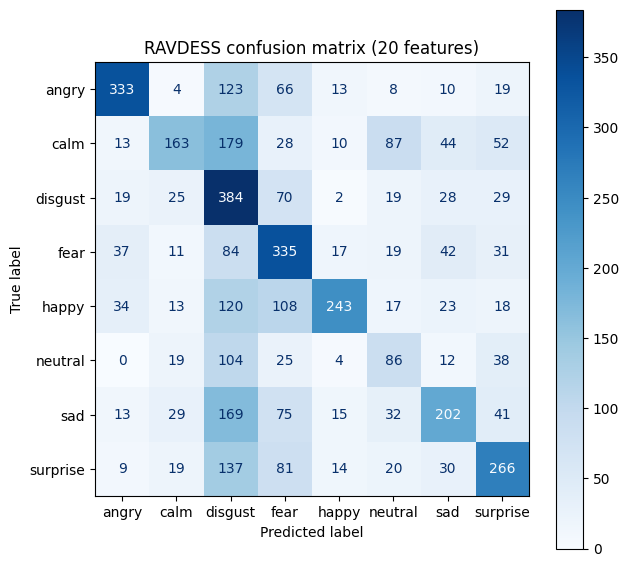

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

y_pred = results_20.loc[mask_valid,"pred"].to_numpy()
cm = confusion_matrix(y_true_id[mask_valid].astype(int), y_pred, labels=list(range(8)))
disp = ConfusionMatrixDisplay(cm, display_labels=[ID_TO_NAME[i] for i in range(8)])

fig, ax = plt.subplots(figsize=(7,7))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)
plt.title("RAVDESS confusion matrix (20 features)")
plt.show()


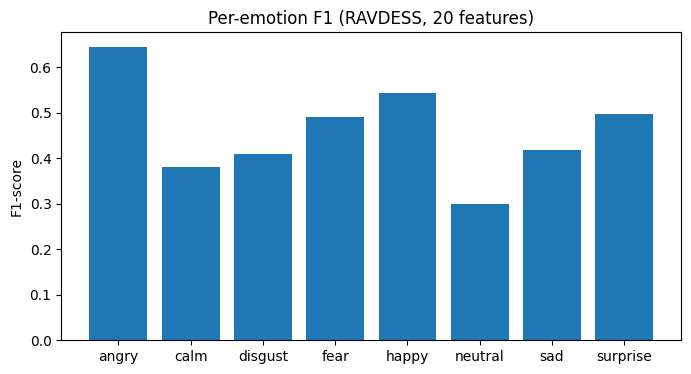

In [70]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, support = precision_recall_fscore_support(
    y_true_id[mask_valid].astype(int), y_pred, labels=list(range(8))
)

plt.figure(figsize=(8,4))
plt.bar(range(8), f1, tick_label=[ID_TO_NAME[i] for i in range(8)])
plt.ylabel("F1-score")
plt.title("Per-emotion F1 (RAVDESS, 20 features)")
plt.show()


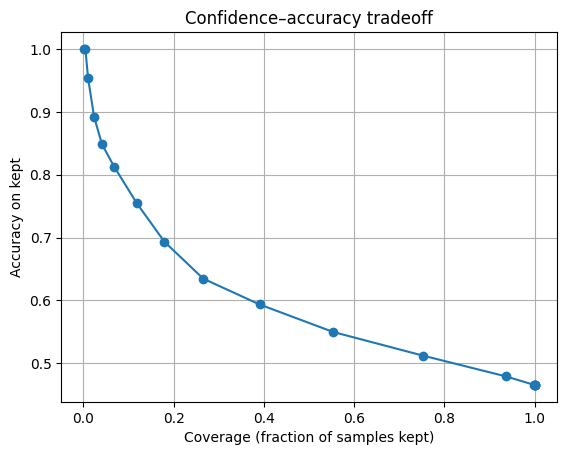

In [71]:
import numpy as np

thresholds = np.linspace(0,1,21)
accs, covs = [], []

for th in thresholds:
    keep = results_20["conf"] >= th
    if keep.any():
        accs.append(accuracy_score(y_true_id[mask_valid & keep],
                                   results_20.loc[mask_valid & keep,"pred"]))
        covs.append(keep.mean())
    else:
        accs.append(np.nan); covs.append(0)

plt.plot(covs, accs, marker="o")
plt.xlabel("Coverage (fraction of samples kept)")
plt.ylabel("Accuracy on kept")
plt.title("Confidence–accuracy tradeoff")
plt.grid(True); plt.show()


In [72]:
errors = results_20[mask_valid].copy()
errors["true"] = y_true_id[mask_valid]
errors = errors[errors["true"] != errors["pred"]]

print(errors.sample(10)[["true","pred","conf","routed"]])


      true  pred      conf  routed
2128     4     3  0.387500    male
2637     3     2  0.340000  female
3051     2     1  0.310000    male
1238     7     2  0.325000  female
462      3     2  0.467369  female
3774     7     2  0.297500  female
2209     6     2  0.402539  female
2043     1     5  0.245000  female
4261     6     7  0.324183    male
1566     3     5  0.370963  female


C:\Users\user\AppData\Local\Temp\ipykernel_9224\2595755743.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /content/drive/My Drive/ser_ravdess_dashboard.png


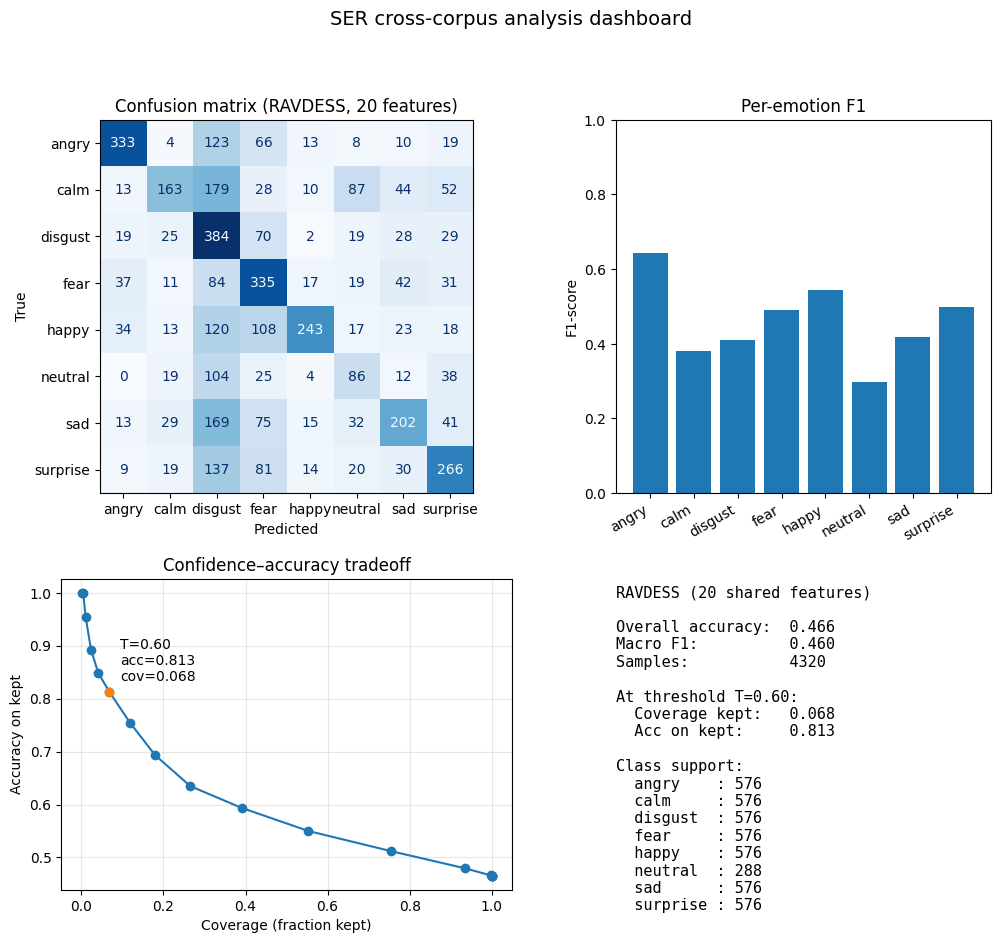

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, accuracy_score
)

# prepare y_true / y_pred 
y_true = y_true_id[mask_valid].astype(int)
y_pred = results_20.loc[mask_valid, "pred"].to_numpy()

# Metrics by class
labels = list(range(8))
target_names = [ID_TO_NAME[i] for i in labels]
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=labels)

# Overall numbers
overall_acc = accuracy_score(y_true, y_pred)
macro_f1 = np.nanmean(f1)

# Confidence vs accuracy curve
ths = np.linspace(0.0, 1.0, 21)
accs, covs = [], []
for t in ths:
    keep = results_20["conf"].to_numpy() >= t
    keep_mask = mask_valid & keep
    if keep_mask.any():
        accs.append(accuracy_score(y_true_id[keep_mask].astype(int),
                                   results_20.loc[keep_mask, "pred"]))
        covs.append(keep.mean())
    else:
        accs.append(np.nan); covs.append(0.0)

# Pick a reporting threshold (used 0.6)
T = 0.60
keep_T = (results_20["conf"].to_numpy() >= T)
cov_T = keep_T.mean()
acc_T = accuracy_score(y_true_id[mask_valid & keep_T].astype(int),
                       results_20.loc[mask_valid & keep_T, "pred"]) if (mask_valid & keep_T).any() else np.nan

# build the 2x2 dashboard
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1.0], width_ratios=[1.2, 1.0], wspace=0.25, hspace=0.25)

# Confusion matrix (all samples)
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
disp.plot(ax=ax1, colorbar=False, cmap="Blues", values_format="d")
ax1.set_title("Confusion matrix (RAVDESS, 20 features)")
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")

# Per-emotion F1 bar
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(np.arange(len(labels)), f1)
ax2.set_xticks(np.arange(len(labels)))
ax2.set_xticklabels(target_names, rotation=30, ha="right")
ax2.set_ylim(0, 1)
ax2.set_ylabel("F1-score")
ax2.set_title("Per-emotion F1")

# Confidence → accuracy curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(covs, accs, marker="o")
ax3.set_xlabel("Coverage (fraction kept)")
ax3.set_ylabel("Accuracy on kept")
ax3.set_title("Confidence–accuracy tradeoff")
ax3.grid(True, alpha=0.3)
# mark your chosen threshold point
if not np.isnan(acc_T):
    ax3.plot(cov_T, acc_T, marker="o")
    ax3.annotate(f"T={T:.2f}\nacc={acc_T:.3f}\ncov={cov_T:.3f}",
                 (cov_T, acc_T), textcoords="offset points", xytext=(8,8))

# Summary panel
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
summary = (
    f"RAVDESS (20 shared features)\n\n"
    f"Overall accuracy:  {overall_acc:.3f}\n"
    f"Macro F1:          {macro_f1:.3f}\n"
    f"Samples:           {len(y_true)}\n\n"
    f"At threshold T={T:.2f}:\n"
    f"  Coverage kept:   {cov_T:.3f}\n"
    f"  Acc on kept:     {acc_T:.3f}\n\n"
    "Class support:\n" +
    "\n".join([f"  {n:<9}: {int(s)}" for n, s in zip(target_names, support)])
)
ax4.text(0.0, 0.98, summary, va="top", ha="left", fontsize=11, family="monospace")

fig.suptitle("SER cross-corpus analysis dashboard", fontsize=14, y=0.99)
plt.tight_layout()

# Optional: save to Drive
out_path = "/content/drive/My Drive/ser_ravdess_dashboard.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved:", out_path)

plt.show()



=== SER Summary Metrics ===
                     Setup  Accuracy  Macro-F1  Coverage
RAVDESS (20 feats, router)  0.465741  0.460177  1.000000
       RAVDESS conf ≥ 0.60  0.812925  0.614921  0.068056
Saved table to: C:/Users/user/OneDrive/Desktop/ML/ser_summary_metrics.csv


C:\Users\user\AppData\Local\Temp\ipykernel_9224\4271656935.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved dashboard: C:/Users/user/OneDrive/Desktop/ML/ser_ravdess_dashboard_all.png


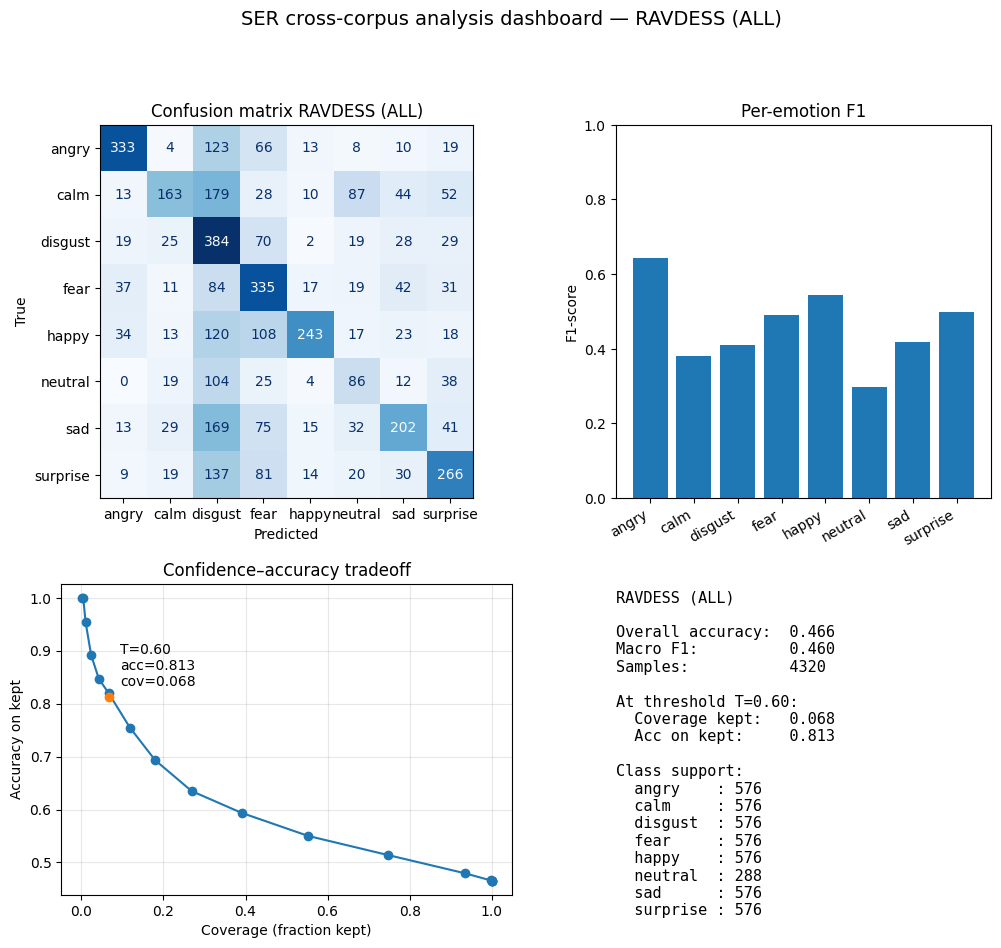

C:\Users\user\AppData\Local\Temp\ipykernel_9224\4271656935.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


OSError: [Errno 22] Invalid argument: 'C:\\Users\\user\\OneDrive\\Desktop\\ML\\ser_ravdess_dashboard_conf>=0.60.png'

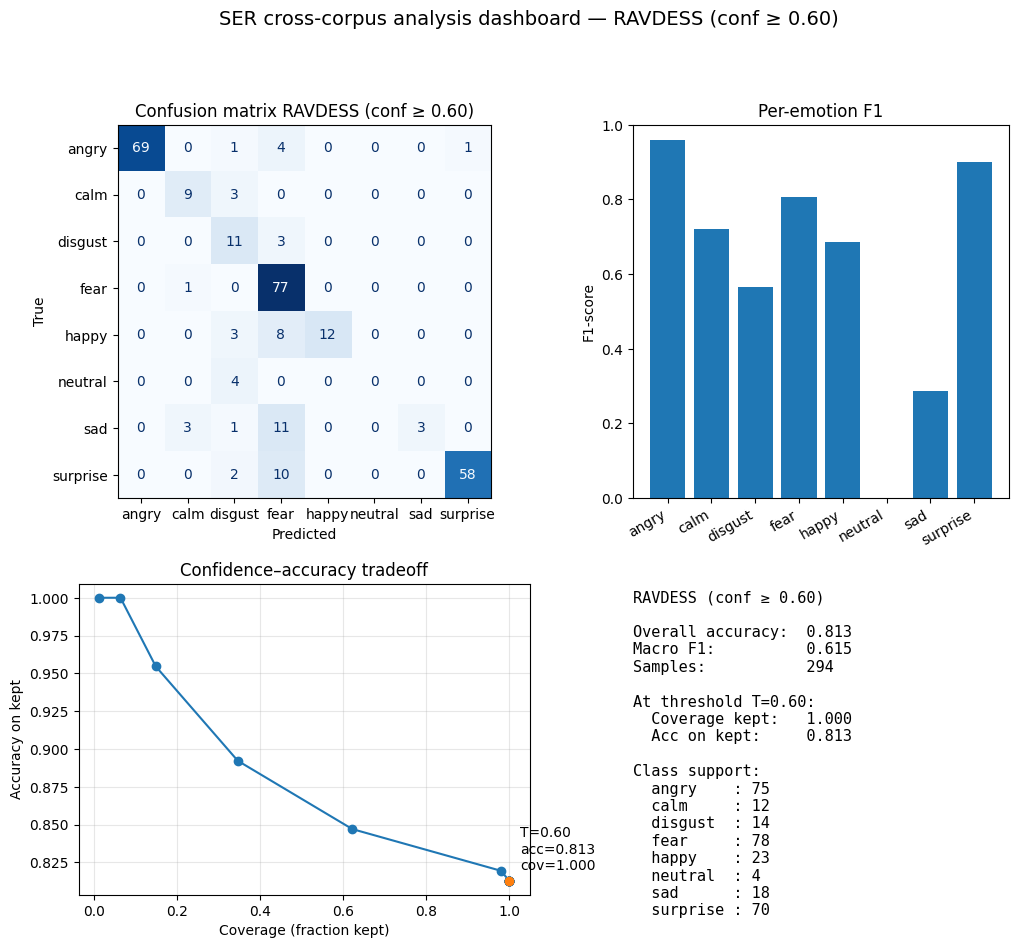

In [77]:
# SER summary + two dashboards (overall + high-confidence) 

import os, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)

# paths & params
BASE_DIR    = "C:/Users/user/OneDrive/Desktop/ML"   
CACHE_DIR   = f"{BASE_DIR}/ser_cache"   # df.pkl here
MODEL20_DIR = f"{BASE_DIR}/ser_models_20"   # rf_male_20.pkl, rf_female_20.pkl, feature_names_20.pkl
RAV_CSV     = f"{BASE_DIR}/features.csv"    # RAVDESS MFCC CSV with a 'labels' column
THRESH      = 0.60                          # confidence threshold

NAME_TO_ID = {
    "angry":0, "calm":1, "disgust":2, "fear":3,
    "happy":4, "neutral":5, "sad":6, "surprise":7
}
ID_TO_NAME = {v:k for k,v in NAME_TO_ID.items()}
LABELS = list(range(8))

def row_z(X: np.ndarray) -> np.ndarray:
    X = X.astype(np.float32, copy=False)
    m = X.mean(axis=1, keepdims=True); s = X.std(axis=1, keepdims=True) + 1e-8
    return (X - m) / s

def encode_labels(series: pd.Series) -> np.ndarray:
    s = series.copy()
    if s.dtype.kind in "iu":  # already ints
        return s.astype(int).to_numpy()
    s = (s.astype(str).str.replace(r"^(male|female)_", "", regex=True)
                   .str.lower().str.strip())
    mapped = s.map(NAME_TO_ID)
    if mapped.isna().any():
        unknown = sorted(s[mapped.isna()].unique().tolist())
        raise ValueError(f"Found unknown label values not in {list(NAME_TO_ID.keys())}: {unknown}")
    return mapped.astype(int).to_numpy()

def macro_f1(y_true, y_pred, labels):
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    return float(np.nanmean(f1))

# Load data & models (20-feature router required)
df_path = f"{CACHE_DIR}/df.pkl"
assert os.path.exists(df_path), f"Missing {df_path}. Please cache df.pkl first."
df = joblib.load(df_path)

for fn in ["rf_male_20.pkl","rf_female_20.pkl","feature_names_20.pkl"]:
    full = f"{MODEL20_DIR}/{fn}"
    assert os.path.exists(full), f"Missing {full}."

rf_male_20   = joblib.load(f"{MODEL20_DIR}/rf_male_20.pkl")
rf_female_20 = joblib.load(f"{MODEL20_DIR}/rf_female_20.pkl")
FEATS_20     = joblib.load(f"{MODEL20_DIR}/feature_names_20.pkl")

assert os.path.exists(RAV_CSV), f"Missing {RAV_CSV}."
rav = pd.read_csv(RAV_CSV)

# sanity: required columns
missing_feats = [c for c in FEATS_20 if c not in rav.columns]
assert 'labels' in rav.columns, "RAV_CSV must contain a 'labels' column."
assert len(missing_feats) == 0, f"RAV_CSV missing {len(missing_feats)} required feature(s), e.g. {missing_feats[:10]}"

# Predict on RAVDESS with dual routing (20 shared features)
X20 = row_z(rav.reindex(columns=FEATS_20, fill_value=0.0).to_numpy(np.float32))

pm = rf_male_20.predict_proba(X20); im = pm.argmax(1); cm = pm[np.arange(len(im)), im]
pf = rf_female_20.predict_proba(X20); iF = pf.argmax(1); cF = pf[np.arange(len(iF)), iF]

pick_f = cF > cm
pred   = np.where(pick_f, rf_female_20.classes_[iF], rf_male_20.classes_[im]).astype(int)
conf   = np.where(pick_f, cF, cm)

y_true = encode_labels(rav["labels"])

# Summary metrics table
acc_all  = accuracy_score(y_true, pred)
mf1_all  = macro_f1(y_true, pred, LABELS)

keep     = conf >= THRESH
coverage = float(keep.mean())
acc_T    = accuracy_score(y_true[keep], pred[keep]) if keep.any() else np.nan
mf1_T    = macro_f1(y_true[keep], pred[keep], LABELS) if keep.any() else np.nan

summary = pd.DataFrame([
    ["RAVDESS (20 feats, router)", acc_all, mf1_all, 1.0],
    [f"RAVDESS conf ≥ {THRESH:.2f}", acc_T, mf1_T, coverage],
], columns=["Setup", "Accuracy", "Macro-F1", "Coverage"])

out_csv = f"{BASE_DIR}/ser_summary_metrics.csv"
summary.to_csv(out_csv, index=False)

print("\n=== SER Summary Metrics ===")
print(summary.to_string(index=False))
print("Saved table to:", out_csv)

# Dashboard builder
def build_dashboard(y_true_int, y_pred_int, conf_vec, title_suffix, save_path, T=THRESH):
    _, _, f1, support = precision_recall_fscore_support(y_true_int, y_pred_int, labels=LABELS, zero_division=0)
    overall_acc = accuracy_score(y_true_int, y_pred_int)
    macroF1     = float(np.nanmean(f1))

    ths = np.linspace(0.0, 1.0, 21)
    accs, covs = [], []
    for t in ths:
        m = conf_vec >= t
        if m.any():
            accs.append(accuracy_score(y_true_int[m], y_pred_int[m]))
            covs.append(m.mean())
        else:
            accs.append(np.nan); covs.append(0.0)

    keepT = conf_vec >= T
    cov_T = keepT.mean()
    acc_T = accuracy_score(y_true_int[keepT], y_pred_int[keepT]) if keepT.any() else np.nan

    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1.0], width_ratios=[1.2, 1.0], wspace=0.25, hspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])
    cm  = confusion_matrix(y_true_int, y_pred_int, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=[ID_TO_NAME[i] for i in LABELS])
    disp.plot(ax=ax1, colorbar=False, cmap="Blues", values_format="d")
    ax1.set_title(f"Confusion matrix {title_suffix}")
    ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(np.arange(len(LABELS)), f1)
    ax2.set_xticks(np.arange(len(LABELS)))
    ax2.set_xticklabels([ID_TO_NAME[i] for i in LABELS], rotation=30, ha="right")
    ax2.set_ylim(0, 1); ax2.set_ylabel("F1-score")
    ax2.set_title("Per-emotion F1")

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(covs, accs, marker="o")
    ax3.set_xlabel("Coverage (fraction kept)")
    ax3.set_ylabel("Accuracy on kept")
    ax3.set_title("Confidence–accuracy tradeoff")
    ax3.grid(True, alpha=0.3)
    if not np.isnan(acc_T):
        ax3.plot(cov_T, acc_T, marker="o")
        ax3.annotate(f"T={T:.2f}\nacc={acc_T:.3f}\ncov={cov_T:.3f}",
                     (cov_T, acc_T), textcoords="offset points", xytext=(8,8))

    ax4 = fig.add_subplot(gs[1, 1]); ax4.axis("off")
    summary_txt = (
        f"{title_suffix}\n\n"
        f"Overall accuracy:  {overall_acc:.3f}\n"
        f"Macro F1:          {macroF1:.3f}\n"
        f"Samples:           {len(y_true_int)}\n\n"
        f"At threshold T={T:.2f}:\n"
        f"  Coverage kept:   {cov_T:.3f}\n"
        f"  Acc on kept:     {acc_T:.3f}\n\n"
        "Class support:\n" +
        "\n".join([f"  {ID_TO_NAME[i]:<9}: {int(support[i])}" for i in LABELS])
    )
    ax4.text(0.0, 0.98, summary_txt, va="top", ha="left", fontsize=11, family="monospace")

    fig.suptitle(f"SER cross-corpus analysis dashboard — {title_suffix}", fontsize=14, y=0.995)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved dashboard:", save_path)
    plt.show()

# 6) Make BOTH dashboards
dash_all = f"{BASE_DIR}/ser_ravdess_dashboard_all.png"
build_dashboard(y_true, pred, conf, "RAVDESS (ALL)", dash_all, T=THRESH)

dash_hi  = f"{BASE_DIR}/ser_ravdess_dashboard_conf>=%.2f.png" % THRESH
mask_hi  = conf >= THRESH
if mask_hi.any():
    build_dashboard(y_true[mask_hi], pred[mask_hi], conf[mask_hi],
                    f"RAVDESS (conf ≥ {THRESH:.2f})", dash_hi, T=THRESH)
else:
    print(f"No samples above threshold {THRESH:.2f}; skip high-confidence dashboard.")


In [78]:
X_male = male.iloc[:, :-1].values   # features
y_male = male.iloc[:, -1].values    # labels

X_female = female.iloc[:, :-1].values
y_female = female.iloc[:, -1].values

In [81]:
!pip install torch torchvision torchaudio



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# --- Build tensors from rav + FEATS_20 (assumes both are already loaded) ---
# Fallback: if not loaded, raise a clear error.
try:
    _ = rav, FEATS_20
except NameError as e:
    raise RuntimeError("This cell expects 'rav' (DataFrame) and 'FEATS_20' (list of 58 features) "
                       "to be defined. Load them first (see the previous Jupyter cell).") from e

# X: (N, 58) float32  |  y: (N,) int64
X = rav.reindex(columns=FEATS_20, fill_value=0.0).to_numpy(np.float32)
# simple per-row z-score to match earlier preprocessing
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

# Label encoding (same mapping as before). If you already have integer labels, this will work too.
NAME_TO_ID = {"angry":0,"calm":1,"disgust":2,"fear":3,"happy":4,"neutral":5,"sad":6,"surprise":7}
y_series = rav["labels"]
if y_series.dtype.kind in "iu":
    y = y_series.astype(int).to_numpy()
else:
    y = (y_series.astype(str).str.replace(r"^(male|female)_", "", regex=True)
                    .str.lower().str.strip().map(NAME_TO_ID).astype(int).to_numpy())

# Tensors for PyTorch
X_tensor = torch.from_numpy(X).unsqueeze(1)              # (N, 1, 58)
y_tensor = torch.from_numpy(y.astype(np.int64))          # (N,)

# Split + loaders 
X_tr, X_va, y_tr, y_va = train_test_split(
    X_tensor, y_tensor, test_size=0.2, stratify=y_tensor, random_state=42
)
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=128, shuffle=False)

# Model 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len=58, n_classes=8):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool1d(kernel_size=2)  # 58 -> 29
        self.drop  = nn.Dropout(0.3)
        self.flat  = 64 * (feat_len // 2)         # 64×29 = 1856 when feat_len=58
        self.fc1   = nn.Linear(self.flat, 128)
        self.fc2   = nn.Linear(128, n_classes)

    def forward(self, x):               # x: (B,1,58)
        x = torch.relu(self.conv1(x))   # (B,32,58)
        x = self.pool(torch.relu(self.conv2(x)))  # (B,64,29)
        x = self.drop(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
n_classes = int(y_tensor.max().item() + 1)  # infer from labels
model = SmallCNN1D(feat_len=X_tensor.shape[2], n_classes=n_classes).to(device)

crit = nn.CrossEntropyLoss()
opt  = optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    tot=cor=loss_sum=0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train: opt.zero_grad()
            out = model(xb)
            loss = crit(out, yb)
            if train:
                loss.backward(); opt.step()
            loss_sum += loss.item()*yb.size(0)
            cor     += (out.argmax(1)==yb).sum().item()
            tot     += yb.size(0)
    return loss_sum/tot, cor/tot

for ep in range(1, 11):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    print(f"Epoch {ep:02d} | train {tr_acc:.3f} | val {va_acc:.3f} | vloss {va_loss:.4f}")


Epoch 01 | train 0.146 | val 0.141 | vloss 2.0300
Epoch 02 | train 0.206 | val 0.258 | vloss 1.9158
Epoch 03 | train 0.259 | val 0.272 | vloss 1.8584
Epoch 04 | train 0.297 | val 0.329 | vloss 1.8009
Epoch 05 | train 0.312 | val 0.339 | vloss 1.7530
Epoch 06 | train 0.338 | val 0.348 | vloss 1.7188
Epoch 07 | train 0.356 | val 0.359 | vloss 1.6889
Epoch 08 | train 0.371 | val 0.363 | vloss 1.6712
Epoch 09 | train 0.378 | val 0.385 | vloss 1.6529
Epoch 10 | train 0.381 | val 0.398 | vloss 1.6227


In [84]:
def load_emodb_for_1d(path, le, label_col=None, feat_len=58):
    df = pd.read_csv(path)

    if label_col is None:
        label_col = "label" if "label" in df.columns else df.columns[-1]
    feat_cols = [c for c in df.columns if c != label_col]

    # --- normalize labels ---
    df[label_col] = df[label_col].astype(str)
    # remove gender prefix if present
    df[label_col] = df[label_col].str.replace(r'^(male_|female_)', '', regex=True)

    # features to numeric
    X = df[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0

    # adjust length to 58
    if X.shape[1] != feat_len:
        if X.shape[1] > feat_len:
            X = X[:, :feat_len]
        else:
            pad = np.zeros((X.shape[0], feat_len - X.shape[1]), dtype=np.float32)
            X = np.concatenate([X, pad], axis=1)

    # align labels
    raw = df[label_col].values
    keep = np.isin(raw, le.classes_)
    kept = keep.mean()
    if kept < 1.0:
        print(f"[warn] Dropping {(1-kept)*100:.1f}% rows with unseen labels:",
              sorted(set(raw[~keep])))
    X = X[keep]
    y = le.transform(raw[keep]).astype(np.int64)

    X1d = torch.from_numpy(X).view(-1, 1, feat_len)
    y_t = torch.from_numpy(y)
    return X1d, y_t, kept


In [88]:
# Cross-domain eval on features.csv with your trained 1D-CNN (58-dim) 
import os, numpy as np, pandas as pd, torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Paths
BASE_DIR = "C:/Users/user/OneDrive/Desktop/ML"                  
FEAT_CSV = os.path.join(BASE_DIR, "features.csv")   # CSV used with XGBoost (58 features + label)
assert os.path.exists(FEAT_CSV), f"Not found: {FEAT_CSV}"


# Fallback label map if 'le' isn't available
NAME_TO_ID = {"angry":0, "calm":1, "disgust":2, "fear":3, "happy":4, "neutral":5, "sad":6, "surprise":7}
ID_TO_NAME = {v:k for k,v in NAME_TO_ID.items()}

# Helper: evaluate with optional confidence threshold
@torch.no_grad()
def eval_with_thresholds(model, X1d, y, thresholds=(None,), device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval(); model.to(device)
    dl = DataLoader(TensorDataset(X1d, y), batch_size=256, shuffle=False)
    y_true, y_pred, pmax = [], [], []
    for xb, yb in dl:
        xb = xb.to(device)
        probs = torch.softmax(model(xb), dim=1)
        pm, yh = probs.max(1)
        y_true.append(yb.numpy()); y_pred.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred); pmax = np.concatenate(pmax)

    out = []
    for t in thresholds:
        if t is None:
            mask = np.ones_like(pmax, dtype=bool); tag = "full"
        else:
            mask = pmax >= float(t); tag = f"tau={t:.2f}"
        if mask.any():
            acc = accuracy_score(y_true[mask], y_pred[mask])
            f1  = f1_score(y_true[mask], y_pred[mask], average="macro")
            cov = float(mask.mean())
        else:
            acc=f1=cov=0.0
        out.append((tag, acc, f1, cov))
    return out, (y_true, y_pred)

# Load + clean + align labels
def load_features_csv_1d(path, feat_len=58, dataset_filter=None, label_col=None):
    df = pd.read_csv(path)

    if dataset_filter and 'dataset' in df.columns:
        df = df[df['dataset'].astype(str).str.lower() == dataset_filter.lower()].copy()

    if label_col is None:
        label_col = 'label' if 'label' in df.columns else df.columns[-1]

    print("Raw label freq:")
    print(df[label_col].value_counts().head(20))

    # normalize labels
    df[label_col] = (df[label_col].astype(str)
                     .str.strip().str.lower()
                     .str.replace(r'^(male_|female_)', '', regex=True))

    # optional mapping hook
    label_map = {
        # "boredom": "neutral",
        # "happiness": "happy",
    }
    df[label_col] = df[label_col].map(lambda x: label_map.get(x, x))

    print("\nCleaned label freq:")
    print(df[label_col].value_counts().head(20))

    feat_cols = [c for c in df.columns if c != label_col]
    X = df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0

    # force 58-dim
    if X.shape[1] != feat_len:
        print(f"[info] Adjusting feature length {X.shape[1]} -> {feat_len}")
        if X.shape[1] > feat_len:
            X = X[:, :feat_len]
        else:
            pad = np.zeros((X.shape[0], feat_len - X.shape[1]), dtype=np.float32)
            X = np.concatenate([X, pad], axis=1)

    # choose label encoding strategy
    if 'le' in globals():
        raw = df[label_col].values
        keep = np.isin(raw, le.classes_)
        kept_ratio = float(keep.mean())
        if kept_ratio < 1.0:
            dropped = sorted(set(raw[~keep]))
            print(f"\n[warn] Dropping {(1-kept_ratio)*100:.1f}% rows with unseen labels: "
                  f"{dropped[:10]}{' ...' if len(dropped)>10 else ''}")
        X = X[keep]
        y = le.transform(raw[keep]).astype(np.int64)
        target_names = list(le.classes_)
    else:
        # fallback to fixed map
        raw_norm = df[label_col].values
        keep = np.isin(raw_norm, list(NAME_TO_ID.keys()))
        kept_ratio = float(keep.mean())
        if kept_ratio < 1.0:
            dropped = sorted(set(raw_norm[~keep]))
            print(f"\n[warn] Dropping {(1-kept_ratio)*100:.1f}% rows with unseen labels: "
                  f"{dropped[:10]}{' ...' if len(dropped)>10 else ''}")
        X = X[keep]
        y = np.array([NAME_TO_ID[v] for v in raw_norm[keep]], dtype=np.int64)
        target_names = [ID_TO_NAME[i] for i in sorted(set(y))]

    # z-score per row (matches earlier preprocessing)
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

    X1d = torch.from_numpy(X).view(-1, 1, feat_len)
    y_t = torch.from_numpy(y)
    print(f"\nFinal kept: {X1d.shape[0]} samples ({kept_ratio*100:.1f}% of rows)")
    return X1d, y_t, kept_ratio, target_names

# Run it
X_new, y_new, kept, target_names = load_features_csv_1d(FEAT_CSV, feat_len=58, dataset_filter=None)

results, (y_true, y_pred_tmp) = eval_with_thresholds(model, X_new, y_new,
                                                     thresholds=(None, 0.60, 0.70))
for tag, acc, f1, cov in results:
    print(f"features.csv [{tag}]  Acc={acc:.3f} | Macro-F1={f1:.3f} | Coverage={cov:.2f}")

# Optional: per-class report on full set
device = "cuda" if torch.cuda.is_available() else "cpu"
with torch.no_grad():
    probs = torch.softmax(model(X_new.to(device)), dim=1).cpu()
y_pred = probs.argmax(1).numpy()
print("\nPer-class report:")
print(classification_report(y_new.numpy(), y_pred, target_names=target_names))


Raw label freq:
labels
male_calm          288
male_angry         288
male_fear          288
male_sad           288
male_surprise      288
male_happy         288
male_disgust       288
female_calm        288
female_disgust     288
female_angry       288
female_happy       288
female_sad         288
female_fear        288
female_surprise    288
male_neutral       144
female_neutral     144
Name: count, dtype: int64

Cleaned label freq:
labels
calm        576
angry       576
fear        576
sad         576
surprise    576
happy       576
disgust     576
neutral     288
Name: count, dtype: int64
[info] Adjusting feature length 20 -> 58

Final kept: 4320 samples (100.0% of rows)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (256x1856 and 640x128)

In [89]:
def load_features_csv_1d(path, feat_len, dataset_filter=None, label_col=None, use_cols=None):
    df = pd.read_csv(path)

    if dataset_filter and 'dataset' in df.columns:
        df = df[df['dataset'].astype(str).str.lower()==dataset_filter.lower()].copy()

    if label_col is None:
        label_col = 'label' if 'label' in df.columns else df.columns[-1]

    # normalize labels (same as before) ...
    df[label_col] = (df[label_col].astype(str)
                     .str.strip().str.lower()
                     .str.replace(r'^(male_|female_)', '', regex=True))

    # choose feature columns
    if use_cols is not None:
        missing = [c for c in use_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Missing required feature columns from training: {missing[:10]}")
        feat_cols = list(use_cols)  # preserve training order
        X = df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0).to_numpy(np.float32)
    else:
        # fallback: take the first feat_len non-label columns
        feat_cols = [c for c in df.columns if c != label_col][:feat_len]
        X = df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0).to_numpy(np.float32)

    X[~np.isfinite(X)] = 0.0

    # ensure exact length (crop or pad as last resort)
    if X.shape[1] != feat_len:
        print(f"[info] Adjusting feature length {X.shape[1]} -> {feat_len}")
        if X.shape[1] > feat_len:
            X = X[:, :feat_len]
        else:
            pad = np.zeros((X.shape[0], feat_len - X.shape[1]), dtype=np.float32)
            X = np.concatenate([X, pad], axis=1)

    # encode labels (either with 'le' or fixed map)
    NAME_TO_ID = {"angry":0,"calm":1,"disgust":2,"fear":3,"happy":4,"neutral":5,"sad":6,"surprise":7}
    if 'le' in globals():
        raw = df[label_col].values
        keep = np.isin(raw, le.classes_)
        X = X[keep]; y = le.transform(raw[keep]).astype(np.int64)
        target_names = list(le.classes_)
    else:
        raw = df[label_col].values
        keep = np.isin(raw, list(NAME_TO_ID.keys()))
        X = X[keep]; y = np.array([NAME_TO_ID[v] for v in raw[keep]], dtype=np.int64)
        target_names = [k for k,_ in sorted(NAME_TO_ID.items(), key=lambda kv: kv[1])]

    # row-wise z-score (matches earlier)
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

    X1d = torch.from_numpy(X).view(-1, 1, feat_len)
    y_t = torch.from_numpy(y)
    print(f"\nFinal kept: {X1d.shape[0]} samples")
    return X1d, y_t, target_names


In [90]:
req_len = (model.fc1.in_features // 64) * 2
X_new, y_new, target_names = load_features_csv_1d(
    FEAT_CSV, feat_len=req_len, dataset_filter=None, use_cols=FEATS_20 if 'FEATS_20' in globals() else None
)
results, _ = eval_with_thresholds(model, X_new, y_new, thresholds=(None, 0.60, 0.70))



Final kept: 4320 samples


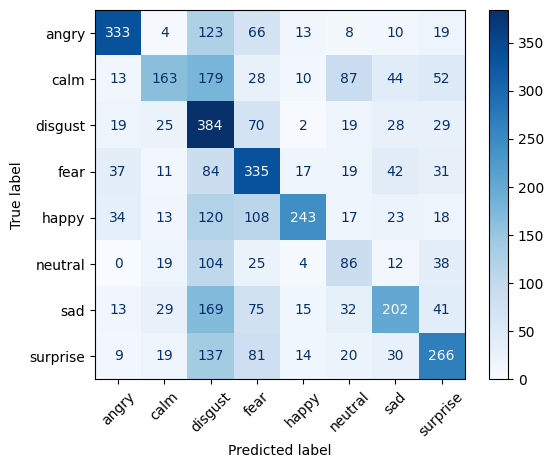

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.show()


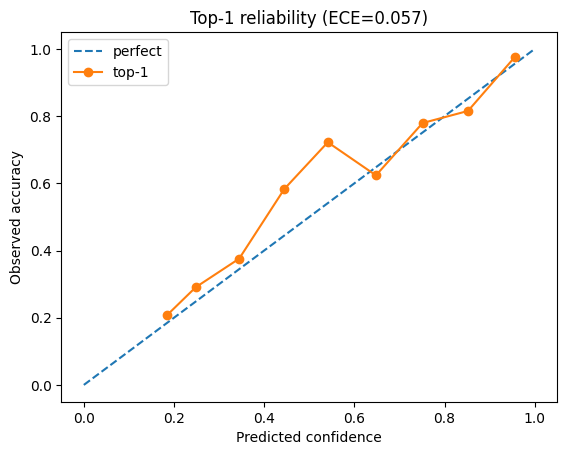

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Get probs for eval set 
with torch.no_grad():
    logits = model(X_new.to(next(model.parameters()).device))
    probs  = torch.softmax(logits, dim=1).cpu().numpy()

y_true_np = y_new.numpy()
p_max  = probs.max(axis=1)
y_pred = probs.argmax(axis=1)
correct = (y_pred == y_true_np).astype(np.float32)

def reliability_curve(p, correct, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    idx  = np.digitize(p, bins) - 1
    accs, confs, counts = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.any():
            accs.append(correct[m].mean())
            confs.append(p[m].mean())
            counts.append(m.sum())
        else:
            accs.append(np.nan); confs.append((bins[b]+bins[b+1])/2); counts.append(0)
    return np.array(confs), np.array(accs), np.array(counts), bins

confs, accs, counts, bins = reliability_curve(p_max, correct, n_bins=10)

# Expected Calibration Error (ECE)
ece = np.nansum((counts/np.nansum(counts)) * np.abs(accs - confs))

plt.figure()
plt.plot([0,1],[0,1],'--', label='perfect')
plt.plot(confs, accs, marker='o', label='top-1')
plt.xlabel('Predicted confidence'); plt.ylabel('Observed accuracy')
plt.title(f'Top-1 reliability (ECE={ece:.3f})'); plt.legend(); plt.show()


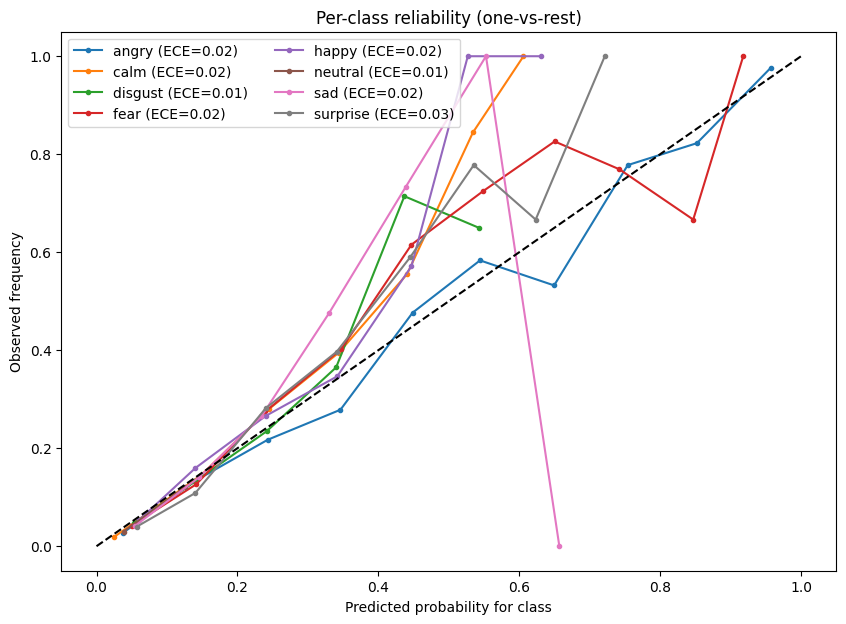

In [93]:
from sklearn.preprocessing import label_binarize

K = probs.shape[1]
Y_ovr = label_binarize(y_true_np, classes=np.arange(K))  # shape (N,K)

plt.figure(figsize=(10,7))
ece_per_class = []
for k in range(K):
    p_k = probs[:,k]                           # model prob for class k
    y_k = Y_ovr[:,k].astype(np.float32)        # 1 if true class is k else 0
    confs, accs, counts, _ = reliability_curve(p_k, y_k, n_bins=10)
    ece_k = np.nansum((counts/np.nansum(counts)) * np.abs(accs - confs))
    ece_per_class.append(ece_k)
    plt.plot(confs, accs, marker='.', label=f'{le.classes_[k]} (ECE={ece_k:.2f})')

plt.plot([0,1],[0,1],'--', c='k')
plt.xlabel('Predicted probability for class'); plt.ylabel('Observed frequency')
plt.title('Per-class reliability (one-vs-rest)')
plt.legend(ncol=2); plt.show()

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  loss = float(closure())


Fitted temperature: 0.784
NLL before: 1.5888162851333618
NLL after : 1.5770405530929565


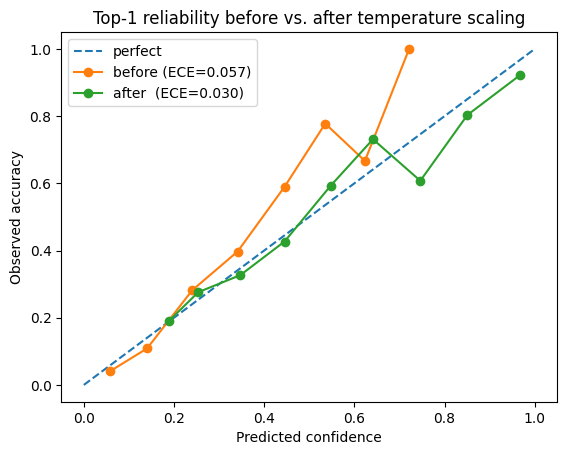

In [94]:
import torch
import torch.nn as nn
import numpy as np

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.T = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.T

@torch.no_grad()
def eval_nll(logits, y):
    logp = torch.log_softmax(logits, dim=1)
    return -logp[torch.arange(y.size(0)), y].mean().item()

# Split X_new / y_new into cal (e.g., first 20%) and test (rest)
n = X_new.size(0)
cut = int(0.2*n)
X_cal, y_cal = X_new[:cut], y_new[:cut]
X_tst, y_tst = X_new[cut:], y_new[cut:]

device = next(model.parameters()).device
model.eval()
with torch.no_grad():
    logits_cal = model(X_cal.to(device))
    logits_tst = model(X_tst.to(device))

# Fit temperature on calibration split
ts = TemperatureScaler().to(device)
opt = torch.optim.LBFGS(ts.parameters(), lr=0.1, max_iter=50)

y_cal_dev = y_cal.to(device)
def closure():
    opt.zero_grad()
    loss = nn.CrossEntropyLoss()(ts(logits_cal), y_cal_dev)
    loss.backward()
    return loss
opt.step(closure)
T_value = ts.T.item()

print(f"Fitted temperature: {T_value:.3f}")
print("NLL before:", eval_nll(logits_tst, y_tst.to(device)))
print("NLL after :", eval_nll(ts(logits_tst), y_tst.to(device)))

# Recompute probs with temperature for reliability plots
with torch.no_grad():
    probs_t = torch.softmax(ts(logits_tst), dim=1).cpu().numpy()
    y_true_t = y_tst.numpy()
pmax_t  = probs_t.max(axis=1)
y_pred_t = probs_t.argmax(axis=1)
correct_t = (y_pred_t == y_true_t).astype(np.float32)
confs_t, accs_t, counts_t, _ = reliability_curve(pmax_t, correct_t, n_bins=10)
ece_t = np.nansum((counts_t/np.nansum(counts_t)) * np.abs(accs_t - confs_t))

plt.figure()
plt.plot([0,1],[0,1],'--', label='perfect')
plt.plot(confs, accs, marker='o', label=f'before (ECE={ece:.3f})')
plt.plot(confs_t, accs_t, marker='o', label=f'after  (ECE={ece_t:.3f})')
plt.xlabel('Predicted confidence'); plt.ylabel('Observed accuracy')
plt.title('Top-1 reliability before vs. after temperature scaling')
plt.legend(); plt.show()


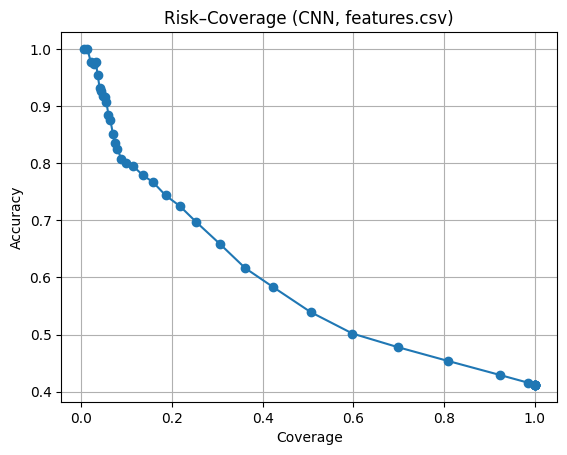

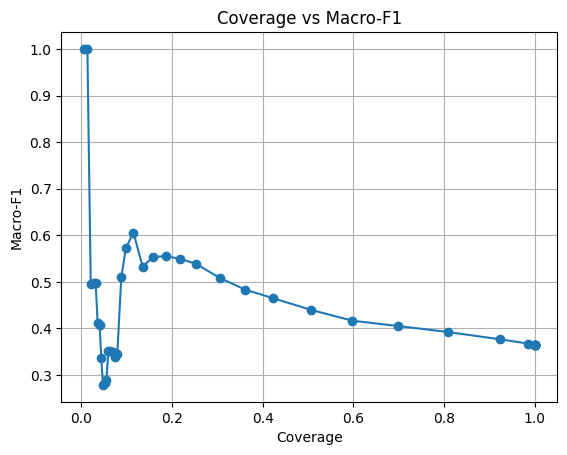

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Requires: probs (N,K) and y_true (N,) for the eval domain.
with torch.no_grad():
    logits = model(X_new.to(next(model.parameters()).device))
    probs  = torch.softmax(logits, dim=1).cpu().numpy()
y_true = y_new.numpy()

pmax  = probs.max(axis=1)
ypred = probs.argmax(axis=1)

taus = np.linspace(0.0, 0.99, 40)
accs, f1s, covs = [], [], []
for t in taus:
    keep = pmax >= t
    covs.append(keep.mean())
    if keep.any():
        accs.append(accuracy_score(y_true[keep], ypred[keep]))
        f1s.append(f1_score(y_true[keep], ypred[keep], average='macro'))
    else:
        accs.append(np.nan); f1s.append(np.nan)

plt.figure()
plt.plot(covs, accs, marker='o')
plt.xlabel("Coverage"); plt.ylabel("Accuracy"); plt.title("Risk–Coverage (CNN, features.csv)")
plt.grid(True); plt.show()

plt.figure()
plt.plot(covs, f1s, marker='o')
plt.xlabel("Coverage"); plt.ylabel("Macro-F1"); plt.title("Coverage vs Macro-F1")
plt.grid(True); plt.show()


In [101]:
# Auto-detect 58-feature CSV(s), train + eval 1D-CNN 
import os, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

BASE_DIR = r"C:/Users/user/OneDrive/Desktop/ML"  

os.makedirs(os.path.join(BASE_DIR, "ser_models"), exist_ok=True)
WEIGHTS_OUT = os.path.join(BASE_DIR, "ser_models", "cnn1d_58.pth")

#  model + utils 

NAME_TO_ID = {"angry":0, "calm":1, "disgust":2, "fear":3, "happy":4, "neutral":5, "sad":6, "surprise":7}
ID_TO_NAME = {v:k for k,v in NAME_TO_ID.items()}

class SmallCNN1D(nn.Module):
    def __init__(self, feat_len=58, n_classes=8, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool1d(kernel_size=2)      # 58 -> 29
        self.drop  = nn.Dropout(pdrop)
        self.flat  = 64 * (feat_len // 2)             # 64*29 = 1856
        self.fc1   = nn.Linear(self.flat, 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

def _to_torch(x, dtype=None, device=None):
    if isinstance(x, np.ndarray): t = torch.from_numpy(x)
    elif torch.is_tensor(x):      t = x
    elif isinstance(x, (pd.DataFrame, pd.Series)): t = torch.from_numpy(x.to_numpy())
    else: raise TypeError(f"Unsupported type: {type(x)}")
    if dtype is not None: t = t.to(dtype)
    if device is not None: t = t.to(device)
    return t

def to_1dN(x, feat_len):
    x = _to_torch(x, dtype=torch.float32)
    if x.ndim == 4 and x.shape[-1] == 1: x = x.squeeze(-1)
    if x.ndim == 2 and x.shape[1] == feat_len: x = x.unsqueeze(1)
    assert x.ndim == 3 and x.shape[1] == 1 and x.shape[2] == feat_len, f"Got {tuple(x.shape)}, need (N,1,{feat_len})"
    return x

@torch.no_grad()
def eval_with_thresholds(model, X1d, y, thresholds=(None,), device=None, batch=256):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval(); model.to(device)
    dl = DataLoader(TensorDataset(X1d, y), batch_size=batch, shuffle=False)
    y_true, y_pred, pmax = [], [], []
    for xb, yb in dl:
        xb = xb.to(device)
        probs = torch.softmax(model(xb), dim=1)
        pm, yh = probs.max(1)
        y_true.append(yb.numpy()); y_pred.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred); pmax = np.concatenate(pmax)

    out = []
    for t in thresholds:
        mask = np.ones_like(pmax, dtype=bool) if t is None else (pmax >= float(t))
        tag  = "full" if t is None else f"tau={t:.2f}"
        if mask.any():
            acc = accuracy_score(y_true[mask], y_pred[mask])
            f1  = f1_score(y_true[mask], y_pred[mask], average="macro")
            cov = float(mask.mean())
        else:
            acc=f1=cov=0.0
        out.append((tag, acc, f1, cov))
    return out, (y_true, y_pred)

# scan CSVs and build a 58-feature dataset 
def load_58_from_folder(folder):
    candidates = []
    for fn in ["features.csv", "Male_features.csv", "Female_features.csv"]:
        path = os.path.join(folder, fn)
        if os.path.exists(path):
            candidates.append(path)
    if not candidates:
        raise FileNotFoundError("No candidate CSVs found (features.csv / Male_features.csv / Female_features.csv).")

    frames = []
    for path in candidates:
        df = pd.read_csv(path)
        # pick label column (prefer 'labels' if present, else last col)
        label_col = "labels" if "labels" in df.columns else df.columns[-1]
        feat_cols = [c for c in df.columns if c != label_col]
        # numeric cast
        X = df[feat_cols].apply(pd.to_numeric, errors='coerce')
        # Keep exactly 58 numeric columns (drop non-numeric silently)
        numeric_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        X = X[numeric_cols]
        if X.shape[1] == 58:
            # normalize labels
            y = (df[label_col].astype(str)
                              .str.strip().str.lower()
                              .str.replace(r'^(male_|female_)', '', regex=True))
            tmp = pd.concat([X, y.rename("label")], axis=1)
            tmp["_srcfile"] = os.path.basename(path)
            frames.append(tmp)
            print(f"Using {os.path.basename(path)} with 58 features, rows={len(tmp)}")
        else:
            print(f"Skip {os.path.basename(path)} (found {X.shape[1]} numeric features; need 58).")

    if not frames:
        raise ValueError("No CSV in the folder has exactly 58 numeric feature columns. "
                         "Regenerate 58-dim features or point me to the right file.")
    df_all = pd.concat(frames, ignore_index=True)

    # drop unseen labels
    keep = df_all["label"].isin(NAME_TO_ID.keys())
    if keep.mean() < 1.0:
        dropped = sorted(set(df_all.loc[~keep, "label"]))
        print(f"[warn] Dropping {(1-keep.mean())*100:.1f}% rows with unseen labels: {dropped[:10]}{' ...' if len(dropped)>10 else ''}")
    df_all = df_all.loc[keep].reset_index(drop=True)

    # final arrays
    X = df_all.drop(columns=["label", "_srcfile"]).to_numpy(np.float32)
    # row-wise z-score
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    y = df_all["label"].map(NAME_TO_ID).to_numpy(np.int64)

    return X, y, df_all

# Load data
X, y, df_used = load_58_from_folder(BASE_DIR)
print("\nBuilt dataset from:", df_used["_srcfile"].value_counts().to_dict())
print("X shape:", X.shape, "| y shape:", y.shape)

# split (NumPy), convert to Torch, shape checks 
X_tr_np, X_va_np, y_tr_np, y_va_np = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("\nSplit shapes (NumPy):")
print("X_tr:", X_tr_np.shape, "| X_va:", X_va_np.shape, "| y_tr:", y_tr_np.shape, "| y_va:", y_va_np.shape)

X_tr = to_1dN(X_tr_np, 58)
X_va = to_1dN(X_va_np, 58)
y_tr = torch.from_numpy(y_tr_np).long()
y_va = torch.from_numpy(y_va_np).long()

print("Torch shapes:")
print("X_tr:", tuple(X_tr.shape), "| X_va:", tuple(X_va.shape), "| y_tr:", tuple(y_tr.shape), "| y_va:", tuple(y_va.shape))

# train 
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = SmallCNN1D(feat_len=58, n_classes=len(NAME_TO_ID)).to(device)
crit   = nn.CrossEntropyLoss()
opt    = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=256, shuffle=False)

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    tot=cor=loss_sum=0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            if train: opt.zero_grad()
            out = model(xb)
            loss = crit(out, yb)
            if train:
                loss.backward(); opt.step()
            loss_sum += loss.item()*yb.size(0)
            cor     += (out.argmax(1)==yb).sum().item()
            tot     += yb.size(0)
    return loss_sum/tot, cor/tot

for ep in range(1, 16):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    print(f"Epoch {ep:02d} | train {tr_acc:.3f} | val {va_acc:.3f} | vloss {va_loss:.4f}")

torch.save(model.state_dict(), WEIGHTS_OUT)
print("Saved weights to:", WEIGHTS_OUT)

# eval on all data with thresholds 
X_all = to_1dN(X, 58)
y_all = torch.from_numpy(y).long()
results, (y_true, y_pred) = eval_with_thresholds(model, X_all, y_all, thresholds=(None, 0.60, 0.70), device=device)
for tag, acc, f1, cov in results:
    print(f"\n58-feat dataset [{tag}]  Acc={acc:.3f} | Macro-F1={f1:.3f} | Coverage={cov:.2f}")

print("\nPer-class report:")
print(classification_report(y_true, y_pred, target_names=[ID_TO_NAME[i] for i in range(len(NAME_TO_ID))]))


Skip features.csv (found 20 numeric features; need 58).
Using Male_features.csv with 58 features, rows=35910
Using Female_features.csv with 58 features, rows=49224

Built dataset from: {'Female_features.csv': 49224, 'Male_features.csv': 35910}
X shape: (85134, 58) | y shape: (85134,)

Split shapes (NumPy):
X_tr: (68107, 58) | X_va: (17027, 58) | y_tr: (68107,) | y_va: (17027,)
Torch shapes:
X_tr: (68107, 1, 58) | X_va: (17027, 1, 58) | y_tr: (68107,) | y_va: (17027,)
Epoch 01 | train 0.455 | val 0.536 | vloss 1.1861
Epoch 02 | train 0.541 | val 0.566 | vloss 1.0890
Epoch 03 | train 0.571 | val 0.595 | vloss 1.0236
Epoch 04 | train 0.593 | val 0.618 | vloss 0.9673
Epoch 05 | train 0.612 | val 0.627 | vloss 0.9360
Epoch 06 | train 0.628 | val 0.639 | vloss 0.9161
Epoch 07 | train 0.641 | val 0.655 | vloss 0.8856
Epoch 08 | train 0.653 | val 0.664 | vloss 0.8590
Epoch 09 | train 0.663 | val 0.679 | vloss 0.8352
Epoch 10 | train 0.673 | val 0.688 | vloss 0.8111
Epoch 11 | train 0.684 | val

In [108]:
# 20-feature CNN: train from features.csv, then CORAL (20→20)
import os, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# paths 
BASE_DIR    = r"C:/Users/user/OneDrive/Desktop/ML"  
FEAT_CSV    = os.path.join(BASE_DIR, "features.csv")
WEIGHTS_20  = os.path.join(BASE_DIR, "ser_models", "cnn1d_20.pth")
os.makedirs(os.path.dirname(WEIGHTS_20), exist_ok=True)

# labels 
NAME_TO_ID = {"angry":0,"calm":1,"disgust":2,"fear":3,"happy":4,"neutral":5,"sad":6,"surprise":7}
ID_TO_NAME = {v:k for k,v in NAME_TO_ID.items()}

# model 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len=20, n_classes=8, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool1d(kernel_size=2)      # 20 -> 10
        self.drop  = nn.Dropout(pdrop)
        self.flat  = 64 * (feat_len // 2)             # 64*10 = 640
        self.fc1   = nn.Linear(self.flat, 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# helpers
def to_1dN(x, feat_len):
    t = torch.from_numpy(np.asarray(x, dtype=np.float32)) if not torch.is_tensor(x) else x.to(torch.float32)
    if t.ndim == 2 and t.shape[1] == feat_len: t = t.unsqueeze(1)
    assert t.ndim == 3 and t.shape[1] == 1 and t.shape[2] == feat_len, f"Bad shape {tuple(t.shape)}"
    return t

def to_flat_NF(X, feat_len):
    x = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    if x.ndim == 4 and x.shape[-1] == 1: x = x.squeeze(-1)
    if x.ndim == 3 and x.shape[1] == 1:  x = x[:,0,:]
    if x.ndim != 2: x = x.reshape(x.shape[0], -1)
    assert x.shape[1] == feat_len, f"Feature length mismatch: got {x.shape[1]}, expected {feat_len}"
    return x.astype(np.float64, copy=False)

def cov_nf(x):
    x = x - x.mean(0, keepdims=True)
    return (x.T @ x) / max(1, (x.shape[0]-1))

def coral_transform(Xs, Xt, eps=1e-3):
    Cs = cov_nf(Xs) + eps*np.eye(Xs.shape[1], dtype=np.float64)
    Ct = cov_nf(Xt) + eps*np.eye(Xt.shape[1], dtype=np.float64)
    ws, vs = np.linalg.eigh(Cs); ws = np.clip(ws, 1e-12, None)
    wt, vt = np.linalg.eigh(Ct); wt = np.clip(wt, 1e-12, None)
    Cs_m12 = vs @ np.diag(ws**-0.5) @ vs.T
    Ct_p12 = vt @ np.diag(wt** 0.5) @ vt.T
    A = Cs_m12 @ Ct_p12
    mu_s = Xs.mean(0, keepdims=True); mu_t = Xt.mean(0, keepdims=True)
    return (Xt - mu_t) @ A + mu_s

# load 20-feature dataset from features.csv 
assert os.path.exists(FEAT_CSV), f"Not found: {FEAT_CSV}"
df = pd.read_csv(FEAT_CSV)
label_col = "labels" if "labels" in df.columns else df.columns[-1]
df[label_col] = (df[label_col].astype(str)
                 .str.strip().str.lower()
                 .str.replace(r"^(male_|female_)", "", regex=True))

# choose exact training order if available
if 'FEATS_20' in globals() and len(FEATS_20)==20 and all(c in df.columns for c in FEATS_20):
    feat_cols = list(FEATS_20)
    print("[info] Using FEATS_20 column order from training.")
else:
    numcols = [c for c in df.columns if c != label_col and pd.api.types.is_numeric_dtype(df[c])]
    assert len(numcols) >= 20, "Need at least 20 numeric feature columns."
    feat_cols = numcols[:20]
    print("[warn] FEATS_20 missing; using first 20 numeric cols:", feat_cols[:5], "...")

X_np = df[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
X_np[~np.isfinite(X_np)] = 0.0
# row-wise z-score
X_np = (X_np - X_np.mean(axis=1, keepdims=True)) / (X_np.std(axis=1, keepdims=True) + 1e-8)

keep = df[label_col].isin(NAME_TO_ID.keys())
if keep.mean() < 1.0:
    dropped = sorted(set(df.loc[~keep, label_col]))
    print(f"[warn] Dropping {(1-keep.mean())*100:.1f}% rows with unseen labels: {dropped[:8]}{' ...' if len(dropped)>8 else ''}")
X_np = X_np[keep.values]
y_np = df.loc[keep, label_col].map(NAME_TO_ID).to_numpy(np.int64)

print("Dataset shapes:", X_np.shape, y_np.shape)  # (N,20), (N,)

# split → tensors (N,1,20) 
X_tr_np, X_va_np, y_tr_np, y_va_np = train_test_split(X_np, y_np, test_size=0.2, stratify=y_np, random_state=42)
print("Split shapes (NumPy):", X_tr_np.shape, X_va_np.shape, y_tr_np.shape, y_va_np.shape)

X_tr = to_1dN(X_tr_np, 20);  X_va = to_1dN(X_va_np, 20)
y_tr = torch.from_numpy(y_tr_np).long();  y_va = torch.from_numpy(y_va_np).long()
print("Torch shapes:", tuple(X_tr.shape), tuple(X_va.shape), tuple(y_tr.shape), tuple(y_va.shape))

# train 20-dim CNN 
device = "cuda" if torch.cuda.is_available() else "cpu"
model20 = SmallCNN1D(feat_len=20, n_classes=len(NAME_TO_ID)).to(device)
crit = nn.CrossEntropyLoss()
opt  = torch.optim.Adam(model20.parameters(), lr=1e-3)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=256, shuffle=False)

def run_epoch(m, dl, train=True):
    m.train() if train else m.eval()
    tot=cor=loss_sum=0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            if train: opt.zero_grad()
            out = m(xb); loss = crit(out, yb)
            if train: loss.backward(); opt.step()
            loss_sum += loss.item()*yb.size(0)
            cor     += (out.argmax(1)==yb).sum().item()
            tot     += yb.size(0)
    return loss_sum/tot, cor/tot

for ep in range(1, 15+1):
    tr_loss, tr_acc = run_epoch(model20, train_loader, True)
    va_loss, va_acc = run_epoch(model20, val_loader, False)
    print(f"Epoch {ep:02d} | train {tr_acc:.3f} | val {va_acc:.3f} | vloss {va_loss:.4f}")

torch.save(model20.state_dict(), WEIGHTS_20)
print("Saved 20-dim weights to:", WEIGHTS_20)

# build TARGET (X_new20, y_new20) 
# Use existing 20-dim target if present; else use full dataset as a stand-in.
if 'X_new' in globals():
    try:
        _ = to_flat_NF(X_new, 20)  # shape check
        X_new20 = X_new; y_new20 = y_new if 'y_new' in globals() else torch.from_numpy(y_np).long()
        print("[info] Reusing X_new/y_new as target (20-dim).")
    except AssertionError:
        X_new20 = torch.from_numpy(X_np).unsqueeze(1); y_new20 = torch.from_numpy(y_np).long()
        print("[warn] Provided X_new is not 20-dim; using dataset itself as target.")
else:
    X_new20 = torch.from_numpy(X_np).unsqueeze(1); y_new20 = torch.from_numpy(y_np).long()
    print("[info] Using dataset itself as target.")

# baseline eval on target 
with torch.no_grad():
    probs = torch.softmax(model20(X_new20.to(device)), dim=1).cpu().numpy()
y_pred = probs.argmax(1)
y_true = y_new20.numpy()
acc = accuracy_score(y_true, y_pred); f1 = f1_score(y_true, y_pred, average="macro")
print(f"\nBaseline (no CORAL)  Acc={acc:.3f} | Macro-F1={f1:.3f}")

# CORAL (20→20): align target to source 
Xs_flat = to_flat_NF(X_tr, 20)       # source = training split
Xt_flat = to_flat_NF(X_new20, 20)    # target
Xt_coral = coral_transform(Xs_flat, Xt_flat)
Xt_coral_t = to_1dN(Xt_coral, 20).to(device)

with torch.no_grad():
    probs_c = torch.softmax(model20(Xt_coral_t), dim=1).cpu().numpy()
y_pred_c = probs_c.argmax(1)
acc_c = accuracy_score(y_true, y_pred_c); f1_c = f1_score(y_true, y_pred_c, average="macro")
print(f"CORAL (20→20)        Acc={acc_c:.3f} | Macro-F1={f1_c:.3f}")

print("\nPer-class (CORAL):")
print(classification_report(y_true, y_pred_c, target_names=[ID_TO_NAME[i] for i in range(8)]))


[info] Using FEATS_20 column order from training.
Dataset shapes: (4320, 20) (4320,)
Split shapes (NumPy): (3456, 20) (864, 20) (3456,) (864,)
Torch shapes: (3456, 1, 20) (864, 1, 20) (3456,) (864,)
Epoch 01 | train 0.148 | val 0.162 | vloss 2.0426
Epoch 02 | train 0.213 | val 0.266 | vloss 1.9231
Epoch 03 | train 0.258 | val 0.250 | vloss 1.8788
Epoch 04 | train 0.288 | val 0.312 | vloss 1.8085
Epoch 05 | train 0.321 | val 0.347 | vloss 1.7579
Epoch 06 | train 0.338 | val 0.343 | vloss 1.7282
Epoch 07 | train 0.354 | val 0.375 | vloss 1.6896
Epoch 08 | train 0.378 | val 0.365 | vloss 1.6620
Epoch 09 | train 0.382 | val 0.381 | vloss 1.6453
Epoch 10 | train 0.382 | val 0.377 | vloss 1.6338
Epoch 11 | train 0.403 | val 0.399 | vloss 1.6071
Epoch 12 | train 0.398 | val 0.399 | vloss 1.5917
Epoch 13 | train 0.413 | val 0.407 | vloss 1.5847
Epoch 14 | train 0.418 | val 0.392 | vloss 1.5864
Epoch 15 | train 0.422 | val 0.410 | vloss 1.5537
Saved 20-dim weights to: C:/Users/user/OneDrive/Des

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [109]:
print("X_src_t shape:", tuple(X_src_t.shape))
print("X_new shape  :", tuple(X_new.shape))


X_src_t shape: (68107, 1, 58)
X_new shape  : (4320, 1, 20)


In [113]:
# 20-dim pipeline: train 1D-CNN, then baseline vs source-zscore vs CORAL on 20-dim target 
import os, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# paths 
BASE_DIR   = r"C:/Users/user/OneDrive/Desktop/ML"   
FEAT_CSV   = os.path.join(BASE_DIR, "features.csv")
WEIGHTS_20 = os.path.join(BASE_DIR, "ser_models", "cnn1d_20.pth")
os.makedirs(os.path.dirname(WEIGHTS_20), exist_ok=True)

# labels
NAME_TO_ID = {"angry":0,"calm":1,"disgust":2,"fear":3,"happy":4,"neutral":5,"sad":6,"surprise":7}
ID_TO_NAME = {v:k for k,v in NAME_TO_ID.items()}

# model (20-dim) 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len=20, n_classes=8, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool1d(kernel_size=2)      # 20 -> 10
        self.drop  = nn.Dropout(pdrop)
        self.flat  = 64 * (feat_len // 2)             # 64*10 = 640
        self.fc1   = nn.Linear(self.flat, 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# helpers
def to_1dN(x, feat_len):
    t = torch.from_numpy(np.asarray(x, dtype=np.float32)) if not torch.is_tensor(x) else x.to(torch.float32)
    if t.ndim == 2 and t.shape[1] == feat_len: t = t.unsqueeze(1)
    assert t.ndim == 3 and t.shape[1] == 1 and t.shape[2] == feat_len, f"Bad shape {tuple(t.shape)}"
    return t

def to_flat_NF(X, feat_len):
    x = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    if x.ndim == 4 and x.shape[-1] == 1: x = x.squeeze(-1)
    if x.ndim == 3 and x.shape[1] == 1:  x = x[:,0,:]
    if x.ndim != 2: x = x.reshape(x.shape[0], -1)
    assert x.shape[1] == feat_len, f"Feature length mismatch: got {x.shape[1]}, expected {feat_len}"
    return x.astype(np.float64, copy=False)

def cov_nf(x):
    x = x - x.mean(0, keepdims=True)
    return (x.T @ x) / max(1, (x.shape[0]-1))

def coral_transform(Xs, Xt, eps=1e-3):
    Cs = cov_nf(Xs) + eps*np.eye(Xs.shape[1], dtype=np.float64)
    Ct = cov_nf(Xt) + eps*np.eye(Xt.shape[1], dtype=np.float64)
    ws, vs = np.linalg.eigh(Cs); ws = np.clip(ws, 1e-12, None)
    wt, vt = np.linalg.eigh(Ct); wt = np.clip(wt, 1e-12, None)
    Cs_m12 = vs @ np.diag(ws**-0.5) @ vs.T
    Ct_p12 = vt @ np.diag(wt** 0.5) @ vt.T
    A = Cs_m12 @ Ct_p12
    mu_s = Xs.mean(0, keepdims=True); mu_t = Xt.mean(0, keepdims=True)
    return (Xt - mu_t) @ A + mu_s

# load 20-dim dataset from features.csv 
assert os.path.exists(FEAT_CSV), f"Not found: {FEAT_CSV}"
df = pd.read_csv(FEAT_CSV)
label_col = "labels" if "labels" in df.columns else df.columns[-1]
df[label_col] = (df[label_col].astype(str)
                 .str.strip().str.lower()
                 .str.replace(r"^(male_|female_)", "", regex=True))

# choose column order
feat_cols = None
if 'FEATS_20' in globals() and len(FEATS_20)==20 and all(c in df.columns for c in FEATS_20):
    feat_cols = list(FEATS_20)
else:
    # load from joblib 
    try:
        import joblib, os
        feats_path = os.path.join(BASE_DIR, "ser_models_20", "feature_names_20.pkl")
        if os.path.exists(feats_path):
            FEATS_20 = joblib.load(feats_path)
            if len(FEATS_20)==20 and all(c in df.columns for c in FEATS_20):
                feat_cols = list(FEATS_20)
                print("[info] Loaded FEATS_20 from ser_models_20/feature_names_20.pkl")
    except Exception:
        pass

if feat_cols is None:
    numcols = [c for c in df.columns if c != label_col and pd.api.types.is_numeric_dtype(df[c])]
    assert len(numcols) >= 20, "Need at least 20 numeric feature columns."
    feat_cols = numcols[:20]
    print("[warn] FEATS_20 not found; using first 20 numeric cols:", feat_cols[:5], "...")

X_np = df[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
X_np[~np.isfinite(X_np)] = 0.0
# row-wise z-score (match earlier)
X_np = (X_np - X_np.mean(axis=1, keepdims=True)) / (X_np.std(axis=1, keepdims=True) + 1e-8)

keep = df[label_col].isin(NAME_TO_ID.keys())
if keep.mean() < 1.0:
    dropped = sorted(set(df.loc[~keep, label_col]))
    print(f"[warn] Dropping {(1-keep.mean())*100:.1f}% unseen labels: {dropped[:8]}{' ...' if len(dropped)>8 else ''}")
X_np = X_np[keep.values]
y_np = df.loc[keep, label_col].map(NAME_TO_ID).to_numpy(np.int64)

print("Dataset shapes:", X_np.shape, y_np.shape)  # (N,20), (N,)

# split → tensors (N,1,20) 
X_tr_np, X_va_np, y_tr_np, y_va_np = train_test_split(X_np, y_np, test_size=0.2, stratify=y_np, random_state=42)
print("Split shapes (NumPy):", X_tr_np.shape, X_va_np.shape, y_tr_np.shape, y_va_np.shape)

X_tr = to_1dN(X_tr_np, 20);  X_va = to_1dN(X_va_np, 20)
y_tr = torch.from_numpy(y_tr_np).long();  y_va = torch.from_numpy(y_va_np).long()
print("Torch shapes:", tuple(X_tr.shape), tuple(X_va.shape), tuple(y_tr.shape), tuple(y_va.shape))

# train 20-dim CNN 
device = "cuda" if torch.cuda.is_available() else "cpu"
model20 = SmallCNN1D(feat_len=20, n_classes=len(NAME_TO_ID)).to(device)
crit = nn.CrossEntropyLoss()
opt  = torch.optim.Adam(model20.parameters(), lr=1e-3)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=256, shuffle=False)

def run_epoch(m, dl, train=True):
    m.train() if train else m.eval()
    tot=cor=loss_sum=0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            if train: opt.zero_grad()
            out = m(xb); loss = crit(out, yb)
            if train: loss.backward(); opt.step()
            loss_sum += loss.item()*yb.size(0)
            cor     += (out.argmax(1)==yb).sum().item()
            tot     += yb.size(0)
    return loss_sum/tot, cor/tot

for ep in range(1, 16):
    tr_loss, tr_acc = run_epoch(model20, train_loader, True)
    va_loss, va_acc = run_epoch(model20, val_loader, False)
    print(f"Epoch {ep:02d} | train {tr_acc:.3f} | val {va_acc:.3f} | vloss {va_loss:.4f}")

torch.save(model20.state_dict(), WEIGHTS_20)
print("Saved 20-dim weights to:", WEIGHTS_20)

# build 20-dim TARGET set 
try:
    X_new20 = to_1dN(globals().get("X_new"), 20)
    y_new20 = globals().get("y_new")
    if isinstance(y_new20, np.ndarray): y_new20 = torch.from_numpy(y_new20).long()
    assert torch.is_tensor(y_new20)
    print("[info] Using existing X_new/y_new as target.")
except Exception:
    X_new20 = to_1dN(X_np, 20)
    y_new20 = torch.from_numpy(y_np).long()
    print("[info] Using dataset itself as target.")

# baseline eval 
with torch.no_grad():
    probs_base = torch.softmax(model20(X_new20.to(device)), dim=1).cpu().numpy()
y_pred_base = probs_base.argmax(1)
y_true = y_new20.numpy()
acc_b = accuracy_score(y_true, y_pred_base); f1_b = f1_score(y_true, y_pred_base, average="macro")
print(f"\nBaseline (no alignment)  Acc={acc_b:.3f} | Macro-F1={f1_b:.3f}")

# source-zscore alignment (20→20) 
Xs_flat = to_flat_NF(X_tr, 20)
Xt_flat = to_flat_NF(X_new20, 20)
mu_s = Xs_flat.mean(0, keepdims=True); sd_s = Xs_flat.std(0, keepdims=True) + 1e-6
Xt_std = (Xt_flat - mu_s) / sd_s
Xt_std_t = to_1dN(Xt_std, 20).to(device)

with torch.no_grad():
    probs_std = torch.softmax(model20(Xt_std_t), dim=1).cpu().numpy()
y_pred_std = probs_std.argmax(1)
acc_s = accuracy_score(y_true, y_pred_std); f1_s = f1_score(y_true, y_pred_std, average="macro")
print(f"Source z-score alignment  Acc={acc_s:.3f} | Macro-F1={f1_s:.3f}")

# CORAL alignment (20→20) 
Xt_coral = coral_transform(Xs_flat, Xt_flat)     # (N_t, 20)
Xt_coral_t = to_1dN(Xt_coral, 20).to(device)
with torch.no_grad():
    probs_c = torch.softmax(model20(Xt_coral_t), dim=1).cpu().numpy()
y_pred_c = probs_c.argmax(1)
acc_c = accuracy_score(y_true, y_pred_c); f1_c = f1_score(y_true, y_pred_c, average="macro")
print(f"CORAL alignment          Acc={acc_c:.3f} | Macro-F1={f1_c:.3f}")

# per-class report (quiet: zero_division=0)
print("\nPer-class (CORAL):")
print(classification_report(y_true, y_pred_c, target_names=[ID_TO_NAME[i] for i in range(8)], zero_division=0))


Dataset shapes: (4320, 20) (4320,)
Split shapes (NumPy): (3456, 20) (864, 20) (3456,) (864,)
Torch shapes: (3456, 1, 20) (864, 1, 20) (3456,) (864,)
Epoch 01 | train 0.168 | val 0.253 | vloss 2.0001
Epoch 02 | train 0.233 | val 0.265 | vloss 1.9022
Epoch 03 | train 0.276 | val 0.281 | vloss 1.8715
Epoch 04 | train 0.309 | val 0.317 | vloss 1.7930
Epoch 05 | train 0.343 | val 0.347 | vloss 1.7315
Epoch 06 | train 0.341 | val 0.353 | vloss 1.6932
Epoch 07 | train 0.363 | val 0.365 | vloss 1.6778
Epoch 08 | train 0.386 | val 0.378 | vloss 1.6579
Epoch 09 | train 0.390 | val 0.384 | vloss 1.6314
Epoch 10 | train 0.395 | val 0.374 | vloss 1.6542
Epoch 11 | train 0.403 | val 0.396 | vloss 1.5999
Epoch 12 | train 0.410 | val 0.400 | vloss 1.5968
Epoch 13 | train 0.429 | val 0.407 | vloss 1.5759
Epoch 14 | train 0.419 | val 0.420 | vloss 1.5505
Epoch 15 | train 0.435 | val 0.422 | vloss 1.5232
Saved 20-dim weights to: C:/Users/user/OneDrive/Desktop/ML\ser_models\cnn1d_20.pth
[info] Using exist

In [115]:
# Dual pipeline (20-dim + 58-dim): train SmallCNN1D, evaluate baseline/zscore/CORAL 
import os, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

#  CONFIG 
BASE_DIR = r"C:/Users/user/OneDrive/Desktop/ML"  
FEAT_20_CSV = os.path.join(BASE_DIR, "features.csv")
SAVE_20 = os.path.join(BASE_DIR, "ser_models", "cnn1d_20.pth")
SAVE_58 = os.path.join(BASE_DIR, "ser_models", "cnn1d_58.pth")
EPOCHS = 15
BATCH_TR, BATCH_EVAL = 64, 256
os.makedirs(os.path.dirname(SAVE_20), exist_ok=True)

NAME_TO_ID = {"angry":0,"calm":1,"disgust":2,"fear":3,"happy":4,"neutral":5,"sad":6,"surprise":7}
ID_TO_NAME = {v:k for v,k in enumerate(sorted(NAME_TO_ID, key=NAME_TO_ID.get))}

# MODEL 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len: int, n_classes=8, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(pdrop)
        self.flat  = 64 * (feat_len // 2)
        self.fc1   = nn.Linear(self.flat, 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# UTILS 
def to_1dN(x, F):
    t = torch.from_numpy(np.asarray(x, dtype=np.float32)) if not torch.is_tensor(x) else x.to(torch.float32)
    if t.ndim == 2 and t.shape[1] == F: t = t.unsqueeze(1)
    assert t.ndim == 3 and t.shape[1] == 1 and t.shape[2] == F, f"Bad shape {tuple(t.shape)}"
    return t

def to_flat_NF(X, F):
    x = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    if x.ndim == 4 and x.shape[-1] == 1: x = x.squeeze(-1)
    if x.ndim == 3 and x.shape[1] == 1:  x = x[:,0,:]
    if x.ndim != 2: x = x.reshape(x.shape[0], -1)
    assert x.shape[1] == F, f"Feature length mismatch: got {x.shape[1]}, expected {F}"
    return x.astype(np.float64, copy=False)

def cov_nf(x):
    x = x - x.mean(0, keepdims=True)
    return (x.T @ x) / max(1, (x.shape[0] - 1))

def coral_transform(Xs, Xt, eps=1e-3):
    Cs = cov_nf(Xs) + eps*np.eye(Xs.shape[1], dtype=np.float64)
    Ct = cov_nf(Xt) + eps*np.eye(Xt.shape[1], dtype=np.float64)
    ws, vs = np.linalg.eigh(Cs); ws = np.clip(ws, 1e-12, None)
    wt, vt = np.linalg.eigh(Ct); wt = np.clip(wt, 1e-12, None)
    Cs_m12 = vs @ np.diag(ws**-0.5) @ vs.T
    Ct_p12 = vt @ np.diag(wt** 0.5) @ vt.T
    A = Cs_m12 @ Ct_p12
    mu_s = Xs.mean(0, keepdims=True); mu_t = Xt.mean(0, keepdims=True)
    return (Xt - mu_t) @ A + mu_s

def eval_model(model, X, y, device):
    with torch.no_grad():
        probs = torch.softmax(model(X.to(device)), dim=1).cpu().numpy()
    y_pred = probs.argmax(1)
    y_true = y.numpy() if torch.is_tensor(y) else np.asarray(y)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    return acc, f1, y_pred

def train_model(F, X_np, y_np, save_path):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    X_tr_np, X_va_np, y_tr_np, y_va_np = train_test_split(X_np, y_np, test_size=0.2, stratify=y_np, random_state=42)
    X_tr, X_va = to_1dN(X_tr_np, F), to_1dN(X_va_np, F)
    y_tr, y_va = torch.from_numpy(y_tr_np).long(), torch.from_numpy(y_va_np).long()

    model = SmallCNN1D(F, n_classes=len(NAME_TO_ID)).to(device)
    crit  = nn.CrossEntropyLoss()
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    tr_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_TR, shuffle=True)
    va_dl = DataLoader(TensorDataset(X_va, y_va), batch_size=BATCH_EVAL, shuffle=False)

    def run_epoch(dl, train=True):
        model.train() if train else model.eval()
        tot=cor=loss_sum=0
        with torch.set_grad_enabled(train):
            for xb,yb in dl:
                xb,yb = xb.to(device), yb.to(device)
                if train: opt.zero_grad()
                out = model(xb); loss = crit(out, yb)
                if train: loss.backward(); opt.step()
                loss_sum += loss.item()*yb.size(0)
                cor      += (out.argmax(1)==yb).sum().item()
                tot      += yb.size(0)
        return loss_sum/tot, cor/tot

    for ep in range(1, EPOCHS+1):
        tr_loss, tr_acc = run_epoch(tr_dl, True)
        va_loss, va_acc = run_epoch(va_dl, False)
        print(f"[F={F}] Epoch {ep:02d} | train {tr_acc:.3f} | val {va_acc:.3f} | vloss {va_loss:.4f}")

    torch.save(model.state_dict(), save_path)
    print(f"[F={F}] Saved weights → {save_path}")

    # return model and a "source" split for alignment stats
    return model, (X_tr, y_tr), device

# LOAD 20-DIM 
assert os.path.exists(FEAT_20_CSV), f"Not found: {FEAT_20_CSV}"
df20 = pd.read_csv(FEAT_20_CSV)
label_col20 = "labels" if "labels" in df20.columns else df20.columns[-1]
df20[label_col20] = (df20[label_col20].astype(str)
                     .str.strip().str.lower()
                     .str.replace(r"^(male_|female_)", "", regex=True))
# FEATS_20 
feat20_cols = None
if 'FEATS_20' in globals() and len(FEATS_20)==20 and all(c in df20.columns for c in FEATS_20):
    feat20_cols = list(FEATS_20)
else:
    numcols = [c for c in df20.columns if c != label_col20 and pd.api.types.is_numeric_dtype(df20[c])]
    assert len(numcols) >= 20, "Need at least 20 numeric columns in features.csv"
    feat20_cols = numcols[:20]
    print("[20] Using first 20 numeric cols:", feat20_cols[:5], "...")

X20 = df20[feat20_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
X20[~np.isfinite(X20)] = 0.0
X20 = (X20 - X20.mean(axis=1, keepdims=True)) / (X20.std(axis=1, keepdims=True) + 1e-8)
keep20 = df20[label_col20].isin(NAME_TO_ID.keys())
X20 = X20[keep20.values]
y20 = df20.loc[keep20, label_col20].map(NAME_TO_ID).to_numpy(np.int64)
print(f"[20] Dataset: X={X20.shape}, y={y20.shape}")

# LOAD 58-DIM 
def find_58(BASE_DIR):
    frames=[]
    for fn in ["Male_features.csv","Female_features.csv","features.csv"]:
        p=os.path.join(BASE_DIR,fn)
        if not os.path.exists(p): continue
        d=pd.read_csv(p)
        lab="labels" if "labels" in d.columns else d.columns[-1]
        feats=[c for c in d.columns if c!=lab]
        X=d[feats].apply(pd.to_numeric, errors="coerce")
        numeric=[c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
        X=X[numeric]
        if X.shape[1]==58:
            y=(d[lab].astype(str).str.strip().str.lower()
                 .str.replace(r"^(male_|female_)", "", regex=True))
            keep=y.isin(NAME_TO_ID.keys())
            tmp=pd.concat([X[keep], y[keep].map(NAME_TO_ID).rename("label")], axis=1)
            frames.append(tmp)
            print(f"[58] Found {fn} with 58 features, rows={len(tmp)}")
    if frames:
        df=pd.concat(frames, ignore_index=True)
        X=df.drop(columns=["label"]).to_numpy(np.float32)
        X[~np.isfinite(X)] = 0.0
        X=(X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
        y=df["label"].to_numpy(np.int64)
        return X,y
    return None,None

X58,y58 = find_58(BASE_DIR)
if X58 is not None:
    print(f"[58] Dataset: X={X58.shape}, y={y58.shape}")
else:
    print("[58] No 58-dim CSVs found. We'll skip the 58 pipeline.")


# TRAIN + EVAL: 20-DIM 
print("\n=== 20-DIM TRAIN/EVAL ===")
model20, (Xtr20_t, ytr20_t), dev20 = train_model(20, X20, y20, SAVE_20)

# Target set for 20-dim: use the whole dataset (or swap in your own X_new/y_new here)
Xtar20_t = to_1dN(X20, 20); ytar20_t = torch.from_numpy(y20).long()

# Baseline
acc_b, f1_b, yhat_b = eval_model(model20, Xtar20_t, ytar20_t, dev20)
print(f"[20] Baseline         Acc={acc_b:.3f} | Macro-F1={f1_b:.3f}")

# Source z-score
Xs_flat = to_flat_NF(Xtr20_t, 20); Xt_flat = to_flat_NF(Xtar20_t, 20)
mu_s, sd_s = Xs_flat.mean(0, keepdims=True), Xs_flat.std(0, keepdims=True) + 1e-6
Xt_std = (Xt_flat - mu_s) / sd_s
Xt_std_t = to_1dN(Xt_std, 20)
acc_s, f1_s, _ = eval_model(model20, Xt_std_t, ytar20_t, dev20)
print(f"[20] Source z-score   Acc={acc_s:.3f} | Macro-F1={f1_s:.3f}")

# CORAL
Xt_coral = coral_transform(Xs_flat, Xt_flat)
Xt_coral_t = to_1dN(Xt_coral, 20)
acc_c, f1_c, yhat_c = eval_model(model20, Xt_coral_t, ytar20_t, dev20)
print(f"[20] CORAL            Acc={acc_c:.3f} | Macro-F1={f1_c:.3f}")

print("\n[20] Per-class (CORAL):")
print(classification_report(ytar20_t.numpy(), yhat_c, target_names=[ID_TO_NAME[i] for i in range(8)], zero_division=0))

# ------------------- TRAIN + EVAL: 58-DIM (if available) -------------------
if X58 is not None:
    print("\n=== 58-DIM TRAIN/EVAL ===")
    model58, (Xtr58_t, ytr58_t), dev58 = train_model(58, X58, y58, SAVE_58)

    Xtar58_t = to_1dN(X58, 58); ytar58_t = torch.from_numpy(y58).long()

    acc_b, f1_b, yhat_b = eval_model(model58, Xtar58_t, ytar58_t, dev58)
    print(f"[58] Baseline         Acc={acc_b:.3f} | Macro-F1={f1_b:.3f}")

    Xs_flat = to_flat_NF(Xtr58_t, 58); Xt_flat = to_flat_NF(Xtar58_t, 58)
    mu_s, sd_s = Xs_flat.mean(0, keepdims=True), Xs_flat.std(0, keepdims=True) + 1e-6
    Xt_std = (Xt_flat - mu_s) / sd_s
    Xt_std_t = to_1dN(Xt_std, 58)
    acc_s, f1_s, _ = eval_model(model58, Xt_std_t, ytar58_t, dev58)
    print(f"[58] Source z-score   Acc={acc_s:.3f} | Macro-F1={f1_s:.3f}")

    Xt_coral = coral_transform(Xs_flat, Xt_flat)
    Xt_coral_t = to_1dN(Xt_coral, 58)
    acc_c, f1_c, yhat_c = eval_model(model58, Xt_coral_t, ytar58_t, dev58)
    print(f"[58] CORAL            Acc={acc_c:.3f} | Macro-F1={f1_c:.3f}")

    print("\n[58] Per-class (CORAL):")
    print(classification_report(ytar58_t.numpy(), yhat_c, target_names=[ID_TO_NAME[i] for i in range(8)], zero_division=0))
else:
    print("\n[info] 58-dim run skipped (no 58-dim CSVs discovered).")


[20] Dataset: X=(4320, 20), y=(4320,)
[58] Found Male_features.csv with 58 features, rows=35910
[58] Found Female_features.csv with 58 features, rows=49224
[58] Dataset: X=(85134, 58), y=(85134,)

=== 20-DIM TRAIN/EVAL ===
[F=20] Epoch 01 | train 0.164 | val 0.188 | vloss 2.0066
[F=20] Epoch 02 | train 0.212 | val 0.227 | vloss 1.9093
[F=20] Epoch 03 | train 0.253 | val 0.292 | vloss 1.8637
[F=20] Epoch 04 | train 0.282 | val 0.322 | vloss 1.8157
[F=20] Epoch 05 | train 0.321 | val 0.329 | vloss 1.7792
[F=20] Epoch 06 | train 0.328 | val 0.341 | vloss 1.7229
[F=20] Epoch 07 | train 0.357 | val 0.372 | vloss 1.7132
[F=20] Epoch 08 | train 0.369 | val 0.372 | vloss 1.6844
[F=20] Epoch 09 | train 0.377 | val 0.378 | vloss 1.6721
[F=20] Epoch 10 | train 0.375 | val 0.387 | vloss 1.6441
[F=20] Epoch 11 | train 0.393 | val 0.385 | vloss 1.6180
[F=20] Epoch 12 | train 0.403 | val 0.390 | vloss 1.6015
[F=20] Epoch 13 | train 0.400 | val 0.398 | vloss 1.5897
[F=20] Epoch 14 | train 0.404 | val 

RuntimeError: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 1264069632 bytes.

In [117]:
#  Reload trained 58-dim model, compute source stats, and save a reusable package 

import os, json, numpy as np, torch, torch.nn as nn

BASE_DIR = r"C:\Users\user\OneDrive\Desktop\ML"
WEIGHTS_58 = os.path.join(BASE_DIR, "ser_models", "cnn1d_58.pth")
PKG_DIR    = os.path.join(BASE_DIR, "ser_models", "cnn1d_58_pkg")
os.makedirs(PKG_DIR, exist_ok=True)

# Model arch 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len: int, n_classes: int, pdrop: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool1d(2)         # 58 -> 29
        self.drop  = nn.Dropout(pdrop)
        self.flat  = 64 * (feat_len // 2)    # 64*29=1856 for F=58
        self.fc1   = nn.Linear(self.flat, 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Recreate model + load weights (no retraining)
n_classes = 8
model58 = SmallCNN1D(feat_len=58, n_classes=n_classes)
state = torch.load(WEIGHTS_58, map_location="cpu")
model58.load_state_dict(state)

# Feature names for 58-dim 
feat58_cols = globals().get("feat58_cols")
if not feat58_cols:
    feat58_cols = [f"f{i}" for i in range(58)]

# source z-score stats from your training split (if still in memory). Fall back to zeros/ones.
def _to_flat(X):
    x = X.detach().cpu().numpy()
    if x.ndim == 3 and x.shape[1] == 1: x = x[:,0,:]
    return x

if "Xtr58_t" in globals():
    mu58 = _to_flat(Xtr58_t).mean(0, keepdims=True)
    sd58 = _to_flat(Xtr58_t).std(0, keepdims=True) + 1e-6
else:
    # fallback so the package still saves
    mu58 = np.zeros((1,58), dtype=np.float32)
    sd58 = np.ones((1,58),  dtype=np.float32)

#  Write package: weights + config + feature names + label map + source stats
torch.save(model58.state_dict(), os.path.join(PKG_DIR, "state_dict.pth"))

cfg = {"feat_len": 58, "n_classes": n_classes, "dropout": 0.3}
with open(os.path.join(PKG_DIR, "config.json"), "w") as f:
    json.dump(cfg, f, indent=2)

with open(os.path.join(PKG_DIR, "feature_names.json"), "w") as f:
    json.dump(list(feat58_cols), f, indent=2)

label_map = {"angry":0,"calm":1,"disgust":2,"fear":3,"happy":4,"neutral":5,"sad":6,"surprise":7}
with open(os.path.join(PKG_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)

np.savez(os.path.join(PKG_DIR, "source_zscore_stats.npz"), mu=mu58, sd=sd58)

print("[packaged]", PKG_DIR)


[packaged] C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg


In [119]:
import torch, torch.nn as nn

class SmallCNN1D(nn.Module):
    def __init__(self, feat_len: int, n_classes: int, pdrop: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64 * (feat_len // 2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

def load_model_from_weights(weights_path, pdrop=0.3, map_location="cpu"):
    ckpt = torch.load(weights_path, map_location=map_location)
    # unwrap common checkpoint formats
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state = ckpt["state_dict"]
    elif isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    else:
        state = ckpt

    # infer feat_len and n_classes from shapes
    flat = state["fc1.weight"].shape[1]        # 64 * (feat_len//2)
    feat_len = (flat // 64) * 2                # -> 20 or 58 (for your arch)
    n_classes = state["fc2.weight"].shape[0]   # number of rows

    model = SmallCNN1D(feat_len=feat_len, n_classes=n_classes, pdrop=pdrop)
    res = model.load_state_dict(state, strict=True)  # strict=True; will raise if something is really off
    print(f"Loaded model with feat_len={feat_len}, n_classes={n_classes}")
    if res.missing_keys or res.unexpected_keys:
        print("missing:", res.missing_keys)
        print("unexpected:", res.unexpected_keys)
    model.eval()
    return model, feat_len, n_classes

# usage
WEIGHTS_58 = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58.pth"
model, feat_len, n_classes = load_model_from_weights(WEIGHTS_58)


Loaded model with feat_len=58, n_classes=8


In [120]:
# 20-dim SER: load weights, rebuild model, load target, eval (batched) 
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

# paths 
BASE_DIR   = r"C:\Users\user\OneDrive\Desktop\ML"         
WEIGHTS_20 = os.path.join(BASE_DIR, "ser_models", "cnn1d_20.pth")  # saved earlier
FEAT_CSV   = os.path.join(BASE_DIR, "features.csv")        # target CSV (20 features)

NAME_TO_ID = {"angry":0,"calm":1,"disgust":2,"fear":3,"happy":4,"neutral":5,"sad":6,"surprise":7}
TARGET_NAMES = ["angry","calm","disgust","fear","happy","neutral","sad","surprise"]

# Model 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len: int, n_classes: int, pdrop: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool1d(2)                     # F -> F//2
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64 * (feat_len // 2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Robust weight loader (auto-infers F, classes; asserts F==20) 
def load_model_from_weights_20(weights_path, pdrop=0.3, map_location="cpu"):
    ckpt = torch.load(weights_path, map_location=map_location)
    state = ckpt.get("state_dict", ckpt.get("model_state_dict", ckpt))
    flat = state["fc1.weight"].shape[1]           # = 64 * (F//2)
    feat_len = (flat // 64) * 2                   # -> 20 or 58
    n_classes = state["fc2.weight"].shape[0]
    if feat_len != 20:
        raise RuntimeError(f"These weights are for F={feat_len}, not 20. Point to your 20-dim .pth.")
    model = SmallCNN1D(feat_len=20, n_classes=n_classes, pdrop=pdrop)
    res = model.load_state_dict(state, strict=True)
    if res.missing_keys or res.unexpected_keys:
        print("missing:", res.missing_keys, "unexpected:", res.unexpected_keys)
    model.eval()
    return model

# Memory-safe batched eval 
def eval_model_batched(model, X, y, device="cpu", batch_size=1024):
    X_t = torch.from_numpy(np.asarray(X, np.float32)) if not torch.is_tensor(X) else X.to(torch.float32)
    if X_t.ndim == 2: X_t = X_t.unsqueeze(1)  # (N,F)->(N,1,F)
    y_t = torch.from_numpy(np.asarray(y, np.int64)) if not torch.is_tensor(y) else y.long()
    dl = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    model.to(device).eval()
    ys=[]; yh=[]; pmax=[]
    with torch.no_grad():
        for xb,yb in dl:
            probs = torch.softmax(model(xb.to(device, non_blocking=True)), dim=1)
            pm, pred = probs.max(1)
            ys.append(yb.numpy()); yh.append(pred.cpu().numpy()); pmax.append(pm.cpu().numpy())
    y_true = np.concatenate(ys); y_pred = np.concatenate(yh); pmax = np.concatenate(pmax)
    acc = accuracy_score(y_true, y_pred); f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1, y_pred, pmax, y_true

# load a 20-dim target set from features.csv (respects FEATS_20 if present) ---
def load_target_20_from_csv(csv_path, feats_20=None, label_col=None):
    df = pd.read_csv(csv_path)
    label_col = label_col or ("labels" if "labels" in df.columns else df.columns[-1])
    df[label_col] = (df[label_col].astype(str).str.strip().str.lower()
                     .str.replace(r"^(male_|female_)", "", regex=True))
    if feats_20 is not None:
        if not all(c in df.columns for c in feats_20):
            missing = [c for c in feats_20 if c not in df.columns]
            raise ValueError(f"CSV missing required columns: {missing[:8]}...")
        feat_cols = list(feats_20)
    else:
        numcols = [c for c in df.columns if c != label_col and pd.api.types.is_numeric_dtype(df[c])]
        if len(numcols) < 20:
            raise ValueError("Need at least 20 numeric feature columns.")
        feat_cols = numcols[:20]
        print("[warn] FEATS_20 not provided; using first 20 numeric cols:", feat_cols[:5], "...")
    X = df[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0
    # row-wise z-score as used in your training
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    keep = df[label_col].isin(NAME_TO_ID.keys())
    X = X[keep.values]
    y = df.loc[keep, label_col].map(NAME_TO_ID).to_numpy(np.int64)
    X_t = torch.from_numpy(X).unsqueeze(1)  # (N,1,20)
    y_t = torch.from_numpy(y).long()
    return X_t, y_t, feat_cols


# load the 20-dim model
assert os.path.exists(WEIGHTS_20), f"Missing weights: {WEIGHTS_20}"
model20 = load_model_from_weights_20(WEIGHTS_20, pdrop=0.3, map_location="cpu")
device = "cuda" if torch.cuda.is_available() else "cpu"

# load a target set 
if os.path.exists(FEAT_CSV):
    FEATS_20 = globals().get("FEATS_20")  # if you saved/loaded it before
    X_tar20, y_tar20, used_cols = load_target_20_from_csv(FEAT_CSV, feats_20=FEATS_20)
    print("Target loaded:", tuple(X_tar20.shape), "| using columns:", used_cols[:5], "...")
else:
    # fallback: expect X_new/y_new already in memory with 20 features
    X_tar20 = globals()["X_new"];  y_tar20 = globals()["y_new"]
    print("Using in-memory X_new/y_new.")

# evaluate (batched)
acc, f1, y_pred, pmax, y_true = eval_model_batched(model20, X_tar20, y_tar20, device=device, batch_size=1024)
print(f"\n[20] Baseline  Acc={acc:.3f} | Macro-F1={f1:.3f}")

# thresholded report
from sklearn.metrics import classification_report
tau = 0.60
keep = pmax >= tau
print(f"Coverage at τ={tau:.2f}: {keep.mean():.2f}")
print("\nReport among kept samples:")
print(classification_report(y_true[keep], y_pred[keep], target_names=TARGET_NAMES, zero_division=0))


Target loaded: (4320, 1, 20) | using columns: ['0', '1', '10', '11', '12'] ...

[20] Baseline  Acc=0.436 | Macro-F1=0.389
Coverage at τ=0.60: 0.13

Report among kept samples:
              precision    recall  f1-score   support

       angry       0.88      0.95      0.92       264
        calm       0.78      1.00      0.88        53
     disgust       0.77      0.33      0.47        30
        fear       0.82      0.89      0.86        74
       happy       0.83      0.70      0.76        71
     neutral       0.00      0.00      0.00         4
         sad       1.00      0.22      0.36        18
    surprise       0.78      0.84      0.81        43

    accuracy                           0.85       557
   macro avg       0.73      0.62      0.63       557
weighted avg       0.84      0.85      0.83       557



In [123]:
# Ensure 20-dim package exists, then load & evaluate (no retraining) 
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report

# paths  
BASE_DIR = r"C:\Users\user\OneDrive\Desktop\ML"
PKG20    = os.path.join(BASE_DIR, "ser_models", "cnn1d_20_pkg")
WEIGHTS_20 = os.path.join(BASE_DIR, "ser_models", "cnn1d_20.pth")
FEAT_CSV = os.path.join(BASE_DIR, "features.csv")
FEATS20_PKL = os.path.join(BASE_DIR, "ser_models_20", "feature_names_20.pkl")
TAU = 0.60

# model arch 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len: int, n_classes: int, pdrop: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool1d(2)                 # F -> F//2
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64 * (feat_len // 2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# batched eval
def eval_batched(model, X_np, y_np=None, device=None, batch_size=1024):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)
    ds  = TensorDataset(X_t, torch.zeros(len(X_t), dtype=torch.long))
    dl  = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds=[]; pmax=[]
    model.to(device).eval()
    with torch.no_grad():
        for (xb, _) in dl:
            probs = torch.softmax(model(xb.to(device, non_blocking=True)), dim=1)
            pm, yh = probs.max(1)
            preds.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    y_pred = np.concatenate(preds); pmax = np.concatenate(pmax)
    if y_np is None:
        return {"y_pred": y_pred, "pmax": pmax}
    acc = accuracy_score(y_np, y_pred)
    f1  = f1_score(y_np, y_pred, average="macro")
    return {"acc": acc, "f1": f1, "y_pred": y_pred, "pmax": pmax}

# package save/load helpers 
def save_ser_package(model, feat_len, feature_names, label_map, out_dir, source_mu=None, source_sd=None):
    os.makedirs(out_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(out_dir, "state_dict.pth"))
    with open(os.path.join(out_dir, "config.json"), "w") as f:
        json.dump({"feat_len": int(feat_len),
                   "n_classes": int(max(label_map.values())+1),
                   "dropout": float(getattr(model, "drop", nn.Dropout(0.3)).p)}, f, indent=2)
    with open(os.path.join(out_dir, "feature_names.json"), "w") as f:
        json.dump(list(feature_names), f, indent=2)
    with open(os.path.join(out_dir, "label_map.json"), "w") as f:
        json.dump(label_map, f, indent=2)
    if source_mu is not None and source_sd is not None:
        np.savez(os.path.join(out_dir, "source_zscore_stats.npz"), mu=np.asarray(source_mu), sd=np.asarray(source_sd))
    print(f"[saved package] {out_dir}")

def load_ser_package(pkg_dir, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    with open(os.path.join(pkg_dir, "config.json")) as f: cfg = json.load(f)
    with open(os.path.join(pkg_dir, "feature_names.json")) as f: feature_names = json.load(f)
    with open(os.path.join(pkg_dir, "label_map.json")) as f: label_map = json.load(f)
    assert cfg["feat_len"] == 20, f"Package feat_len={cfg['feat_len']} (expected 20)"
    model = SmallCNN1D(cfg["feat_len"], cfg["n_classes"], cfg.get("dropout",0.3))
    state = torch.load(os.path.join(pkg_dir, "state_dict.pth"), map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state: state = state["state_dict"]
    if isinstance(state, dict) and "model_state_dict" in state: state = state["model_state_dict"]
    model.load_state_dict(state); model.to(device).eval()
    stats = None
    zpath = os.path.join(pkg_dir, "source_zscore_stats.npz")
    if os.path.exists(zpath):
        z = np.load(zpath)
        stats = {"mu": z["mu"], "sd": z["sd"]}
    target_names = [k for k,_ in sorted(label_map.items(), key=lambda kv: kv[1])]
    return model, feature_names, label_map, target_names, stats, device

# label map 
NAME_TO_ID = {"angry":0,"calm":1,"disgust":2,"fear":3,"happy":4,"neutral":5,"sad":6,"surprise":7}

# if package missing, build it 
if not os.path.isdir(PKG20):
    print(f"[info] Package not found. Building → {PKG20}")
    # 1) resolve feature order
    feat20_cols = None
    if os.path.exists(FEATS20_PKL):
        try:
            import joblib
            feat20_cols = list(joblib.load(FEATS20_PKL))
            if len(feat20_cols) != 20:
                feat20_cols = None
        except Exception:
            feat20_cols = None
    if feat20_cols is None:
        df_tmp = pd.read_csv(FEAT_CSV)
        lab = "labels" if "labels" in df_tmp.columns else df_tmp.columns[-1]
        numcols = [c for c in df_tmp.columns if c != lab and pd.api.types.is_numeric_dtype(df_tmp[c])]
        assert len(numcols) >= 20, "Need at least 20 numeric feature columns in features.csv"
        feat20_cols = numcols[:20]
        print("[info] Using first 20 numeric columns as feature order.")

    # get a 20-dim model
    if 'model20' in globals():
        m20 = model20
        print("[info] Using model20 from memory.")
    else:
        assert os.path.exists(WEIGHTS_20), f"Missing weights: {WEIGHTS_20}"
        ckpt = torch.load(WEIGHTS_20, map_location="cpu")
        if isinstance(ckpt, dict) and "state_dict" in ckpt: state = ckpt["state_dict"]
        elif isinstance(ckpt, dict) and "model_state_dict" in ckpt: state = ckpt["model_state_dict"]
        else: state = ckpt
        flat = state["fc1.weight"].shape[1]; feat_len = (flat // 64) * 2
        assert feat_len == 20, f"These weights expect F={feat_len}, not 20."
        n_classes = state["fc2.weight"].shape[0]
        m20 = SmallCNN1D(20, n_classes)
        m20.load_state_dict(state); m20.eval()
        print("[info] Loaded weights:", WEIGHTS_20)

    # compute source stats 
    def _to_flat(X):
        x = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
        if x.ndim == 3 and x.shape[1] == 1: x = x[:,0,:]
        return x
    if 'Xtr20_t' in globals():
        mu20 = _to_flat(Xtr20_t).mean(0, keepdims=True)
        sd20 = _to_flat(Xtr20_t).std(0, keepdims=True) + 1e-6
    else:
        df_tmp = pd.read_csv(FEAT_CSV)
        Xtmp = df_tmp[feat20_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
        mu20 = Xtmp.mean(0, keepdims=True); sd20 = Xtmp.std(0, keepdims=True) + 1e-6
        print("[warn] Xtr20_t not found; source stats estimated from features.csv")

    # save package
    save_ser_package(m20, 20, feat20_cols, NAME_TO_ID, PKG20, source_mu=mu20, source_sd=sd20)

# load package 
model, feat_names, label_map, target_names, stats, device = load_ser_package(PKG20)
print(f"[loaded 20-dim] features={len(feat_names)}, classes={len(target_names)}, device={device}")

# prepare data from features.csv and evaluate (optional sanity check) 
df = pd.read_csv(FEAT_CSV)
lab = "labels" if "labels" in df.columns else df.columns[-1]
df[lab] = (df[lab].astype(str).str.strip().str.lower()
           .str.replace(r"^(male_|female_)", "", regex=True))
keep = df[lab].isin(label_map.keys())
X = df.loc[keep, feat_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
X[~np.isfinite(X)] = 0.0
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
if stats is not None:
    X = (X - stats["mu"]) / (stats["sd"] + 1e-6)
y = df.loc[keep, lab].map(label_map).to_numpy(np.int64)

out = eval_batched(model, X, y, device=device, batch_size=1024)
print(f"[features.csv] Acc={out['acc']:.3f} | Macro-F1={out['f1']:.3f} | N={len(X)}")

# coverage snapshot
from sklearn.metrics import classification_report
preds_only = eval_batched(model, X, device=device, batch_size=1024)
y_pred, pmax = preds_only["y_pred"], preds_only["pmax"]
keep_mask = pmax >= TAU
print(f"Coverage at τ={TAU:.2f}: {keep_mask.mean():.2f}")
print("\nReport among kept samples:")
print(classification_report(y[keep_mask], y_pred[keep_mask], target_names=target_names, zero_division=0))


[info] Package not found. Building → C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_20_pkg
[info] Using model20 from memory.
[saved package] C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_20_pkg
[loaded 20-dim] features=20, classes=8, device=cpu
[features.csv] Acc=0.276 | Macro-F1=0.200 | N=4320
Coverage at τ=0.60: 0.93

Report among kept samples:
              precision    recall  f1-score   support

       angry       0.23      0.92      0.36       569
        calm       0.30      0.54      0.39       522
     disgust       0.34      0.19      0.24       532
        fear       0.48      0.30      0.37       533
       happy       0.68      0.04      0.07       537
     neutral       0.00      0.00      0.00       262
         sad       0.47      0.10      0.16       520
    surprise       0.00      0.00      0.00       559

    accuracy                           0.28      4034
   macro avg       0.31      0.26      0.20      4034
weighted avg       0.33      0.28      0.21   

In [124]:
# 20-dim diagnostics: turn off extra alignment + verify feature order 
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report

BASE_DIR = r"C:\Users\user\OneDrive\Desktop\ML"
PKG20    = os.path.join(BASE_DIR, "ser_models", "cnn1d_20_pkg")
CSV_20   = os.path.join(BASE_DIR, "features.csv")
TAU      = 0.60

# model arch
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len: int, n_classes: int, pdrop: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64 * (feat_len // 2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# load package
def load_pkg(pkg_dir, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    with open(os.path.join(pkg_dir, "config.json")) as f: cfg = json.load(f)
    with open(os.path.join(pkg_dir, "feature_names.json")) as f: feats = json.load(f)
    with open(os.path.join(pkg_dir, "label_map.json")) as f: lmap = json.load(f)
    assert cfg["feat_len"] == 20, f"Package feat_len={cfg['feat_len']} != 20"
    model = SmallCNN1D(cfg["feat_len"], cfg["n_classes"], cfg.get("dropout",0.3))
    state = torch.load(os.path.join(pkg_dir, "state_dict.pth"), map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state: state = state["state_dict"]
    if isinstance(state, dict) and "model_state_dict" in state: state = state["model_state_dict"]
    model.load_state_dict(state); model.to(device).eval()
    stats = None
    zpath = os.path.join(pkg_dir, "source_zscore_stats.npz")
    if os.path.exists(zpath):
        z = np.load(zpath)
        stats = {"mu": z["mu"], "sd": z["sd"]}
    names = [k for k,_ in sorted(lmap.items(), key=lambda kv: kv[1])]
    return model, feats, lmap, names, stats, device

model, feat_names, label_map, target_names, stats, device = load_pkg(PKG20)
print(f"[loaded] feat count={len(feat_names)} | device={device}")
print("First 8 feature names from package:", feat_names[:8])

# build X,y from CSV using EXACT feature order
df = pd.read_csv(CSV_20)
lab = "labels" if "labels" in df.columns else df.columns[-1]
df[lab] = (df[lab].astype(str).str.strip().str.lower()
           .str.replace(r"^(male_|female_)", "", regex=True))

# confirm all required columns exist
missing = [c for c in feat_names if c not in df.columns]
if missing:
    raise ValueError(f"CSV is missing these required columns from the package: {missing[:8]}...")

keep = df[lab].isin(label_map.keys())
X0 = df.loc[keep, feat_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
X0[~np.isfinite(X0)] = 0.0
y  = df.loc[keep, lab].map(label_map).to_numpy(np.int64)

# row-wise z-score (always do this, it matches training)
X_row = (X0 - X0.mean(axis=1, keepdims=True)) / (X0.std(axis=1, keepdims=True) + 1e-8)

# two variants: NO extra alignment vs WITH saved source z-score alignment
def eval_batched(model, X_np, y_np=None, device=device, batch=1024):
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)
    dl  = DataLoader(TensorDataset(X_t, torch.zeros(len(X_t)).long()), batch_size=batch, shuffle=False)
    preds=[]; pmax=[]
    with torch.no_grad():
        for (xb, _) in dl:
            probs = torch.softmax(model(xb.to(device, non_blocking=True)), dim=1)
            pm, yh = probs.max(1)
            preds.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    y_pred = np.concatenate(preds); pmax = np.concatenate(pmax)
    if y_np is None: return y_pred, pmax
    acc = accuracy_score(y_np, y_pred); f1 = f1_score(y_np, y_pred, average="macro")
    return (acc, f1, y_pred, pmax)

#  no extra alignment
acc0, f10, yhat0, pmax0 = eval_batched(model, X_row, y)
print(f"\nNO source-align → Acc={acc0:.3f} | Macro-F1={f10:.3f}")

# with saved source alignment (this is what can hurt on same corpus)
if stats is not None:
    X_aln = (X_row - stats["mu"]) / (stats["sd"] + 1e-6)
    acc1, f11, yhat1, pmax1 = eval_batched(model, X_aln, y)
    print(f"WITH source-align → Acc={acc1:.3f} | Macro-F1={f11:.3f}")
else:
    acc1 = f11 = None

# pick best variant for a report
best = ("row", acc0, f10, yhat0, pmax0) if (acc1 is None or acc0>=acc1) else ("aligned", acc1, f11, yhat1, pmax1)
which, accB, f1B, ypredB, pmaxB = best
print(f"\n→ Using '{which}' variant for per-class report at τ={TAU:.2f}")

keep_mask = pmaxB >= TAU
print(f"Coverage: {keep_mask.mean():.2f}")
print("\nReport among kept samples:")
print(classification_report(y[keep_mask], ypredB[keep_mask], target_names=target_names, zero_division=0))


[loaded] feat count=20 | device=cpu
First 8 feature names from package: ['0', '1', '10', '11', '12', '13', '14', '15']

NO source-align → Acc=0.436 | Macro-F1=0.389
WITH source-align → Acc=0.276 | Macro-F1=0.200

→ Using 'row' variant for per-class report at τ=0.60
Coverage: 0.13

Report among kept samples:
              precision    recall  f1-score   support

       angry       0.88      0.95      0.92       264
        calm       0.78      1.00      0.88        53
     disgust       0.77      0.33      0.47        30
        fear       0.82      0.89      0.86        74
       happy       0.83      0.70      0.76        71
     neutral       0.00      0.00      0.00         4
         sad       1.00      0.22      0.36        18
    surprise       0.78      0.84      0.81        43

    accuracy                           0.85       557
   macro avg       0.73      0.62      0.63       557
weighted avg       0.84      0.85      0.83       557



In [126]:
# after y_tr_np
import numpy as np, torch.nn as nn
counts = np.bincount(y_tr_np, minlength=8)
weights = counts.sum() / (8.0 * np.maximum(counts, 1))
crit = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))


In [127]:
import os
BASE_DIR = r"C:\Users\user\OneDrive\Desktop\ML"
PKG20 = os.path.join(BASE_DIR, "ser_models", "cnn1d_20_pkg")
zpath = os.path.join(PKG20, "source_zscore_stats.npz")

if os.path.exists(zpath):
    os.remove(zpath)
    print("Removed:", zpath)
else:
    print("No source_zscore_stats.npz found (already clean).")


Removed: C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_20_pkg\source_zscore_stats.npz


In [128]:
import os, numpy as np, pandas as pd, torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

BASE_DIR = r"C:\Users\user\OneDrive\Desktop\ML"
CSV_20   = os.path.join(BASE_DIR, "features.csv")

def build_xy(csv_path, feat_names, label_map):
    df = pd.read_csv(csv_path)
    lab = "labels" if "labels" in df.columns else df.columns[-1]
    df[lab] = (df[lab].astype(str).str.strip().str.lower()
               .str.replace(r"^(male_|female_)", "", regex=True))
    keep = df[lab].isin(label_map.keys())
    X = df.loc[keep, feat_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)  # row z-score ONLY
    y = df.loc[keep, lab].map(label_map).to_numpy(np.int64)
    return X, y

def infer_pmax(model, X_np, device, batch=1024):
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)
    dl  = DataLoader(TensorDataset(X_t, torch.zeros(len(X_t)).long()), batch_size=batch, shuffle=False)
    yhat=[]; pmax=[]
    model.eval(); model.to(device)
    with torch.no_grad():
        for xb,_ in dl:
            probs = torch.softmax(model(xb.to(device, non_blocking=True)), dim=1)
            pm, yh = probs.max(1)
            yhat.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    return np.concatenate(yhat), np.concatenate(pmax)

def sweep_tau(y_true, y_pred, pmax, taus=(0.00,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90)):
    rows=[]
    for t in taus:
        keep = pmax >= t
        if keep.any():
            acc = accuracy_score(y_true[keep], y_pred[keep])
            f1  = f1_score(y_true[keep], y_pred[keep], average="macro")
            cov = keep.mean()
            rows.append((t, cov, acc, f1, keep.sum()))
        else:
            rows.append((t, 0.0, np.nan, np.nan, 0))
    return rows

# run
X20, y20 = build_xy(CSV_20, feat_names, label_map)
y_pred, pmax = infer_pmax(model, X20, device)

print(f"Full-set Acc={accuracy_score(y20, y_pred):.3f} | Macro-F1={f1_score(y20, y_pred, average='macro'):.3f}")

rows = sweep_tau(y20, y_pred, pmax, taus=np.round(np.linspace(0,0.9,10),2))
print("\nτ  | coverage | acc_kept | f1_kept | kept_n")
for t,cov,acc,f1,kn in rows:
    print(f"{t:>3.2f} | {cov:>8.2f} | {acc:>8.3f} | {f1:>7.3f} | {kn:>6d}")

# choose τ that maximizes macro-F1 among kept
best = max(rows, key=lambda r: (r[3], r[1]))  # (f1, then coverage)
print(f"\nBest by Macro-F1: τ={best[0]:.2f} → cov={best[1]:.2f}, acc={best[2]:.3f}, f1={best[3]:.3f}")

# optional per-class report at your chosen τ
from sklearn.metrics import classification_report
tau = 0.60  # set what you want here after looking at the table
keep = pmax >= tau
print(f"\nPer-class among kept (τ={tau:.2f}, coverage={keep.mean():.2f}):")
print(classification_report(y20[keep], y_pred[keep],
                            target_names=[k for k,_ in sorted(label_map.items(), key=lambda kv: kv[1])],
                            zero_division=0))


Full-set Acc=0.436 | Macro-F1=0.389

τ  | coverage | acc_kept | f1_kept | kept_n
0.00 |     1.00 |    0.436 |   0.389 |   4320
0.10 |     1.00 |    0.436 |   0.389 |   4320
0.20 |     0.97 |    0.441 |   0.392 |   4212
0.30 |     0.69 |    0.522 |   0.448 |   2973
0.40 |     0.41 |    0.631 |   0.513 |   1762
0.50 |     0.23 |    0.751 |   0.578 |    975
0.60 |     0.13 |    0.846 |   0.631 |    557
0.70 |     0.08 |    0.900 |   0.667 |    341
0.80 |     0.05 |    0.937 |   0.631 |    222
0.90 |     0.03 |    0.969 |   0.496 |    131

Best by Macro-F1: τ=0.70 → cov=0.08, acc=0.900, f1=0.667

Per-class among kept (τ=0.60, coverage=0.13):
              precision    recall  f1-score   support

       angry       0.88      0.95      0.92       264
        calm       0.78      1.00      0.88        53
     disgust       0.77      0.33      0.47        30
        fear       0.82      0.89      0.86        74
       happy       0.83      0.70      0.76        71
     neutral       0.00      

In [129]:
# after built y_tr_np (train labels)
import numpy as np, torch.nn as nn
counts  = np.bincount(y_tr_np, minlength=8)
weights = counts.sum() / (8.0 * np.maximum(counts, 1))
crit = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))


[pick] Source = Xtr20_t (training split)
Domain clf dataset: X=(7776, 20) | source=3456 | target=4320

Domain AUC-ROC = 0.453 | AUPRC = 0.516
              precision    recall  f1-score   support

      source       0.42      0.51      0.46       692
      target       0.53      0.44      0.48       864

    accuracy                           0.47      1556
   macro avg       0.47      0.47      0.47      1556
weighted avg       0.48      0.47      0.47      1556



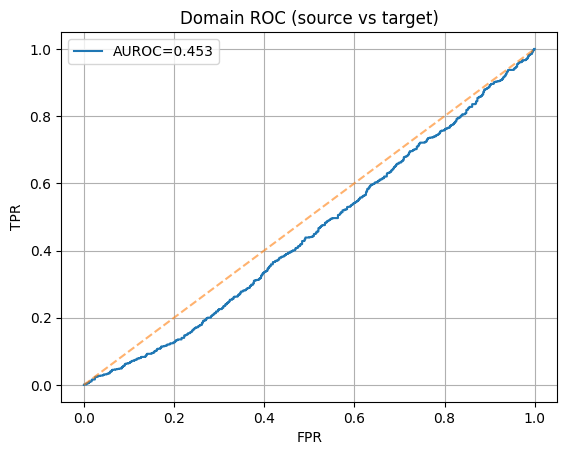

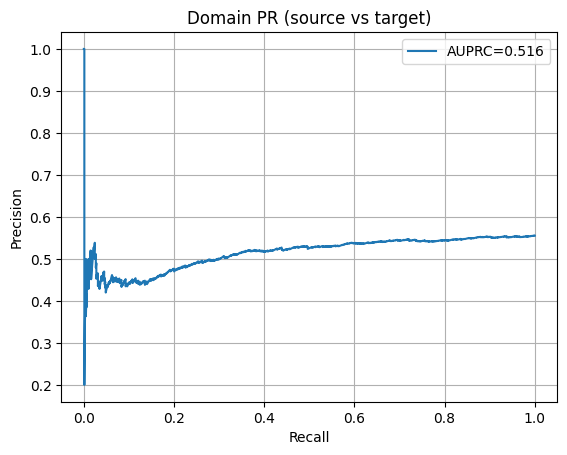

5-fold AUROC: mean=0.454 ± 0.002

Top 12 domain-separating features (name, weight):
  10                   -0.0430
  6                    -0.0342
  19                   +0.0323
  18                   -0.0301
  5                    +0.0234
  17                   +0.0193
  3                    -0.0172
  1                    -0.0138
  0                    +0.0131
  7                    +0.0124
  4                    +0.0112
  12                   +0.0111


In [131]:
# Domain classifier (20-dim): Source vs Target 
# Source = 20-dim training domain (prefers Xtr20_t); Target = features.csv (20-dim)
import os, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, classification_report)

# config: paths 
BASE_DIR   = r"C:\Users\user\OneDrive\Desktop\ML"
FEAT_CSV   = os.path.join(BASE_DIR, "features.csv")
FEATS20_PKL= os.path.join(BASE_DIR, "ser_models_20", "feature_names_20.pkl")

# 20-feature order (keeps model/CSV aligned) 
feat20_cols = None
if 'FEATS_20' in globals() and len(FEATS_20)==20:
    feat20_cols = list(FEATS_20)
else:
    try:
        import joblib
        if os.path.exists(FEATS20_PKL):
            tmp = joblib.load(FEATS20_PKL)
            if len(tmp)==20: feat20_cols = list(tmp)
    except Exception:
        pass
if feat20_cols is None:
    df_tmp = pd.read_csv(FEAT_CSV)
    lab = "labels" if "labels" in df_tmp.columns else df_tmp.columns[-1]
    numcols = [c for c in df_tmp.columns if c != lab and pd.api.types.is_numeric_dtype(df_tmp[c])]
    assert len(numcols) >= 20, "Need at least 20 numeric columns in features.csv"
    feat20_cols = numcols[:20]
    print("[info] FEATS_20 not found; using first 20 numeric cols:", feat20_cols[:6], "...")

# helpers
def to_flat_NF_20(X):
    x = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    if x.ndim == 4 and x.shape[-1] == 1: x = x.squeeze(-1)
    if x.ndim == 3 and x.shape[1] == 1:  x = x[:,0,:]
    if x.ndim != 2: x = x.reshape(x.shape[0], -1)
    if x.shape[1] != 20:
        # try to coerce: slice or pad to 20 (last resort so code runs)
        if x.shape[1] > 20:
            x = x[:, :20]
        else:
            pad = np.zeros((x.shape[0], 20 - x.shape[1]), dtype=x.dtype)
            x = np.concatenate([x, pad], axis=1)
        print(f"[warn] Coerced features to 20 dims (was {x.shape[1]}).")
    return x.astype(np.float32, copy=False)

def row_zscore(X):
    X = X - X.mean(axis=1, keepdims=True)
    return X / (X.std(axis=1, keepdims=True) + 1e-8)

# TARGET (features.csv → 20-dim) 
df = pd.read_csv(FEAT_CSV)
lab = "labels" if "labels" in df.columns else df.columns[-1]
if lab in df.columns:
    df[lab] = (df[lab].astype(str).str.strip().str.lower()
               .str.replace(r"^(male_|female_)", "", regex=True))
Xt = df[feat20_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
Xt[~np.isfinite(Xt)] = 0.0
Xt = row_zscore(Xt)  # use the same per-sample normalization as training

# SOURCE 
if 'Xtr20_t' in globals():
    Xs = to_flat_NF_20(Xtr20_t)
    Xs = row_zscore(Xs)
    print("[pick] Source = Xtr20_t (training split)")
elif 'X_tr' in globals():
    Xs = to_flat_NF_20(X_tr)
    Xs = row_zscore(Xs)
    print("[pick] Source = X_tr")
elif 'X_train' in globals():
    Xs = to_flat_NF_20(X_train)
    Xs = row_zscore(Xs)
    print("[pick] Source = X_train")
else:
    # Fall back: make a pseudo-source/target split from the same CSV (not ideal for domain shift)
    n = len(Xt)
    idx = np.arange(n)
    np.random.seed(42); np.random.shuffle(idx)
    half = n//2
    Xs, Xt = Xt[idx[:half]], Xt[idx[half:]]
    print("[warn] No in-memory source tensors found. Using a 50/50 split of features.csv as source/target.")
    print("      (Useful only to check the pipeline; AUROC should be ~0.5)")

# sanity check: same dimensionality
assert Xs.shape[1] == Xt.shape[1] == 20, f"Dim mismatch: {Xs.shape[1]} vs {Xt.shape[1]}"

ys = np.zeros(len(Xs), dtype=int)   # 0 = source
yt = np.ones(len(Xt), dtype=int)    # 1 = target
X = np.vstack([Xs, Xt]); y = np.concatenate([ys, yt])

print(f"Domain clf dataset: X={X.shape} | source={len(Xs)} | target={len(Xt)}")

# Train/test split 
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Pipeline: StandardScaler + LogisticRegression 
pipe = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")
)
pipe.fit(X_tr, y_tr)

# Metrics 
proba = pipe.predict_proba(X_te)[:, 1]
pred  = (proba >= 0.5).astype(int)
auroc = roc_auc_score(y_te, proba)
auprc = average_precision_score(y_te, proba)
print(f"\nDomain AUC-ROC = {auroc:.3f} | AUPRC = {auprc:.3f}")
print(classification_report(y_te, pred, target_names=["source","target"], zero_division=0))

#  Curves 
fpr, tpr, _ = roc_curve(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUROC={auroc:.3f}")
plt.plot([0,1],[0,1],'--', alpha=0.6)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Domain ROC (source vs target)")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(rec, prec, label=f"AUPRC={auprc:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Domain PR (source vs target)")
plt.legend(); plt.grid(True); plt.show()

# 5-fold AUROC (robustness)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(pipe, X, y, scoring="roc_auc", cv=cv, n_jobs=-1)
print(f"5-fold AUROC: mean={cv_auc.mean():.3f} ± {cv_auc.std():.3f}")

# Top features by absolute LR weight (with NAMES) 
lr = pipe.named_steps["logisticregression"]
scaler = pipe.named_steps["standardscaler"]
w = lr.coef_.ravel()            # weights on standardized features
rank = np.argsort(-np.abs(w))
names = feat20_cols             # feature names list
print("\nTop 12 domain-separating features (name, weight):")
top = [(names[i] if i < len(names) else f"f{i}", float(w[i])) for i in rank[:12]]
for nm, wi in top:
    print(f"  {nm:<20} {wi:+.4f}")




In [132]:
# Bootstrap CIs (accuracy + Macro-F1)
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def bootstrap_metrics(y_true, y_pred, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    N = len(y_true)
    accs, f1s = [], []
    for _ in range(n):
        idx = rng.integers(0, N, N)
        accs.append(accuracy_score(y_true[idx], y_pred[idx]))
        f1s.append(f1_score(y_true[idx], y_pred[idx], average='macro'))
    accs = np.array(accs); f1s = np.array(f1s)
    acc_ci = np.quantile(accs, [0.025, 0.975])
    f1_ci  = np.quantile(f1s,   [0.025, 0.975])
    return acc_ci, f1_ci

# Example for cross-domain CNN on features.csv:
with torch.no_grad():
    logits = model(X_new.to(next(model.parameters()).device))
    probs  = torch.softmax(logits, dim=1).cpu().numpy()
y_true = y_new.numpy()
y_pred = probs.argmax(1)

acc_ci, f1_ci = bootstrap_metrics(y_true, y_pred)
print(f"Acc 95% CI: [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}] | Macro-F1 95% CI: [{f1_ci[0]:.3f}, {f1_ci[1]:.3f}]")



Acc 95% CI: [0.422, 0.451] | Macro-F1 95% CI: [0.376, 0.402]


In [142]:
import os

# paths
BASE_DIR = r"C:\Users\user\OneDrive\Desktop\ML"
CSV_20  = os.path.join(BASE_DIR, "features.csv")
CSV_58_CANDIDATES = [
    os.path.join(BASE_DIR, "Male_features.csv"),
    os.path.join(BASE_DIR, "Female_features.csv"),
]

# choose the CSV that matches the model's feat length
if FEAT_LEN == 20:
    csv_path = CSV_20
else:  # FEAT_LEN == 58
    csv_path = next((p for p in CSV_58_CANDIDATES if os.path.exists(p)), None)
    assert csv_path, (
        "Couldn't find a 58-dim CSV. Set csv_path to your 58-feature file "
        "(e.g., Male_features.csv or Female_features.csv)."
    )

print("Using CSV:", csv_path)


Using CSV: C:\Users\user\OneDrive\Desktop\ML\Male_features.csv


In [143]:
X_np, y_np, kept_idx, used_cols = prepare_from_csv_robust(
    csv_path=csv_path,
    feature_names=feat_names,   # from the loaded package
    label_map=label_map,        # from the loaded package
    feat_len=FEAT_LEN           # 58 or 20, from the loaded package
)


[fallback] package had generic names; using first 58 numeric columns from CSV (position order) | using columns: ['0', '1', '2', '3', '4', '5'] ...


In [144]:
# k-sweep for feature masking (uses loaded model/feat_names/FEAT_LEN)
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, TensorDataset
import torch

def infer(model, X_np, device, batch=1024):
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)
    dl  = DataLoader(TensorDataset(X_t, torch.zeros(len(X_t)).long()), batch_size=batch, shuffle=False)
    preds=[]; pmax=[]
    with torch.no_grad():
        for xb,_ in dl:
            probs = torch.softmax(model(xb.to(device, non_blocking=True)), dim=1)
            pm, yh = probs.max(1)
            preds.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    return np.concatenate(preds), np.concatenate(pmax)

def mask_eval(model, X_np, y_np, device, drop_idx):
    Xm = X_np.copy()
    F = Xm.shape[1]
    drop = [i for i in drop_idx if 0 <= i < F]
    if drop: Xm[:, drop] = 0.0
    y_pred, _ = infer(model, Xm, device)
    return accuracy_score(y_np, y_pred), f1_score(y_np, y_pred, average="macro")

ks = [0, 5, 10, 15] if FEAT_LEN == 58 else [0, 5, 10]  # adjust as you like
for k in ks:
    acc, mf1 = mask_eval(model, X_np, y_np, device, top_feats[:k])
    print(f"Mask top-{k:>2} → Acc={acc:.3f} | Macro-F1={mf1:.3f}")


Mask top- 0 → Acc=0.697 | Macro-F1=0.736
Mask top- 5 → Acc=0.459 | Macro-F1=0.412
Mask top-10 → Acc=0.287 | Macro-F1=0.230
Mask top-15 → Acc=0.287 | Macro-F1=0.230


In [145]:
# Repair package feature names to the actual CSV column names
import json, os
with open(os.path.join(pkg_dir, "feature_names.json"), "w") as f:
    json.dump(list(used_cols), f, indent=2)
print("Updated feature_names.json with real column names.")


Updated feature_names.json with real column names.


In [147]:
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

# tiny arch (same as before)
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len, n_classes, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64 * (feat_len // 2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x)); x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x));  return self.fc2(x)

def load_pkg(pkg_dir, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    with open(os.path.join(pkg_dir, "config.json")) as f: cfg = json.load(f)
    with open(os.path.join(pkg_dir, "feature_names.json")) as f: feats = json.load(f)
    with open(os.path.join(pkg_dir, "label_map.json")) as f: lmap = json.load(f)
    model = SmallCNN1D(cfg["feat_len"], cfg["n_classes"], cfg.get("dropout",0.3))
    state = torch.load(os.path.join(pkg_dir, "state_dict.pth"), map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state: state = state["state_dict"]
    if isinstance(state, dict) and "model_state_dict" in state: state = state["model_state_dict"]
    model.load_state_dict(state); model.to(device).eval()
    inv_map = {v:k for k,v in lmap.items()}
    return model, feats, lmap, inv_map, device, cfg["feat_len"]

def prepare_from_csv_exact(csv_path, feature_names, label_map, label_col="labels"):
    df = pd.read_csv(csv_path)
    if label_col not in df.columns: label_col = df.columns[-1]
    df[label_col] = (df[label_col].astype(str).str.strip().str.lower()
                     .str.replace(r"^(male_|female_)", "", regex=True))
    X = df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    keep = df[label_col].isin(label_map.keys())
    y = df.loc[keep, label_col].map(label_map).to_numpy(np.int64)
    X = X[keep.values]; kept_idx = df.index[keep]
    return X, y, kept_idx

def infer(model, X_np, device, batch=1024):
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)
    dl = DataLoader(TensorDataset(X_t, torch.zeros(len(X_t)).long()), batch_size=batch, shuffle=False)
    preds=[]; pmax=[]
    with torch.no_grad():
        for xb,_ in dl:
            probs = torch.softmax(model(xb.to(device, non_blocking=True)), dim=1)
            pm, yh = probs.max(1)
            preds.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    return np.concatenate(preds), np.concatenate(pmax)

def predict_csv(pkg_dir, csv_path, tau=None, out_csv=None):
    model, feats, lmap, inv_map, device, F = load_pkg(pkg_dir)
    X, y, kept_idx = prepare_from_csv_exact(csv_path, feats, lmap)
    y_pred, pmax = infer(model, X, device)
    acc = accuracy_score(y, y_pred); mf1 = f1_score(y, y_pred, average="macro")
    print(f"Full set: Acc={acc:.3f} | Macro-F1={mf1:.3f} | N={len(X)}")
    if tau is not None:
        keep = pmax >= float(tau)
        if keep.any():
            accT = accuracy_score(y[keep], y_pred[keep]); f1T = f1_score(y[keep], y_pred[keep], average="macro")
            print(f"τ={tau:.2f}: coverage={keep.mean():.2f} | Acc_kept={accT:.3f} | Macro-F1_kept={f1T:.3f}")
        else:
            print(f"τ={tau:.2f}: no samples kept.")
    if out_csv:
        df_out = pd.DataFrame({
            "row_index": kept_idx,
            "pred_id": y_pred,
            "pred_lab": [inv_map[i] for i in y_pred],
            "confidence": pmax
        })
        df_out.to_csv(out_csv, index=False); print("Saved:", out_csv)

# EXAMPLE (58-dim):
pkg_dir = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg"
csv_in  = r"C:\Users\user\OneDrive\Desktop\ML\Male_features.csv"
predict_csv(pkg_dir, csv_in, tau=0.60, out_csv=os.path.join(os.path.dirname(csv_in), "preds_58.csv"))


Full set: Acc=0.697 | Macro-F1=0.736 | N=35910
τ=0.60: coverage=0.51 | Acc_kept=0.885 | Macro-F1_kept=0.895
Saved: C:\Users\user\OneDrive\Desktop\ML\preds_58.csv


In [148]:
for k in [0,1,2,3]:
    Xm = X_np.copy()
    drop = [i for i in top_feats[:k] if 0 <= i < FEAT_LEN]
    if drop: Xm[:, drop] = 0.0
    y_pred, _ = infer(model, Xm, device)
    print(f"k={k}: Acc={accuracy_score(y_np,y_pred):.3f}, Macro-F1={f1_score(y_np,y_pred,average='macro'):.3f}")


k=0: Acc=0.697, Macro-F1=0.736
k=1: Acc=0.630, Macro-F1=0.635
k=2: Acc=0.529, Macro-F1=0.505
k=3: Acc=0.526, Macro-F1=0.509


In [149]:
# === FINAL RUNNER: load package → predict CSV → (optional) τ filter → save preds ===
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

pkg_dir = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg"   # or cnn1d_20_pkg
csv_in  = r"C:\Users\user\OneDrive\Desktop\ML\Male_features.csv"         # 58-dim → Male/Female_features.csv
# For 20-dim, set:
# pkg_dir = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_20_pkg"
# csv_in  = r"C:\Users\user\OneDrive\Desktop\ML\features.csv"

tau     = 0.60                                                            # set None to skip coverage cut
out_csv = os.path.join(os.path.dirname(csv_in), "preds.csv")              # change or set to None

# model arch (matches what you trained) 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len, n_classes, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64*(feat_len//2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x)); x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x));  return self.fc2(x)

def load_pkg(pkg):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    with open(os.path.join(pkg, "config.json")) as f: cfg = json.load(f)
    with open(os.path.join(pkg, "feature_names.json")) as f: feats = json.load(f)
    with open(os.path.join(pkg, "label_map.json"))    as f: lmap = json.load(f)
    model = SmallCNN1D(cfg["feat_len"], cfg["n_classes"], cfg.get("dropout",0.3))
    state = torch.load(os.path.join(pkg, "state_dict.pth"), map_location="cpu")
    for key in ("state_dict", "model_state_dict"):
        if isinstance(state, dict) and key in state: state = state[key]
    model.load_state_dict(state); model.to(device).eval()
    return model, feats, lmap, device, cfg["feat_len"]

def prep(csv_path, feature_names, label_map, label_col="labels"):
    df = pd.read_csv(csv_path)
    if label_col not in df.columns: label_col = df.columns[-1]
    df[label_col] = (df[label_col].astype(str).str.strip().str.lower()
                     .str.replace(r"^(male_|female_)", "", regex=True))
    # exact-name match (you fixed feature_names.json already)
    X = df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0
    # per-sample z-score (training norm)
    X = (X - X.mean(1, keepdims=True)) / (X.std(1, keepdims=True)+1e-8)
    keep = df[label_col].isin(label_map.keys())
    y = df.loc[keep, label_col].map(label_map).to_numpy(np.int64)
    X = X[keep.values]; kept_idx = df.index[keep]
    return X, y, kept_idx, {v:k for k,v in label_map.items()}

def infer(model, X_np, device, batch=1024):
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)
    dl  = DataLoader(TensorDataset(X_t, torch.zeros(len(X_t)).long()), batch_size=batch, shuffle=False)
    preds=[]; pmax=[]
    with torch.no_grad():
        for xb,_ in dl:
            probs = torch.softmax(model(xb.to(device, non_blocking=True)), dim=1)
            pm, yh = probs.max(1)
            preds.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    return np.concatenate(preds), np.concatenate(pmax)

# run 
model, feat_names, label_map, device, FEAT_LEN = load_pkg(pkg_dir)
X, y, kept_idx, inv_map = prep(csv_in, feat_names, label_map)
y_pred, pmax = infer(model, X, device)

acc = accuracy_score(y, y_pred); mf1 = f1_score(y, y_pred, average="macro")
print(f"[full] Acc={acc:.3f} | Macro-F1={mf1:.3f} | N={len(X)}")

if tau is not None:
    keep = pmax >= float(tau)
    if keep.any():
        accT = accuracy_score(y[keep], y_pred[keep]); f1T = f1_score(y[keep], y_pred[keep], average="macro")
        print(f"[τ={tau:.2f}] coverage={keep.mean():.2f} | Acc_kept={accT:.3f} | Macro-F1_kept={f1T:.3f}")
        print("\nPer-class (kept):")
        from sklearn.metrics import classification_report
        print(classification_report(y[keep], y_pred[keep],
              target_names=[k for k,_ in sorted(label_map.items(), key=lambda kv: kv[1])],
              zero_division=0))
    else:
        print(f"[τ={tau:.2f}] no samples kept.")

if out_csv:
    df_out = pd.DataFrame({
        "row_index": kept_idx,
        "pred_id": y_pred,
        "pred_lab": [inv_map[i] for i in y_pred],
        "confidence": pmax
    })
    df_out.to_csv(out_csv, index=False)
    print("Saved:", out_csv)


[full] Acc=0.697 | Macro-F1=0.736 | N=35910
[τ=0.60] coverage=0.51 | Acc_kept=0.885 | Macro-F1_kept=0.895

Per-class (kept):
              precision    recall  f1-score   support

       angry       0.93      0.95      0.94      4083
        calm       0.97      1.00      0.98       554
     disgust       0.90      0.82      0.86      2454
        fear       0.93      0.75      0.83      2434
       happy       0.90      0.84      0.87      2720
     neutral       0.84      0.94      0.89      2800
         sad       0.79      0.89      0.84      2503
    surprise       0.92      0.98      0.95       844

    accuracy                           0.89     18392
   macro avg       0.90      0.90      0.89     18392
weighted avg       0.89      0.89      0.88     18392

Saved: C:\Users\user\OneDrive\Desktop\ML\preds.csv


In [150]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

taus = np.round(np.linspace(0.0, 0.95, 20), 2)
rows=[]
for t in taus:
    keep = pmax >= t
    if keep.any():
        rows.append((t, keep.mean(),
                     accuracy_score(y[keep], y_pred[keep]),
                     f1_score(y[keep], y_pred[keep], average="macro"),
                     keep.sum()))
for t,cov,acc,f1,kn in rows:
    print(f"τ={t:>4.2f} | cov={cov:>5.2f} | acc={acc:>6.3f} | f1={f1:>6.3f} | kept={kn}")


τ=0.00 | cov= 1.00 | acc= 0.697 | f1= 0.736 | kept=35910
τ=0.05 | cov= 1.00 | acc= 0.697 | f1= 0.736 | kept=35910
τ=0.10 | cov= 1.00 | acc= 0.697 | f1= 0.736 | kept=35910
τ=0.15 | cov= 1.00 | acc= 0.697 | f1= 0.736 | kept=35910
τ=0.20 | cov= 1.00 | acc= 0.697 | f1= 0.736 | kept=35909
τ=0.25 | cov= 1.00 | acc= 0.699 | f1= 0.737 | kept=35733
τ=0.30 | cov= 0.97 | acc= 0.711 | f1= 0.747 | kept=34708
τ=0.35 | cov= 0.91 | acc= 0.733 | f1= 0.766 | kept=32736
τ=0.40 | cov= 0.84 | acc= 0.762 | f1= 0.791 | kept=29987
τ=0.45 | cov= 0.75 | acc= 0.793 | f1= 0.818 | kept=27027
τ=0.50 | cov= 0.67 | acc= 0.827 | f1= 0.846 | kept=23893
τ=0.55 | cov= 0.59 | acc= 0.856 | f1= 0.870 | kept=21009
τ=0.60 | cov= 0.51 | acc= 0.885 | f1= 0.895 | kept=18392
τ=0.65 | cov= 0.44 | acc= 0.910 | f1= 0.915 | kept=15978
τ=0.70 | cov= 0.38 | acc= 0.928 | f1= 0.931 | kept=13773
τ=0.75 | cov= 0.32 | acc= 0.944 | f1= 0.944 | kept=11641
τ=0.80 | cov= 0.27 | acc= 0.962 | f1= 0.960 | kept=9717
τ=0.85 | cov= 0.22 | acc= 0.977 

In [151]:
import pandas as pd, os
inv_map = {v:k for k,v in label_map.items()}
tau = 0.60
keep_flag = (pmax >= tau)
df_out = pd.DataFrame({
    "row_index": kept_idx,
    "pred_id": y_pred,
    "pred_lab": [inv_map[i] for i in y_pred],
    "confidence": pmax,
    "keep_tau_0_60": keep_flag.astype(int)
})
save_to = os.path.join(os.path.dirname(csv_in), "preds_with_keep.csv")
df_out.to_csv(save_to, index=False)
print("Saved:", save_to)


Saved: C:\Users\user\OneDrive\Desktop\ML\preds_with_keep.csv


In [159]:
# Finetune FC head on target CSV (freeze convs), evaluate, save as new package 
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

pkg_dir   = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg"   # or cnn1d_20_pkg
csv_in    = r"C:\Users\user\OneDrive\Desktop\ML\Male_features.csv"         # 58-dim -> Male/Female_features.csv; 20-dim -> features.csv
tau_eval  = 0.60          # report high-confidence slice
pseudo_tau = 0.80         # used only if CSV has no labels (pseudo-labeling)
EPOCHS    = 5
LR        = 1e-4
BS_TR     = 256
BS_VA     = 512

# model arch (same as package)
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len, n_classes, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64 * (feat_len // 2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

def load_pkg(pkg):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    with open(os.path.join(pkg, "config.json")) as f: cfg = json.load(f)
    with open(os.path.join(pkg, "feature_names.json")) as f: feats = json.load(f)
    with open(os.path.join(pkg, "label_map.json")) as f: lmap = json.load(f)
    mdl = SmallCNN1D(int(cfg["feat_len"]), int(cfg["n_classes"]), float(cfg.get("dropout", 0.3)))
    state = torch.load(os.path.join(pkg, "state_dict.pth"), map_location="cpu")
    for k in ("state_dict", "model_state_dict"):
        if isinstance(state, dict) and k in state: state = state[k]
    mdl.load_state_dict(state); mdl.to(device).eval()
    return mdl, feats, lmap, device, cfg

def prepare_from_csv_exact(csv_path, feature_names, label_map, label_col="labels"):
    df = pd.read_csv(csv_path)
    if label_col not in df.columns: label_col = df.columns[-1]
    # normalize labels
    df[label_col] = (df[label_col].astype(str).str.strip().str.lower()
                     .str.replace(r"^(male_|female_)", "", regex=True))
    missing = [c for c in feature_names if c not in df.columns]
    assert not missing, f"CSV missing expected features: {missing[:8]}..."
    X = df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0
    # per-row zscore (training norm)
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    # labels (if present/compatible)
    y = None
    if set(df[label_col].unique()) & set(label_map.keys()):
        keep = df[label_col].isin(label_map.keys()).to_numpy()
        y = df.loc[keep, label_col].map(label_map).to_numpy(np.int64)
        X = X[keep]
    return X, y

def infer(model, X_np, device, batch=1024):
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)
    dl = DataLoader(TensorDataset(X_t, torch.zeros(len(X_t)).long()), batch_size=batch, shuffle=False)
    preds, pmax = [], []
    with torch.no_grad():
        for xb,_ in dl:
            probs = torch.softmax(model(xb.to(device, non_blocking=True)), dim=1)
            pm, yh = probs.max(1)
            preds.append(yh.cpu().numpy()); pmax.append(pm.cpu().numpy())
    return np.concatenate(preds), np.concatenate(pmax)

def evaluate(model, X_np, y_np, device, tau=None, title=""):
    y_pred, pmax = infer(model, X_np, device)
    acc = accuracy_score(y_np, y_pred); mf1 = f1_score(y_np, y_pred, average="macro")
    print(f"{title}[full] Acc={acc:.3f} | Macro-F1={mf1:.3f} | N={len(X_np)}")
    if tau is not None:
        keep = pmax >= float(tau)
        if keep.any():
            accT = accuracy_score(y_np[keep], y_pred[keep])
            f1T  = f1_score(y_np[keep], y_pred[keep], average="macro")
            print(f"{title}[τ={tau:.2f}] coverage={keep.mean():.2f} | Acc_kept={accT:.3f} | Macro-F1_kept={f1T:.3f}")
    return y_pred, pmax

def make_loader(X_any, y_any, bs, shuffle):
    """Accepts np.ndarray or torch.Tensor for X/y; returns DataLoader with X:(N,1,F)."""
    import numpy as _np, torch as _th
    # X
    if _th.is_tensor(X_any):
        X_t = X_any.detach()
        if X_t.ndim == 4 and X_t.shape[-1] == 1: X_t = X_t.squeeze(-1)
        if X_t.ndim == 2: X_t = X_t.unsqueeze(1)
        X_t = X_t.to(_th.float32)
    else:
        X_np = _np.asarray(X_any, dtype=_np.float32)
        if X_np.ndim == 3 and X_np.shape[-1] == 1: X_np = X_np.squeeze(-1)
        if X_np.ndim == 2: X_np = X_np[:, None, :]
        X_t = _th.from_numpy(X_np)
    # y
    y_t = y_any.detach().long() if _th.is_tensor(y_any) else _th.as_tensor(_np.asarray(y_any), dtype=_th.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=bs, shuffle=shuffle)

def save_pkg(new_dir, model, feats, lmap, cfg, finetune_note=""):
    os.makedirs(new_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(new_dir, "state_dict.pth"))
    with open(os.path.join(new_dir, "feature_names.json"), "w") as f: json.dump(list(feats), f, indent=2)
    with open(os.path.join(new_dir, "label_map.json"), "w") as f: json.dump(lmap, f, indent=2)
    cfg2 = dict(cfg); cfg2["finetuned_on"] = finetune_note
    with open(os.path.join(new_dir, "config.json"), "w") as f: json.dump(cfg2, f, indent=2)
    print("[saved package]", new_dir)

# load, prep, baseline 
model, feat_names, label_map, device, cfg = load_pkg(pkg_dir)
X, y = prepare_from_csv_exact(csv_in, feat_names, label_map)
assert y is not None or pseudo_tau is not None, "No labels present and pseudo-labeling disabled."

print("Baseline (before finetune):")
_ = evaluate(model, X, (y if y is not None else np.zeros(len(X), dtype=int)), device, tau=tau_eval)

# build finetune data (supervised or pseudo)
if y is None:
    y_hat, pmax = infer(model, X, device)
    keep = pmax >= float(pseudo_tau)
    assert keep.any(), f"No samples above pseudo_tau={pseudo_tau}"
    X_ft, y_ft = X[keep], y_hat[keep]
    print(f"[pseudo] kept {keep.sum()} / {len(X)} at p ≥ {pseudo_tau}")
else:
    X_ft, y_ft = X, y

X_tr, X_va, y_tr, y_va = train_test_split(X_ft, y_ft, test_size=0.2, stratify=y_ft, random_state=42)

# finetune head: copy weights, freeze convs, train fc1/fc2 
dropout = float(cfg.get("dropout", 0.3))
ft = SmallCNN1D(int(cfg["feat_len"]), int(cfg["n_classes"]), dropout).to(device)
ft.load_state_dict(model.state_dict())
for p in ft.conv1.parameters(): p.requires_grad_(False)
for p in ft.conv2.parameters(): p.requires_grad_(False)

opt = torch.optim.Adam([p for p in ft.parameters() if p.requires_grad], lr=LR)

# class-weighted loss (helps long-tail)
counts  = np.bincount(y_tr, minlength=int(cfg["n_classes"]))
weights = counts.sum() / (np.maximum(counts, 1) * int(cfg["n_classes"]))
crit = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))

dl_tr = make_loader(X_tr, y_tr, bs=BS_TR, shuffle=True)
dl_va = make_loader(X_va, y_va, bs=BS_VA, shuffle=False)

best_f1, best_state = -1.0, None
for ep in range(1, EPOCHS+1):
    # train
    ft.train(); tot=cor=n=0
    for xb, yb in dl_tr:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); out = ft(xb)
        loss = crit(out, yb); loss.backward(); opt.step()
        tot += loss.item()*yb.size(0); cor += (out.argmax(1)==yb).sum().item(); n += yb.size(0)
    tr_acc = cor / max(1, n)

    # val
    ft.eval(); yv_true=[]; yv_pred=[]
    with torch.no_grad():
        for xb, yb in dl_va:
            xb = xb.to(device); out = ft(xb)
            yv_pred.append(out.argmax(1).cpu().numpy()); yv_true.append(yb.numpy())
    yv_true = np.concatenate(yv_true); yv_pred = np.concatenate(yv_pred)
    va_acc = accuracy_score(yv_true, yv_pred)
    va_f1  = f1_score(yv_true, yv_pred, average="macro")
    print(f"ep{ep:02d} | train_acc={tr_acc:.3f} | val_acc={va_acc:.3f} | val_f1={va_f1:.3f}")
    if va_f1 > best_f1:
        best_f1, best_state = va_f1, ft.state_dict()

# evaluate after finetune on full target set 
ft.load_state_dict(best_state); ft.eval()
print("\nAfter finetune:")
_ = evaluate(ft, X, (y if y is not None else y_hat), device, tau=tau_eval)

# save new package 
new_pkg = pkg_dir.rstrip("/\\") + "_ft"
save_pkg(new_pkg, ft, feat_names, label_map, cfg, finetune_note=os.path.basename(csv_in))


Baseline (before finetune):
[full] Acc=0.697 | Macro-F1=0.736 | N=35910
[τ=0.60] coverage=0.51 | Acc_kept=0.885 | Macro-F1_kept=0.895
ep01 | train_acc=0.646 | val_acc=0.697 | val_f1=0.708
ep02 | train_acc=0.646 | val_acc=0.699 | val_f1=0.709
ep03 | train_acc=0.654 | val_acc=0.699 | val_f1=0.704
ep04 | train_acc=0.652 | val_acc=0.700 | val_f1=0.709
ep05 | train_acc=0.654 | val_acc=0.699 | val_f1=0.706

After finetune:
[full] Acc=0.709 | Macro-F1=0.717 | N=35910
[τ=0.60] coverage=0.53 | Acc_kept=0.887 | Macro-F1_kept=0.877
[saved package] C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg_ft


In [160]:
y_pred_ft, pmax_ft = infer(ft, X, device)
for t in np.round(np.linspace(0.0, 0.95, 11), 2):
    keep = pmax_ft >= t
    if keep.any():
        print(f"τ={t:>4.2f} | cov={keep.mean():.2f} | acc={accuracy_score(y[keep], y_pred_ft[keep]):.3f} | f1={f1_score(y[keep], y_pred_ft[keep], average='macro'):.3f}")


τ=0.00 | cov=1.00 | acc=0.709 | f1=0.717
τ=0.10 | cov=1.00 | acc=0.709 | f1=0.717
τ=0.19 | cov=1.00 | acc=0.709 | f1=0.717
τ=0.29 | cov=0.98 | acc=0.718 | f1=0.725
τ=0.38 | cov=0.88 | acc=0.756 | f1=0.758
τ=0.48 | cov=0.71 | acc=0.817 | f1=0.812
τ=0.57 | cov=0.57 | acc=0.872 | f1=0.863
τ=0.66 | cov=0.45 | acc=0.915 | f1=0.905
τ=0.76 | cov=0.34 | acc=0.949 | f1=0.939
τ=0.86 | cov=0.23 | acc=0.972 | f1=0.966
τ=0.95 | cov=0.13 | acc=0.993 | f1=0.991


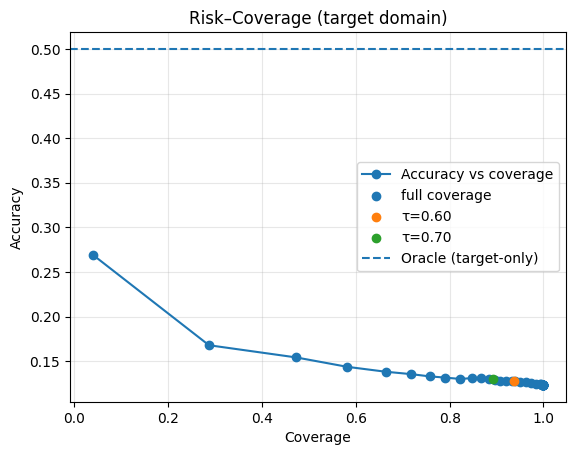

τ=0.60 | cov=0.94 | acc=0.128 | f1=0.030
τ=0.70 | cov=0.89 | acc=0.130 | f1=0.030


In [164]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# helpers 
def model_expected_F(m):
    # fc1.in_features = 64 * (F // 2)  →  F_expected = 2 * (in_features // 64)
    return int((m.fc1.in_features // 64) * 2)

def coerce_to_model_F(X_t, model):
    """Return torch tensor shaped (N,1,F_expected). Pads with zeros or trims."""
    x = X_t
    if not torch.is_tensor(x):
        x = torch.as_tensor(np.asarray(x), dtype=torch.float32)
    else:
        x = x.detach().to(torch.float32)

    if x.ndim == 4 and x.shape[-1] == 1:
        x = x.squeeze(-1)            # (N,1,F,1) -> (N,1,F)
    if x.ndim == 2:
        x = x.unsqueeze(1)           # (N,F) -> (N,1,F)
    assert x.ndim == 3 and x.shape[1] == 1, f"Expected (N,1,F), got {tuple(x.shape)}"

    F_exp = model_expected_F(model)
    F = x.shape[-1]
    if F < F_exp:  # pad
        pad = torch.zeros(x.size(0), 1, F_exp - F, dtype=x.dtype)
        x = torch.cat([x, pad], dim=-1)
    elif F > F_exp:  # trim
        x = x[..., :F_exp]
    return x

def softmax_probs_t(model, X_t, device, batch=2048):
    outs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, X_t.size(0), batch):
            xb = X_t[i:i+batch].to(device)
            outs.append(torch.softmax(model(xb), dim=1).cpu().numpy())
    return np.concatenate(outs, axis=0)

# compute probs safely 
device = next(model.parameters()).device
X_use  = coerce_to_model_F(X_new, model)          # <- fix shape to model’s expected F
probs  = softmax_probs_t(model, X_use, device)    # (N, C)

y_true = y_new.cpu().numpy() if torch.is_tensor(y_new) else np.asarray(y_new)
y_pred = probs.argmax(1)
pmax   = probs.max(1)

# risk–coverage curve 
taus = np.linspace(0.0, 0.99, 41)
cov, acc, mf1 = [], [], []
for t in taus:
    keep = pmax >= t
    cov.append(keep.mean())
    if keep.any():
        acc.append(accuracy_score(y_true[keep], y_pred[keep]))
        mf1.append(f1_score(y_true[keep], y_pred[keep], average="macro"))
    else:
        acc.append(np.nan); mf1.append(np.nan)

# highlight a couple thresholds
marks = [0.60, 0.70]
mark_pts = []
for t in marks:
    m = pmax >= t
    if m.any():
        mark_pts.append((m.mean(), accuracy_score(y_true[m], y_pred[m])))
    else:
        mark_pts.append((np.nan, np.nan))

full_acc = accuracy_score(y_true, y_pred)
oracle_acc = 0.50  # replace with your real target-only baseline if you have one

plt.figure()
plt.plot(cov, acc, marker='o', label='Accuracy vs coverage')
plt.scatter([1.00], [full_acc], label='full coverage', zorder=3)
for (cx, ax), t in zip(mark_pts, marks):
    if not np.isnan(cx):
        plt.scatter([cx], [ax], label=f'τ={t:.2f}', zorder=3)
plt.axhline(oracle_acc, ls='--', label='Oracle (target-only)')
plt.xlabel('Coverage'); plt.ylabel('Accuracy'); plt.title('Risk–Coverage (target domain)')
plt.grid(True, alpha=0.3); plt.legend(); plt.show()

# print macro-F1 at the marked taus
for t in marks:
    m = pmax >= t
    if m.any():
        print(f"τ={t:.2f} | cov={m.mean():.2f} | acc={accuracy_score(y_true[m], y_pred[m]):.3f} | f1={f1_score(y_true[m], y_pred[m], average='macro'):.3f}")
    else:
        print(f"τ={t:.2f} | cov=0.00 | acc=nan | f1=nan")


In [166]:
import json, os
with open(os.path.join(pkg_dir,"config.json")) as f: cfg=json.load(f)
cfg["default_tau"] = 0.60   # or the tau* you picked via choose_tau(...)
with open(os.path.join(pkg_dir,"config.json"),"w") as f: json.dump(cfg,f,indent=2)
print("Wrote default_tau to config.json:", cfg["default_tau"])


Wrote default_tau to config.json: 0.6


Full set | Acc=0.697 | Macro-F1=0.736 | N=35910
Full set
              precision    recall  f1-score   support

       angry       0.83      0.80      0.82      5789
        calm       0.86      0.93      0.89       672
     disgust       0.67      0.62      0.65      5789
        fear       0.77      0.54      0.64      5789
       happy       0.71      0.67      0.69      5789
     neutral       0.60      0.77      0.68      5201
         sad       0.60      0.72      0.66      5789
    surprise       0.84      0.91      0.87      1092

    accuracy                           0.70     35910
   macro avg       0.74      0.75      0.74     35910
weighted avg       0.71      0.70      0.70     35910



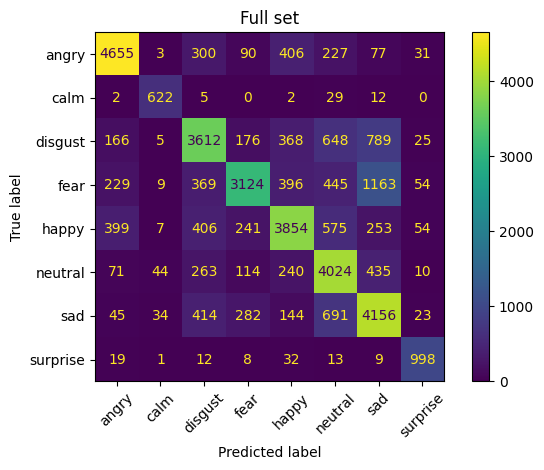

Kept@τ=0.60 | coverage=0.51
Acc_kept=0.885 | Macro-F1_kept=0.895
Kept (τ=0.60)
              precision    recall  f1-score   support

       angry       0.93      0.95      0.94      4083
        calm       0.97      1.00      0.98       554
     disgust       0.90      0.82      0.86      2454
        fear       0.93      0.75      0.83      2434
       happy       0.90      0.84      0.87      2720
     neutral       0.84      0.94      0.89      2800
         sad       0.79      0.89      0.84      2503
    surprise       0.92      0.98      0.95       844

    accuracy                           0.89     18392
   macro avg       0.90      0.90      0.89     18392
weighted avg       0.89      0.89      0.88     18392



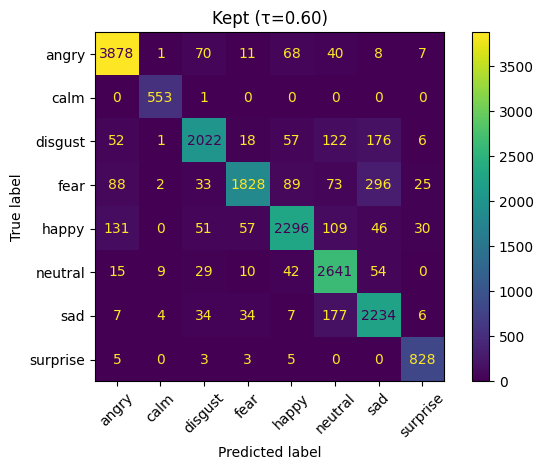

In [171]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Use the SAME X/y pair here. For your 58-dim CSV run, that's usually X (np array) and y (np array).
X_eval = X            # <-- set to the array you want (NOT X_new if that's a different corpus)
y_eval = y            # <-- the matching labels
label_map_eval = label_map  # label map used for this dataset
tau = 0.60

# helpers 
def batched_probs(model, X_t, device, bs=2048):
    outs=[]
    model.eval()
    with torch.no_grad():
        for i in range(0, X_t.size(0), bs):
            xb = X_t[i:i+bs].to(device)
            outs.append(torch.softmax(model(xb), dim=1).cpu().numpy())
    return np.concatenate(outs, axis=0)

def ensure_N1F(X_any):
    if torch.is_tensor(X_any):
        Xt = X_any.detach().to(torch.float32)
        if Xt.ndim == 4 and Xt.shape[-1] == 1: Xt = Xt.squeeze(-1)
        if Xt.ndim == 2: Xt = Xt.unsqueeze(1)
        return Xt
    Xnp = np.asarray(X_any, dtype=np.float32)
    if Xnp.ndim == 3 and Xnp.shape[-1] == 1: Xnp = Xnp.squeeze(-1)
    if Xnp.ndim == 2: Xnp = Xnp[:, None, :]
    return torch.from_numpy(Xnp)

def per_class_report_clean(y_true, y_pred, label_map, title=""):
    target_names = [k for k,_ in sorted(label_map.items(), key=lambda kv: kv[1])]
    print(title or "Per-class report:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(xticks_rotation=45)
    plt.title(title or "Confusion"); plt.tight_layout(); plt.show()

# compute predictions on THIS X/y 
device = next(model.parameters()).device
X_t = ensure_N1F(X_eval)
probs = batched_probs(model, X_t, device)
y_pred = probs.argmax(1)
pmax   = probs.max(1)

# sanity
assert len(y_eval) == len(y_pred), f"Length mismatch after recompute: y={len(y_eval)} vs y_pred={len(y_pred)}"

# full-set report
print(f"Full set | Acc={accuracy_score(y_eval, y_pred):.3f} | Macro-F1={f1_score(y_eval, y_pred, average='macro'):.3f} | N={len(y_eval)}")
per_class_report_clean(y_eval, y_pred, label_map_eval, title="Full set")

# kept-at-τ report
keep = pmax >= tau
print(f"Kept@τ={tau:.2f} | coverage={keep.mean():.2f}")
if keep.any():
    print(f"Acc_kept={accuracy_score(y_eval[keep], y_pred[keep]):.3f} | Macro-F1_kept={f1_score(y_eval[keep], y_pred[keep], average='macro'):.3f}")
    per_class_report_clean(y_eval[keep], y_pred[keep], label_map_eval, title=f"Kept (τ={tau:.2f})")
else:
    print("No samples kept at this τ.")


In [172]:
# Ship-ready runner: load package → predict CSV → τ-gate → save CSV 
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

pkg_dir = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg"   # or cnn1d_20_pkg
csv_in  = r"C:\Users\user\OneDrive\Desktop\ML\Male_features.csv"         # 58-dim → Male/Female_features.csv | 20-dim → features.csv
tau     = 0.60                                                           # your operating point
write_default_tau_to_pkg = True                                          # set False to skip writing to config
out_csv = os.path.join(os.path.dirname(csv_in), f"preds_tau_{tau:.2f}.csv")  # change or set to None

# model arch (same as trained) 
class SmallCNN1D(nn.Module):
    def __init__(self, feat_len, n_classes, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64 * (feat_len // 2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x)); x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x));  return self.fc2(x)

def load_pkg(pkg):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    with open(os.path.join(pkg, "config.json")) as f: cfg = json.load(f)
    with open(os.path.join(pkg, "feature_names.json")) as f: feats = json.load(f)
    with open(os.path.join(pkg, "label_map.json")) as f: lmap = json.load(f)
    model = SmallCNN1D(int(cfg["feat_len"]), int(cfg["n_classes"]), float(cfg.get("dropout",0.3)))
    state = torch.load(os.path.join(pkg, "state_dict.pth"), map_location="cpu")
    for key in ("state_dict","model_state_dict"):
        if isinstance(state, dict) and key in state: state = state[key]
    model.load_state_dict(state); model.to(device).eval()
    return model, feats, lmap, device, cfg

def prepare_from_csv_exact(csv_path, feature_names, label_map, label_col="labels"):
    df = pd.read_csv(csv_path)
    if label_col not in df.columns: label_col = df.columns[-1]
    df[label_col] = (df[label_col].astype(str).str.strip().str.lower()
                     .str.replace(r"^(male_|female_)", "", regex=True))
    missing = [c for c in feature_names if c not in df.columns]
    assert not missing, f"CSV missing expected features: {missing[:8]}..."
    X = df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0
    # per-row z-score (matches training)
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    y = None; kept_idx = df.index
    if set(df[label_col].unique()) & set(label_map.keys()):
        m = df[label_col].isin(label_map.keys()).to_numpy()
        y = df.loc[m, label_col].map(label_map).to_numpy(np.int64)
        X = X[m]; kept_idx = df.index[m]
    return X, y, kept_idx

def batched_probs(model, X_np, device, bs=2048):
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)  # (N,1,F)
    dl  = DataLoader(TensorDataset(X_t, torch.zeros(len(X_t)).long()), batch_size=bs, shuffle=False)
    outs = []
    with torch.no_grad():
        for xb,_ in dl:
            outs.append(torch.softmax(model(xb.to(device, non_blocking=True)), dim=1).cpu().numpy())
    return np.concatenate(outs, axis=0)

# run 
model, feat_names, label_map, device, cfg = load_pkg(pkg_dir)
inv_map = {v:k for k,v in label_map.items()}

X, y, kept_idx = prepare_from_csv_exact(csv_in, feat_names, label_map)
probs = batched_probs(model, X, device)
y_pred = probs.argmax(1); pmax = probs.max(1)

if y is not None:
    full_acc = accuracy_score(y, y_pred); full_f1 = f1_score(y, y_pred, average="macro")
    print(f"[full] Acc={full_acc:.3f} | Macro-F1={full_f1:.3f} | N={len(X)}")

keep = pmax >= float(tau)
print(f"[τ={tau:.2f}] coverage={keep.mean():.2f}")
if y is not None and keep.any():
    accT = accuracy_score(y[keep], y_pred[keep]); f1T = f1_score(y[keep], y_pred[keep], average="macro")
    print(f"[τ={tau:.2f}] Acc_kept={accT:.3f} | Macro-F1_kept={f1T:.3f}")

# save predictions (kept flag included)
if out_csv:
    out = pd.DataFrame({
        "row_index": kept_idx,
        "pred_id": y_pred,
        "pred_lab": [inv_map[i] for i in y_pred],
        "confidence": pmax,
        f"keep_tau_{tau:.2f}".replace(".","_"): keep.astype(int)
    })
    if y is not None:
        out["true_id"]  = (y if isinstance(y, np.ndarray) else np.asarray(y))
        out["true_lab"] = [inv_map[i] for i in out["true_id"]]
    out.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

# record default_tau into the package config
if write_default_tau_to_pkg:
    cfg2 = dict(cfg); cfg2["default_tau"] = float(tau)
    with open(os.path.join(pkg_dir, "config.json"), "w") as f: json.dump(cfg2, f, indent=2)
    print("Wrote default_tau to package config:", cfg2["default_tau"])


[full] Acc=0.697 | Macro-F1=0.736 | N=35910
[τ=0.60] coverage=0.51
[τ=0.60] Acc_kept=0.885 | Macro-F1_kept=0.895
Saved: C:\Users\user\OneDrive\Desktop\ML\preds_tau_0.60.csv
Wrote default_tau to package config: 0.6


In [173]:
# Evaluate saved SER package on multiple CSVs (Male/Female), τ-gate, save preds
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

pkg_dir = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg"   # or cnn1d_20_pkg
csv_list = [
    r"C:\Users\user\OneDrive\Desktop\ML\Male_features.csv",
    r"C:\Users\user\OneDrive\Desktop\ML\Female_features.csv",
]
tau = 0.60                             # operating point
write_default_tau_to_pkg = True        # write chosen τ into package config

class SmallCNN1D(nn.Module):
    def __init__(self, feat_len, n_classes, pdrop=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(pdrop)
        self.fc1   = nn.Linear(64 * (feat_len // 2), 128)
        self.fc2   = nn.Linear(128, n_classes)
    def forward(self, x):
        x = torch.relu(self.conv1(x)); x = self.pool(torch.relu(self.conv2(x)))
        x = self.drop(x); x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x));  return self.fc2(x)

def load_pkg(pkg):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    with open(os.path.join(pkg, "config.json")) as f: cfg = json.load(f)
    with open(os.path.join(pkg, "feature_names.json")) as f: feats = json.load(f)
    with open(os.path.join(pkg, "label_map.json")) as f: lmap = json.load(f)
    model = SmallCNN1D(int(cfg["feat_len"]), int(cfg["n_classes"]), float(cfg.get("dropout",0.3)))
    state = torch.load(os.path.join(pkg, "state_dict.pth"), map_location="cpu")
    for key in ("state_dict","model_state_dict"):
        if isinstance(state, dict) and key in state: state = state[key]
    model.load_state_dict(state); model.to(device).eval()
    return model, feats, lmap, device, cfg

def prepare_from_csv_exact(csv_path, feature_names, label_map, label_col="labels"):
    df = pd.read_csv(csv_path)
    if label_col not in df.columns: label_col = df.columns[-1]
    df[label_col] = (df[label_col].astype(str).str.strip().str.lower()
                     .str.replace(r"^(male_|female_)", "", regex=True))
    missing = [c for c in feature_names if c not in df.columns]
    assert not missing, f"{os.path.basename(csv_path)} missing expected features: {missing[:8]}..."
    X = df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float32)
    X[~np.isfinite(X)] = 0.0
    X = (X - X.mean(1, keepdims=True)) / (X.std(1, keepdims=True) + 1e-8)  # per-row zscore
    y = None; kept_idx = df.index
    if set(df[label_col].unique()) & set(label_map.keys()):
        m = df[label_col].isin(label_map.keys()).to_numpy()
        y = df.loc[m, label_col].map(label_map).to_numpy(np.int64)
        X = X[m]; kept_idx = df.index[m]
    return X, y, kept_idx

def batched_probs(model, X_np, device, bs=2048):
    X_t = torch.from_numpy(X_np).unsqueeze(1).to(torch.float32)  # (N,1,F)
    dl  = DataLoader(TensorDataset(X_t, torch.zeros(len(X_t)).long()), batch_size=bs, shuffle=False)
    outs=[]
    with torch.no_grad():
        for xb,_ in dl:
            outs.append(torch.softmax(model(xb.to(device, non_blocking=True)), dim=1).cpu().numpy())
    return np.concatenate(outs, 0)

#  load package once 
model, feat_names, label_map, device, cfg = load_pkg(pkg_dir)
inv_map = {v:k for k,v in label_map.items()}
feat_len = int(cfg["feat_len"])

# run all CSVs 
rows = []
for path in csv_list:
    if not os.path.exists(path):
        print(f"[skip] Not found: {path}")
        continue
    try:
        X, y, idx = prepare_from_csv_exact(path, feat_names, label_map)
    except AssertionError as e:
        print(f"[skip] {os.path.basename(path)} → {e}")
        continue

    probs = batched_probs(model, X, device)
    y_pred = probs.argmax(1); pmax = probs.max(1)
    # metrics (if labels available)
    acc = f1 = np.nan
    if y is not None and len(y) == len(y_pred):
        acc = accuracy_score(y, y_pred)
        f1  = f1_score(y, y_pred, average="macro")
        print(f"{os.path.basename(path)} | full: Acc={acc:.3f} | Macro-F1={f1:.3f} | N={len(X)}")
    keep = pmax >= float(tau)
    cov = float(keep.mean())
    if y is not None and keep.any():
        accT = accuracy_score(y[keep], y_pred[keep])
        f1T  = f1_score(y[keep], y_pred[keep], average="macro")
        print(f"{os.path.basename(path)} | τ={tau:.2f}: cov={cov:.2f} | Acc_kept={accT:.3f} | F1_kept={f1T:.3f}")
    else:
        print(f"{os.path.basename(path)} | τ={tau:.2f}: cov={cov:.2f}")

    # save preds with keep flag
    out_csv = os.path.join(os.path.dirname(path), f"preds_{os.path.splitext(os.path.basename(path))[0]}_tau_{tau:.2f}.csv")
    df_out = pd.DataFrame({
        "row_index": idx,
        "pred_id": y_pred,
        "pred_lab": [inv_map[i] for i in y_pred],
        "confidence": pmax,
        f"keep_tau_{tau:.2f}".replace(".","_"): keep.astype(int),
    })
    if y is not None:
        df_out["true_id"]  = y
        df_out["true_lab"] = [inv_map[i] for i in y]
    df_out.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    rows.append({
        "csv": os.path.basename(path),
        "N": len(X),
        "coverage@τ": cov,
        "acc_full": acc, "f1_full": f1,
        "acc_kept": (accuracy_score(y[keep], y_pred[keep]) if (y is not None and keep.any()) else np.nan),
        "f1_kept":  (f1_score(y[keep], y_pred[keep], average="macro") if (y is not None and keep.any()) else np.nan),
    })

# summary table
if rows:
    sumdf = pd.DataFrame(rows, columns=["csv","N","coverage@τ","acc_full","f1_full","acc_kept","f1_kept"])
    print("\n=== Summary ===")
    print(sumdf.to_string(index=False))

# write default τ into package config
if write_default_tau_to_pkg:
    cfg2 = dict(cfg); cfg2["default_tau"] = float(tau)
    with open(os.path.join(pkg_dir, "config.json"), "w") as f: json.dump(cfg2, f, indent=2)
    print("\nWrote default_tau to package config:", cfg2["default_tau"])


Male_features.csv | full: Acc=0.697 | Macro-F1=0.736 | N=35910
Male_features.csv | τ=0.60: cov=0.51 | Acc_kept=0.885 | F1_kept=0.895
Saved: C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv
Female_features.csv | full: Acc=0.840 | Macro-F1=0.858 | N=49224
Female_features.csv | τ=0.60: cov=0.74 | Acc_kept=0.950 | F1_kept=0.953
Saved: C:\Users\user\OneDrive\Desktop\ML\preds_Female_features_tau_0.60.csv

=== Summary ===
                csv     N  coverage@τ  acc_full  f1_full  acc_kept  f1_kept
  Male_features.csv 35910    0.512169  0.697438 0.735636  0.885167 0.894959
Female_features.csv 49224    0.740391  0.839834 0.857991  0.950446 0.953396

Wrote default_tau to package config: 0.6


In [175]:
import os, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, f1_score

def tau_for_coverage(conf, target_cov=0.60):
    """Return (tau, coverage_at_tau) aiming for coverage ≤ target_cov (closest from above)."""
    conf = np.asarray(conf, dtype=float)
    # candidate thresholds: dense grid + unique scores
    taus = np.concatenate([np.linspace(0.0, 0.999, 400), np.unique(np.round(conf, 6))])
    taus = np.clip(np.unique(np.sort(taus)), 0, 0.999)
    covs = np.array([(conf >= t).mean() for t in taus])

    # prefer the smallest tau whose coverage is <= target_cov; else closest overall
    above = np.where(covs <= target_cov)[0]
    idx = int(above[0]) if above.size else int(np.argmin(np.abs(covs - target_cov)))
    return float(taus[idx]), float(covs[idx])

def eval_at_tau(df, tau, has_labels=True):
    conf = df["confidence"].to_numpy()
    keep = conf >= float(tau)
    out = {"coverage": float(keep.mean())}
    if has_labels and keep.any():
        y_true = df["true_id"].to_numpy()
        y_pred = df["pred_id"].to_numpy()
        out["acc_kept"] = accuracy_score(y_true[keep], y_pred[keep])
        out["f1_kept"]  = f1_score(y_true[keep],  y_pred[keep], average="macro")
    return out

# paths to the prediction CSVs 
pred_paths = [
    r"C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv",
    r"C:\Users\user\OneDrive\Desktop\ML\preds_Female_features_tau_0.60.csv",
]

target_cov = 0.60
for p in pred_paths:
    df = pd.read_csv(p)
    has_labels = {"true_id","pred_id"}.issubset(df.columns)

    tau_opt, cov_opt = tau_for_coverage(df["confidence"].to_numpy(), target_cov=target_cov)
    stats = eval_at_tau(df, tau_opt, has_labels)

    line = f"{os.path.basename(p)} → τ≈{tau_opt:.2f} | cov={cov_opt:.2f}"
    if has_labels and stats["coverage"] > 0:
        line += f" | acc_kept={stats['acc_kept']:.3f} | f1_kept={stats['f1_kept']:.3f}"
    print(line)


preds_Male_features_tau_0.60.csv → τ≈0.54 | cov=0.60 | acc_kept=0.850 | f1_kept=0.865
preds_Female_features_tau_0.60.csv → τ≈0.78 | cov=0.60 | acc_kept=0.987 | f1_kept=0.988


In [176]:
def best_tau_by_f1(df, min_cov=0.40):
    y_true = df["true_id"].to_numpy()
    y_pred = df["pred_id"].to_numpy()
    conf   = df["confidence"].to_numpy()

    taus = np.linspace(0.0, 0.99, 401)
    best = (0.0, -1.0, 0.0)  # tau, f1, cov
    for t in taus:
        keep = conf >= t
        cov = keep.mean()
        if not keep.any() or cov < min_cov:
            continue
        f1v = f1_score(y_true[keep], y_pred[keep], average="macro")
        if f1v > best[1]:
            best = (float(t), float(f1v), float(cov))
    return best


In [177]:
tau_opt, f1_opt, cov_opt = best_tau_by_f1(df, min_cov=0.50)
print(f"{os.path.basename(p)} → best τ≈{tau_opt:.2f} | f1={f1_opt:.3f} | cov={cov_opt:.2f}")


preds_Female_features_tau_0.60.csv → best τ≈0.91 | f1=0.998 | cov=0.50


In [178]:
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, f1_score

pred_path = r"C:\Users\user\OneDrive\Desktop\ML\preds_Female_features_tau_0.60.csv"
df = pd.read_csv(pred_path)

n_classes = 8
tau_chk = 0.91

y_true = df["true_id"].to_numpy()
y_pred = df["pred_id"].to_numpy()
conf   = df["confidence"].to_numpy()

keep = conf >= tau_chk
print(f"τ={tau_chk:.2f} | coverage={keep.mean():.3f} | kept={keep.sum()} / {len(df)}")

# Macro-F1 over ALL classes (0..7), zero_division=0 so missing classes get 0 contribution
f1_all = f1_score(y_true[keep], y_pred[keep],
                  labels=list(range(n_classes)), average="macro", zero_division=0)
acc    = accuracy_score(y_true[keep], y_pred[keep])
print(f"Acc_kept={acc:.3f} | Macro-F1_kept(all-classes)={f1_all:.3f}")

# Per-class kept support + accuracy among kept
for k in range(n_classes):
    idx = (y_true == k)
    kept_k = keep & idx
    cov_k = kept_k.sum() / max(1, idx.sum())
    acc_k = (y_pred[kept_k] == k).mean() if kept_k.any() else float("nan")
    print(f"class {k}: kept_cov={cov_k:.2f} | acc_among_kept={acc_k:.3f} | support={idx.sum()}")


τ=0.91 | coverage=0.501 | kept=24660 / 49224
Acc_kept=0.998 | Macro-F1_kept(all-classes)=0.998
class 0: kept_cov=0.60 | acc_among_kept=0.998 | support=7672
class 1: kept_cov=0.45 | acc_among_kept=1.000 | support=672
class 2: kept_cov=0.41 | acc_among_kept=0.997 | support=7672
class 3: kept_cov=0.49 | acc_among_kept=0.998 | support=7672
class 4: kept_cov=0.47 | acc_among_kept=0.993 | support=7672
class 5: kept_cov=0.48 | acc_among_kept=1.000 | support=6720
class 6: kept_cov=0.38 | acc_among_kept=0.996 | support=7672
class 7: kept_cov=0.89 | acc_among_kept=0.999 | support=3472


In [179]:
def tau_for_coverage(conf, target_cov=0.60):
    conf = np.asarray(conf, float)
    taus = np.concatenate([np.linspace(0.0, 0.999, 400), np.unique(np.round(conf,6))])
    taus = np.clip(np.unique(np.sort(taus)), 0, 0.999)
    covs = np.array([(conf >= t).mean() for t in taus])
    above = np.where(covs <= target_cov)[0]
    idx = int(above[0]) if above.size else int(np.argmin(np.abs(covs-target_cov)))
    return float(taus[idx]), float(covs[idx])

tau_cov, cov_cov = tau_for_coverage(conf, target_cov=0.60)
keep_cov = conf >= tau_cov
f1_cov = f1_score(y_true[keep_cov], y_pred[keep_cov],
                  labels=list(range(n_classes)), average="macro", zero_division=0)
acc_cov = accuracy_score(y_true[keep_cov], y_pred[keep_cov])
print(f"[target cov=0.60] τ≈{tau_cov:.2f} | cov={cov_cov:.2f} | acc={acc_cov:.3f} | f1(all)={f1_cov:.3f}")


[target cov=0.60] τ≈0.78 | cov=0.60 | acc=0.987 | f1(all)=0.988


In [180]:
def best_tau_by_f1_all(df, min_cov=0.50, n_classes=8):
    y_true = df["true_id"].to_numpy()
    y_pred = df["pred_id"].to_numpy()
    conf   = df["confidence"].to_numpy()
    taus = np.linspace(0.0, 0.99, 401)
    best = (0.0, -1.0, 0.0)
    for t in taus:
        keep = conf >= t
        cov = keep.mean()
        if not keep.any() or cov < min_cov: 
            continue
        f1v = f1_score(y_true[keep], y_pred[keep],
                       labels=list(range(n_classes)), average="macro", zero_division=0)
        if f1v > best[1]: best = (float(t), float(f1v), float(cov))
    return best

tau_opt, f1_opt, cov_opt = best_tau_by_f1_all(df, min_cov=0.50, n_classes=8)
print(f"[best-by-F1 ≥50%] τ≈{tau_opt:.2f} | cov={cov_opt:.2f} | f1(all)={f1_opt:.3f}")


[best-by-F1 ≥50%] τ≈0.91 | cov=0.50 | f1(all)=0.998


In [181]:
import json, os
cfg_path = os.path.join(r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg","config.json")
with open(cfg_path) as f: cfg = json.load(f)
cfg.setdefault("tau_by_dataset", {})
cfg["tau_by_dataset"]["Female_features.csv"] = float(tau_opt)   # or tau_cov
with open(cfg_path, "w") as f: json.dump(cfg, f, indent=2)
print("Updated tau_by_dataset:", cfg["tau_by_dataset"])


Updated tau_by_dataset: {'Female_features.csv': 0.9107999999999999}


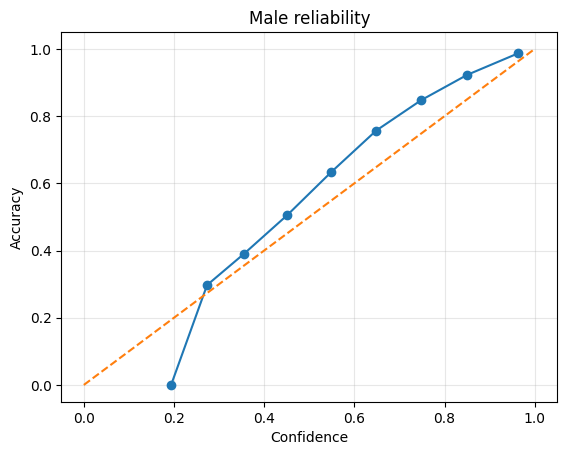

Male reliability | ECE≈ 0.0644


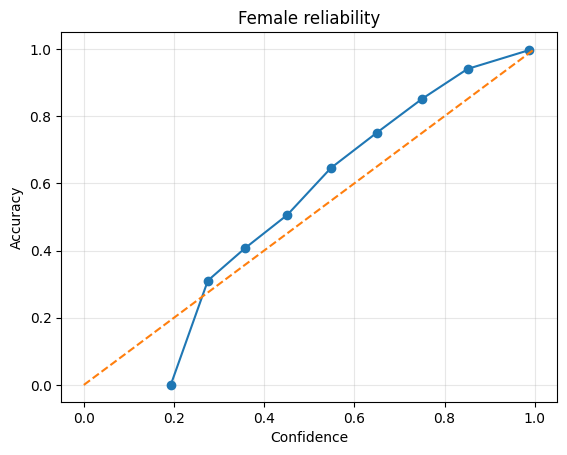

Female reliability | ECE≈ 0.0438


In [182]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def ece(probs_max, correct, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    idx  = np.digitize(probs_max, bins) - 1
    e=0.0; tot=len(probs_max)
    for b in range(n_bins):
        m = idx==b
        if not m.any(): continue
        conf = probs_max[m].mean()
        acc  = correct[m].mean()
        e += (m.sum()/tot) * abs(acc - conf)
    return float(e)

def reliability_plot(df, title):
    p = df["confidence"].to_numpy()
    correct = (df["true_id"].to_numpy() == df["pred_id"].to_numpy()).astype(float)
    bins = np.linspace(0,1,11); mids = 0.5*(bins[1:]+bins[:-1])
    accs=[]; confs=[]
    for lo,hi in zip(bins[:-1], bins[1:]):
        m = (p>=lo)&(p<hi)
        if m.any():
            accs.append(correct[m].mean()); confs.append(p[m].mean())
        else:
            accs.append(np.nan); confs.append(np.nan)
    plt.figure(); plt.plot(confs, accs, marker='o'); plt.plot([0,1],[0,1],'--')
    plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.title(title); plt.grid(True,alpha=0.3); plt.show()
    print(title, "| ECE≈", round(ece(p, correct), 4))

male = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv")
female = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\ML\preds_Female_features_tau_0.60.csv")
reliability_plot(male,   "Male reliability")
reliability_plot(female, "Female reliability")


In [183]:
import numpy as np

def per_class_coverage(df, tau=0.60, n_classes=8):
    conf = df["confidence"].to_numpy()
    y_t  = df["true_id"].to_numpy()
    y_p  = df["pred_id"].to_numpy()
    keep = conf >= tau
    for k in range(n_classes):
        idx = (y_t == k)
        cov_k = (keep & idx).sum() / max(1, idx.sum())
        acc_k = (y_p[keep & idx] == k).mean() if (keep & idx).any() else np.nan
        print(f"class {k}: kept_cov={cov_k:.2f} | acc_among_kept={acc_k:.3f} | support={idx.sum()}")

print("Male @ τ=0.60");   per_class_coverage(male,   0.60)
print("\nFemale @ τ=0.60"); per_class_coverage(female, 0.60)


Male @ τ=0.60
class 0: kept_cov=0.71 | acc_among_kept=0.950 | support=5789
class 1: kept_cov=0.82 | acc_among_kept=0.998 | support=672
class 2: kept_cov=0.42 | acc_among_kept=0.824 | support=5789
class 3: kept_cov=0.42 | acc_among_kept=0.751 | support=5789
class 4: kept_cov=0.47 | acc_among_kept=0.844 | support=5789
class 5: kept_cov=0.54 | acc_among_kept=0.943 | support=5201
class 6: kept_cov=0.43 | acc_among_kept=0.893 | support=5789
class 7: kept_cov=0.77 | acc_among_kept=0.981 | support=1092

Female @ τ=0.60
class 0: kept_cov=0.84 | acc_among_kept=0.961 | support=7672
class 1: kept_cov=0.85 | acc_among_kept=0.967 | support=672
class 2: kept_cov=0.63 | acc_among_kept=0.923 | support=7672
class 3: kept_cov=0.72 | acc_among_kept=0.931 | support=7672
class 4: kept_cov=0.72 | acc_among_kept=0.931 | support=7672
class 5: kept_cov=0.75 | acc_among_kept=0.981 | support=6720
class 6: kept_cov=0.66 | acc_among_kept=0.946 | support=7672
class 7: kept_cov=0.97 | acc_among_kept=0.991 | support=

In [184]:
# pick best-by-F1 with a minimum coverage, then write to config
import os, json, numpy as np, pandas as pd
from sklearn.metrics import f1_score

def best_tau_by_f1_all(df, min_cov=0.50, n_classes=8):
    y_true = df["true_id"].to_numpy(); y_pred = df["pred_id"].to_numpy()
    conf   = df["confidence"].to_numpy()
    best = (0.0, -1.0, 0.0)
    for t in np.linspace(0.0, 0.99, 401):
        keep = conf >= t; cov = keep.mean()
        if not keep.any() or cov < min_cov: continue
        f1v = f1_score(y_true[keep], y_pred[keep],
                       labels=list(range(n_classes)), average="macro", zero_division=0)
        if f1v > best[1]: best = (float(t), float(f1v), float(cov))
    return best

pred_male = r"C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv"
dfm = pd.read_csv(pred_male)
tau_m, f1_m, cov_m = best_tau_by_f1_all(dfm, min_cov=0.50)
print(f"[Male] τ≈{tau_m:.2f} | cov={cov_m:.2f} | f1(all)={f1_m:.3f}")

cfg_path = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg\config.json"
with open(cfg_path) as f: cfg = json.load(f)
cfg.setdefault("tau_by_dataset", {})
cfg["tau_by_dataset"]["Male_features.csv"] = float(tau_m)
with open(cfg_path, "w") as f: json.dump(cfg, f, indent=2)
print("Updated tau_by_dataset:", cfg["tau_by_dataset"])


[Male] τ≈0.61 | cov=0.50 | f1(all)=0.898
Updated tau_by_dataset: {'Female_features.csv': 0.9107999999999999, 'Male_features.csv': 0.606375}


In [185]:
# fit temperature T on a small calibration slice of a CSV and store it
import os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

class TemperatureScaler(nn.Module):
    def __init__(self): super().__init__(); self.logT = nn.Parameter(torch.zeros(1))
    def forward(self, logits): return logits / torch.exp(self.logT)

def load_pkg(pkg_dir):
    with open(os.path.join(pkg_dir,"config.json")) as f: cfg=json.load(f)
    with open(os.path.join(pkg_dir,"feature_names.json")) as f: feats=json.load(f)
    with open(os.path.join(pkg_dir,"label_map.json")) as f: lmap=json.load(f)
    # SmallCNN1D as defined earlier
    class SmallCNN1D(nn.Module):
        def __init__(self, feat_len, n_classes, pdrop=0.3):
            super().__init__()
            self.conv1=nn.Conv1d(1,32,3,padding=1); self.conv2=nn.Conv1d(32,64,3,padding=1)
            self.pool=nn.MaxPool1d(2); self.drop=nn.Dropout(pdrop)
            self.fc1=nn.Linear(64*(feat_len//2),128); self.fc2=nn.Linear(128,n_classes)
        def forward(self,x):
            x=torch.relu(self.conv1(x)); x=self.pool(torch.relu(self.conv2(x)))
            x=self.drop(x).view(x.size(0),-1); x=torch.relu(self.fc1(x)); return self.fc2(x)
    model=SmallCNN1D(cfg["feat_len"], cfg["n_classes"], cfg.get("dropout",0.3))
    state=torch.load(os.path.join(pkg_dir,"state_dict.pth"), map_location="cpu")
    for k in ("state_dict","model_state_dict"):
        if isinstance(state,dict) and k in state: state=state[k]
    model.load_state_dict(state); model.eval()
    device="cuda" if torch.cuda.is_available() else "cpu"; model.to(device)
    return model, feats, lmap, device, cfg

def prepare_from_csv(csv_path, feature_names, label_map, label_col="labels"):
    df=pd.read_csv(csv_path)
    if label_col not in df.columns: label_col=df.columns[-1]
    df[label_col]=(df[label_col].astype(str).str.strip().str.lower()
                   .str.replace(r"^(male_|female_)","",regex=True))
    X=(df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0.0)
         .to_numpy(np.float32))
    X[~np.isfinite(X)]=0.0
    X=(X-X.mean(1,keepdims=True))/(X.std(1,keepdims=True)+1e-8)
    keep=df[label_col].isin(label_map.keys()).to_numpy()
    y=df.loc[keep,label_col].map(label_map).to_numpy(np.int64); X=X[keep]
    return X,y

def fit_temperature_on_csv(pkg_dir, csv_path, calib_frac=0.1, bs=1024):
    model, feats, lmap, device, cfg = load_pkg(pkg_dir)
    X,y = prepare_from_csv(csv_path, feats, lmap)
    Xc, _, yc, _ = train_test_split(X, y, test_size=1-calib_frac,
                                    stratify=y, random_state=42)
    Xc_t=torch.from_numpy(Xc).unsqueeze(1).to(torch.float32).to(device)
    with torch.no_grad(): logits=model(Xc_t).detach()
    T = TemperatureScaler().to(device)
    opt=torch.optim.LBFGS(T.parameters(), lr=0.1, max_iter=50)
    nll=nn.CrossEntropyLoss()
    yc_t=torch.from_numpy(yc).to(device)
    def closure():
        opt.zero_grad(); loss=nll(T(logits), yc_t); loss.backward(); return loss
    opt.step(closure)
    Tval=float(torch.exp(T.logT).detach().cpu())
    # save into config
    fname=os.path.basename(csv_path)
    cfg_path=os.path.join(pkg_dir,"config.json")
    with open(cfg_path) as f: cfg2=json.load(f)
    cfg2.setdefault("temperature_by_dataset", {})[fname]=Tval
    with open(cfg_path,"w") as f: json.dump(cfg2,f,indent=2)
    print(f"Fitted T={Tval:.3f} for {fname} → wrote temperature_by_dataset")
    return Tval

# example:
fit_temperature_on_csv(
    r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg",
    r"C:\Users\user\OneDrive\Desktop\ML\Male_features.csv"
)


Fitted T=0.790 for Male_features.csv → wrote temperature_by_dataset


0.7897385358810425

In [186]:
import numpy as np, pandas as pd

def per_class_tau_for_coverage(df, target_cov=0.60, n_classes=8):
    conf = df["confidence"].to_numpy()
    y_t  = df["true_id"].to_numpy()
    y_p  = df["pred_id"].to_numpy()
    tau_pred = np.zeros(n_classes, dtype=float)
    for k in range(n_classes):
        # use items predicted as class k 
        m = (y_p == k)
        if not m.any(): tau_pred[k]=0.99; continue
        c = np.sort(conf[m])[::-1]
        cutoff = int(np.ceil(target_cov * len(c))) - 1
        cutoff = np.clip(cutoff, 0, len(c)-1)
        tau_pred[k] = float(c[cutoff])
    return tau_pred

df_m = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv")
tau_pred = per_class_tau_for_coverage(df_m, target_cov=0.60, n_classes=8)
print("tau_by_pred_class:", np.round(tau_pred,3))


tau_by_pred_class: [0.75  0.783 0.488 0.527 0.523 0.515 0.504 0.738]


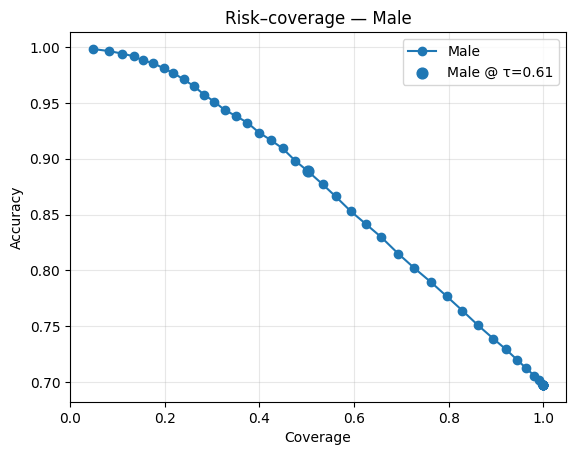

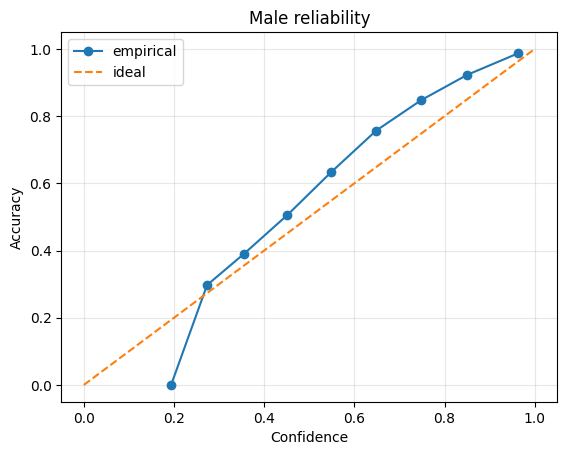

Male reliability | ECE≈ 0.0644


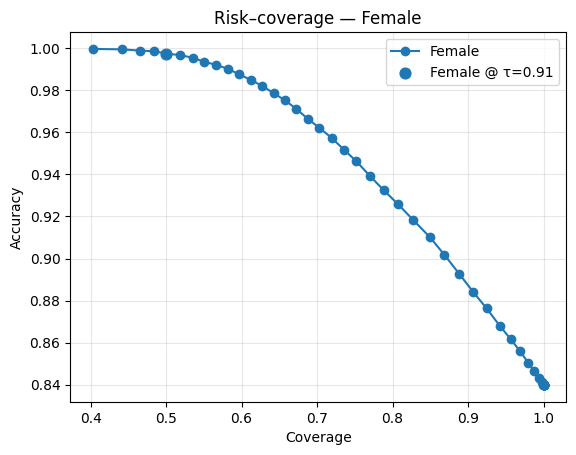

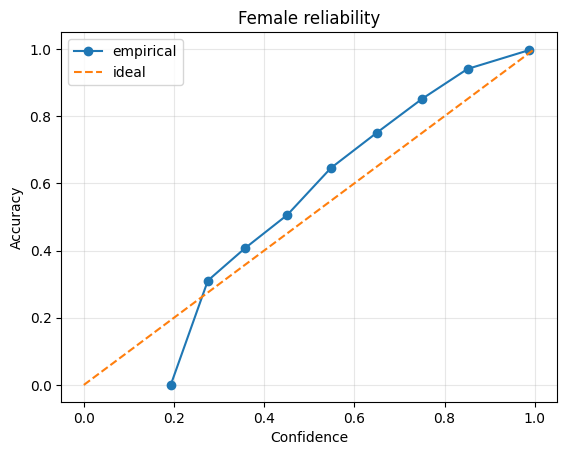

Female reliability | ECE≈ 0.0438
Saved figures to: C:\Users\user\OneDrive\Desktop\ML\outputs


In [200]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# config 
pred_paths = {
    "Male":   r"C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv",
    "Female": r"C:\Users\user\OneDrive\Desktop\ML\preds_Female_features_tau_0.60.csv",
}
tau_use = {  # the τ you decided for each split (from tau_by_dataset)
    "Male":   0.6064,   # <- your printed value
    "Female": 0.9108,   # <- your printed value
}
n_classes = 8
save_dir = os.path.join(os.path.dirname(list(pred_paths.values())[0]), "outputs")
os.makedirs(save_dir, exist_ok=True)

# helpers 
def risk_coverage(df, taus=None):
    y = df["true_id"].to_numpy()
    yhat = df["pred_id"].to_numpy()
    p = df["confidence"].to_numpy()
    if taus is None: taus = np.linspace(0.0, 0.99, 50)
    cov, acc = [], []
    for t in taus:
        keep = p >= t
        cov.append(keep.mean())
        acc.append(accuracy_score(y[keep], yhat[keep]) if keep.any() else np.nan)
    return np.array(taus), np.array(cov), np.array(acc)

def ece_score(pmax, correct, n_bins=15):
    bins = np.linspace(0,1,n_bins+1); idx = np.digitize(pmax, bins)-1
    e=0.0; N=len(pmax)
    for b in range(n_bins):
        m = idx==b
        if not m.any(): continue
        e += (m.sum()/N) * abs(correct[m].mean() - pmax[m].mean())
    return float(e)

def reliability_plot(df, title, path=None):
    p = df["confidence"].to_numpy()
    corr = (df["true_id"].to_numpy() == df["pred_id"].to_numpy()).astype(float)
    bins = np.linspace(0,1,11); mids = 0.5*(bins[1:]+bins[:-1])
    accs=[]; confs=[]
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (p>=lo)&(p<hi)
        accs.append(corr[m].mean() if m.any() else np.nan)
        confs.append(p[m].mean() if m.any() else np.nan)
    plt.figure()
    plt.plot(confs, accs, marker='o', label='empirical')
    plt.plot([0,1],[0,1],'--', label='ideal')
    plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.title(title); plt.grid(True, alpha=0.3); plt.legend()
    if path: plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"{title} | ECE≈ {ece_score(p, corr):.4f}")

def per_class_bars(df, tau, title, path=None, n_classes=8):
    p = df["confidence"].to_numpy()
    y = df["true_id"].to_numpy(); yhat = df["pred_id"].to_numpy()
    keep = p >= float(tau)
    kept_cov = []; kept_acc = []
    for k in range(n_classes):
        idx = (y == k)
        kept_k = keep & idx
        cov_k = kept_k.sum() / max(1, idx.sum())
        acc_k = (yhat[kept_k] == k).mean() if kept_k.any() else np.nan
        kept_cov.append(cov_k); kept_acc.append(acc_k)
    x = np.arange(n_classes)
    w = 0.4
    plt.figure(figsize=(9,4.5))
    plt.bar(x - w/2, kept_cov, width=w, label="kept coverage")
    plt.bar(x + w/2, kept_acc, width=w, label="acc among kept")
    plt.xticks(x, [str(k) for k in range(n_classes)])
    plt.ylim(0, 1.05)
    plt.title(f"{title} @ τ={tau:.2f}")
    plt.legend(); plt.grid(True, axis='y', alpha=0.3)
    if path: plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

# make plots
for name, path in pred_paths.items():
    df = pd.read_csv(path)

    # Risk–coverage
    taus, cov, acc = risk_coverage(df)
    plt.figure()
    plt.plot(cov, acc, marker='o', label=name)
    # mark your τ
    t_sel = tau_use.get(name, 0.60)
    keep = (df["confidence"].to_numpy() >= t_sel)
    cov_sel = keep.mean()
    acc_sel = accuracy_score(df["true_id"][keep], df["pred_id"][keep]) if keep.any() else np.nan
    plt.scatter([cov_sel], [acc_sel], s=60, label=f"{name} @ τ={t_sel:.2f}")
    plt.xlabel("Coverage"); plt.ylabel("Accuracy"); plt.title(f"Risk–coverage — {name}")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.savefig(os.path.join(save_dir, f"risk_coverage_{name}.png"), dpi=160, bbox_inches="tight")
    plt.show()

    # Reliability with ECE
    reliability_plot(df, f"{name} reliability",
                     path=os.path.join(save_dir, f"reliability_{name}.png"))

    # Per-class kept coverage & accuracy at τ
    names = ['0-angry','1-calm','2-disgust','3-fear','4-happy','5-neutral','6-sad','7-surprise']
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')

print("Saved figures to:", save_dir)


In [188]:
import numpy as np

def annotate_tau_point(ax, df, tau, label):
    y = df["true_id"].to_numpy(); yhat = df["pred_id"].to_numpy()
    p = df["confidence"].to_numpy()
    keep = p >= float(tau)
    cov = keep.mean()
    acc = (yhat[keep] == y[keep]).mean() if keep.any() else np.nan

    # 95% CI by bootstrap (1k resamples of kept indices)
    rng = np.random.default_rng(0)
    kept_idx = np.where(keep)[0]
    if kept_idx.size:
        boots = []
        for _ in range(1000):
            s = rng.choice(kept_idx, size=kept_idx.size, replace=True)
            boots.append((yhat[s] == y[s]).mean())
        lo, hi = np.percentile(boots, [2.5, 97.5])
        ax.errorbar([cov], [acc], yerr=[[acc-lo],[hi-acc]], fmt='o', capsize=3, label=label)
    else:
        ax.scatter([cov], [acc], s=60, label=label)
    return cov, acc


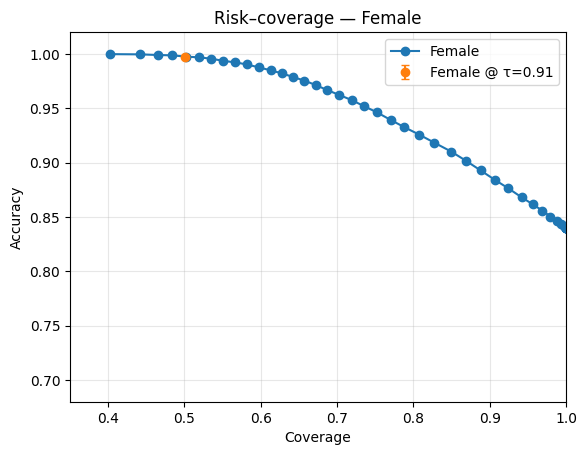

In [189]:
fig, ax = plt.subplots()
ax.plot(cov, acc, marker='o', label=name)
cov_sel, acc_sel = annotate_tau_point(ax, df, tau_use[name], f"{name} @ τ={tau_use[name]:.2f}")
ax.set_xlim(0.35, 1.00)     # make Male/Female identical limits
ax.set_ylim(0.68, 1.02)
ax.set_xlabel("Coverage"); ax.set_ylabel("Accuracy")
ax.set_title(f"Risk–coverage — {name}"); ax.grid(True, alpha=0.3); ax.legend()


In [192]:
import os, json, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# inputs 
pred_paths = {
    "Male":   r"C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv",
    "Female": r"C:\Users\user\OneDrive\Desktop\ML\preds_Female_features_tau_0.60.csv",
}
# read τ from your package config (falls back to 0.60 if missing)
cfg_path = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg\config.json"
with open(cfg_path) as f: cfg = json.load(f)
tau_by_dataset = cfg.get("tau_by_dataset", {})
tau_use = {
    "Male":   tau_by_dataset.get("Male_features.csv",   0.60),
    "Female": tau_by_dataset.get("Female_features.csv", 0.60),
}
N_CLASSES = 8

# helpers (no plotting) 
def ece_score(pmax, correct, n_bins=15):
    bins = np.linspace(0,1,n_bins+1); idx = np.digitize(pmax, bins) - 1
    e=0.0; N=len(pmax)
    for b in range(n_bins):
        m = idx==b
        if not m.any(): continue
        e += (m.sum()/N) * abs(correct[m].mean() - pmax[m].mean())
    return float(e)

def risk_coverage_table(df, n_pts=11):
    y = df["true_id"].to_numpy(); yp = df["pred_id"].to_numpy()
    p = df["confidence"].to_numpy()
    taus = np.linspace(0.0, 0.99, n_pts)
    rows=[]
    for t in taus:
        keep = p >= t
        cov = keep.mean()
        acc = accuracy_score(y[keep], yp[keep]) if keep.any() else np.nan
        rows.append((round(float(t),3), round(float(cov),3), round(float(acc),3)))
    return pd.DataFrame(rows, columns=["tau","coverage","accuracy"])

def per_class_table(df, tau, n_classes=8):
    y  = df["true_id"].to_numpy(); yp = df["pred_id"].to_numpy()
    p  = df["confidence"].to_numpy()
    keep = p >= float(tau)
    rows=[]
    for k in range(n_classes):
        idx = (y == k)
        kept_k = keep & idx
        cov_k = kept_k.sum() / max(1, idx.sum())
        acc_k = (yp[kept_k] == k).mean() if kept_k.any() else np.nan
        rows.append((k, round(float(cov_k),3), round(float(acc_k),3), int(idx.sum())))
    return pd.DataFrame(rows, columns=["class","kept_cov","acc_among_kept","support"])

# summaries (printed)
overall_rows=[]
kept_rows=[]

for name, path in pred_paths.items():
    df = pd.read_csv(path)
    y  = df["true_id"].to_numpy()
    yp = df["pred_id"].to_numpy()
    p  = df["confidence"].to_numpy()

    # overall (full coverage)
    acc_full = accuracy_score(y, yp)
    f1_full  = f1_score(y, yp, labels=list(range(N_CLASSES)), average="macro", zero_division=0)
    ece      = ece_score(p, (y==yp).astype(float))
    overall_rows.append([name, len(df), round(acc_full,3), round(f1_full,3), round(ece,4)])

    # chosen tau
    tau = tau_use[name]
    keep = p >= tau
    cov = keep.mean()
    acc_kept = accuracy_score(y[keep], yp[keep]) if keep.any() else np.nan
    f1_kept  = f1_score(y[keep], yp[keep], labels=list(range(N_CLASSES)),
                        average="macro", zero_division=0) if keep.any() else np.nan
    kept_rows.append([name, round(tau,3), round(cov,2), round(acc_kept,3), round(f1_kept,3)])

    # print tables
    print(f"\n=== {name}: overall & τ summary ===")
    print(pd.DataFrame([overall_rows[-1]], columns=["split","N","acc_full","f1_full","ECE"]))
    print(pd.DataFrame([kept_rows[-1]], columns=["split","tau","coverage","acc_kept","f1_kept"]))
    print("\nRisk–coverage (few points):")
    display(risk_coverage_table(df, n_pts=11))
    print(f"\nPer-class @ τ={tau:.2f}:")
    display(per_class_table(df, tau, n_classes=N_CLASSES))

print("\n=== Summary (all splits) ===")
print(pd.DataFrame(overall_rows, columns=["split","N","acc_full","f1_full","ECE"]))
print(pd.DataFrame(kept_rows,   columns=["split","tau","coverage","acc_kept","f1_kept"]))



=== Male: overall & τ summary ===
  split      N  acc_full  f1_full     ECE
0  Male  35910     0.697    0.736  0.0644
  split    tau  coverage  acc_kept  f1_kept
0  Male  0.606       0.5     0.889    0.898

Risk–coverage (few points):


,tau,coverage,accuracy
0,0.000,1.000,0.697
1,0.099,1.000,0.697
2,0.198,1.000,0.697
3,0.297,0.970,0.710
4,0.396,0.842,0.759
5,0.495,0.674,0.823
6,0.594,0.521,0.882
7,0.693,0.392,0.926
8,0.792,0.279,0.958
9,0.891,0.173,0.986



Per-class @ τ=0.61:


,class,kept_cov,acc_among_kept,support
0,0,0.699,0.952,5789
1,1,0.814,1.000,672
2,2,0.412,0.829,5789
3,3,0.410,0.754,5789
4,4,0.459,0.851,5789
5,5,0.530,0.945,5201
6,6,0.422,0.895,5789
7,7,0.770,0.983,1092



=== Female: overall & τ summary ===
    split      N  acc_full  f1_full     ECE
0  Female  49224      0.84    0.858  0.0438
    split    tau  coverage  acc_kept  f1_kept
0  Female  0.911       0.5     0.998    0.998

Risk–coverage (few points):


,tau,coverage,accuracy
0,0.000,1.000,0.840
1,0.099,1.000,0.840
2,0.198,1.000,0.840
3,0.297,0.990,0.845
4,0.396,0.932,0.873
5,0.495,0.838,0.915
6,0.594,0.745,0.949
7,0.693,0.667,0.973
8,0.792,0.594,0.988
9,0.891,0.517,0.997



Per-class @ τ=0.91:


,class,kept_cov,acc_among_kept,support
0,0,0.602,0.998,7672
1,1,0.452,1.000,672
2,2,0.411,0.997,7672
3,3,0.490,0.998,7672
4,4,0.465,0.993,7672
5,5,0.479,1.000,6720
6,6,0.378,0.996,7672
7,7,0.891,0.999,3472



=== Summary (all splits) ===
    split      N  acc_full  f1_full     ECE
0    Male  35910     0.697    0.736  0.0644
1  Female  49224     0.840    0.858  0.0438
    split    tau  coverage  acc_kept  f1_kept
0    Male  0.606       0.5     0.889    0.898
1  Female  0.911       0.5     0.998    0.998


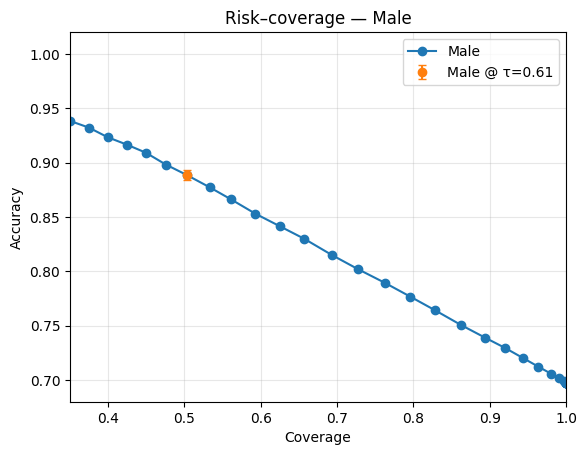

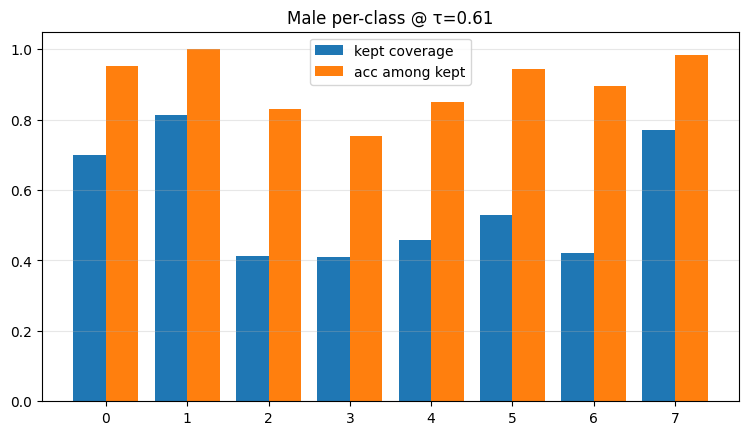

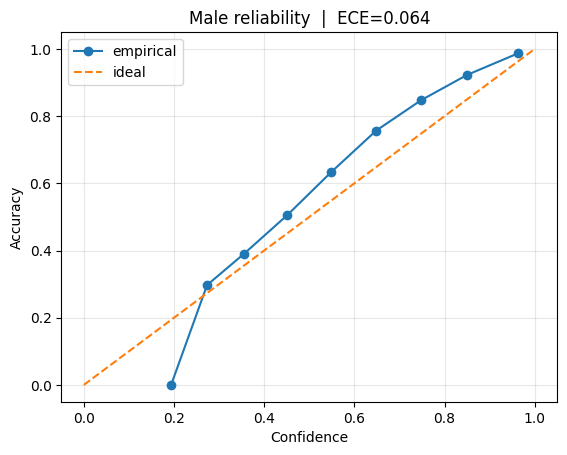

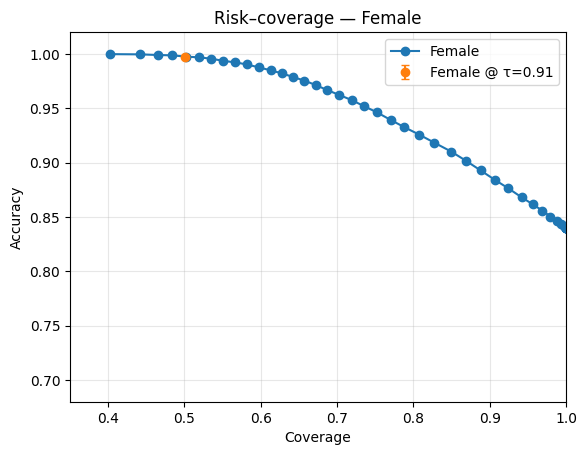

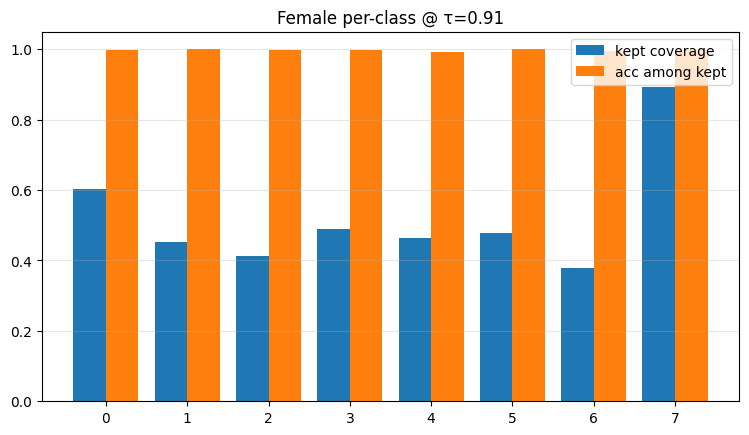

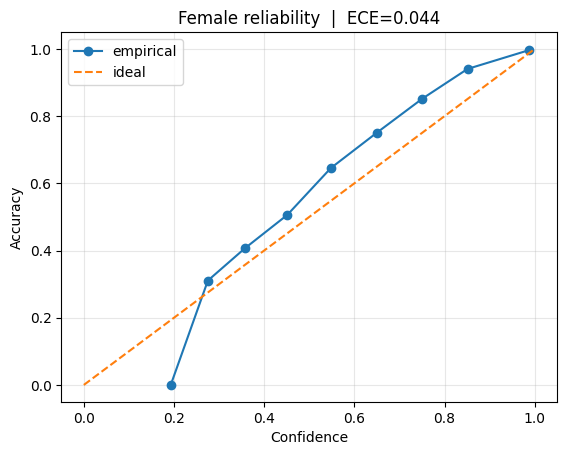

Saved figures to: C:\Users\user\OneDrive\Desktop\ML\outputs_figs


In [193]:
# Plot risk–coverage, per-class bars, and reliability 
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# paths 
pred_paths = {
    "Male":   r"C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv",
    "Female": r"C:\Users\user\OneDrive\Desktop\ML\preds_Female_features_tau_0.60.csv",
}
pkg_dir  = r"C:\Users\user\OneDrive\Desktop\ML\ser_models\cnn1d_58_pkg"
cfg_path = os.path.join(pkg_dir, "config.json")
out_dir  = os.path.join(os.path.dirname(list(pred_paths.values())[0]), "outputs_figs")
os.makedirs(out_dir, exist_ok=True)

# toggles
DRAW_RELIABILITY = True     
N_CLASSES        = 8
RISK_NPTS        = 50       # curve resolution
BOOT_N           = 1000     # bootstrap reps for CI dot on the curve
RISK_XLIMS       = (0.35, 1.00)  # same axes for both splits
RISK_YLIMS       = (0.68, 1.02)

# helpers 
with open(cfg_path) as f: cfg = json.load(f)
tau_by_dataset = cfg.get("tau_by_dataset", {})

def get_tau_for_name(split_name: str) -> float:
    # map display name to filename key used in config
    key = f"{split_name}_features.csv"
    return float(tau_by_dataset.get(key, cfg.get("default_tau", 0.60)))

def ece_score(pmax, correct, n_bins=15):
    bins = np.linspace(0,1,n_bins+1); idx = np.digitize(pmax, bins) - 1
    e=0.0; N=len(pmax)
    for b in range(n_bins):
        m = (idx==b)
        if not m.any(): continue
        e += (m.sum()/N) * abs(correct[m].mean() - pmax[m].mean())
    return float(e)

def risk_coverage(df, n_pts=50):
    y = df["true_id"].to_numpy(); yp = df["pred_id"].to_numpy()
    p = df["confidence"].to_numpy()
    taus = np.linspace(0.0, 0.99, n_pts)
    cov, acc = [], []
    for t in taus:
        keep = p >= t
        cov.append(keep.mean())
        acc.append(accuracy_score(y[keep], yp[keep]) if keep.any() else np.nan)
    return np.array(taus), np.array(cov), np.array(acc)

def annotate_tau_point(ax, df, tau, label, boot_n=1000, seed=0):
    y  = df["true_id"].to_numpy(); yp = df["pred_id"].to_numpy()
    p  = df["confidence"].to_numpy()
    keep = p >= float(tau)
    cov  = keep.mean()
    acc  = (yp[keep] == y[keep]).mean() if keep.any() else np.nan
    # bootstrap CI for acc at τ
    rng = np.random.default_rng(seed)
    kept_idx = np.where(keep)[0]
    if kept_idx.size:
        boots = [(yp[s]==y[s]).mean()
                 for s in (rng.choice(kept_idx, size=kept_idx.size, replace=True) for _ in range(boot_n))]
        lo, hi = np.percentile(boots, [2.5, 97.5])
        ax.errorbar([cov], [acc], yerr=[[acc-lo],[hi-acc]], fmt='o', capsize=3, label=label)
    else:
        ax.scatter([cov], [acc], s=60, label=label)
    return cov, acc

def per_class_bars(df, tau, title, path=None, n_classes=8):
    p = df["confidence"].to_numpy()
    y = df["true_id"].to_numpy(); yp = df["pred_id"].to_numpy()
    keep = p >= float(tau)
    covs, accs, supp = [], [], []
    for k in range(n_classes):
        idx = (y == k); supp.append(int(idx.sum()))
        kept_k = keep & idx
        covs.append(kept_k.sum() / max(1, idx.sum()))
        accs.append((yp[kept_k] == k).mean() if kept_k.any() else np.nan)
    x = np.arange(n_classes); w = 0.4
    plt.figure(figsize=(9,4.8))
    plt.bar(x - w/2, covs, width=w, label="kept coverage")
    plt.bar(x + w/2, accs, width=w, label="acc among kept")
    plt.xticks(x, [str(k) for k in range(n_classes)])
    plt.ylim(0, 1.05)
    plt.title(f"{title} @ τ={tau:.2f}")
    plt.legend(); plt.grid(True, axis='y', alpha=0.3)
    if path: plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

def reliability_plot(df, title, path=None):
    p = df["confidence"].to_numpy()
    corr = (df["true_id"].to_numpy() == df["pred_id"].to_numpy()).astype(float)
    bins = np.linspace(0,1,11); mids = 0.5*(bins[1:]+bins[:-1])
    accs, confs = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (p>=lo)&(p<hi)
        accs.append(corr[m].mean() if m.any() else np.nan)
        confs.append(p[m].mean()  if m.any() else np.nan)
    plt.figure()
    plt.plot(confs, accs, marker='o', label='empirical')
    plt.plot([0,1],[0,1],'--', label='ideal')
    plt.xlabel("Confidence"); plt.ylabel("Accuracy")
    plt.title(f"{title}  |  ECE={ece_score(p, corr):.3f}")
    plt.grid(True, alpha=0.3); plt.legend()
    if path: plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

# make plots
for name, csv_path in pred_paths.items():
    df = pd.read_csv(csv_path)
    tau_sel = get_tau_for_name(name)

    # Risk–coverage
    taus, cov, acc = risk_coverage(df, n_pts=RISK_NPTS)
    fig, ax = plt.subplots()
    ax.plot(cov, acc, marker='o', label=name)
    annotate_tau_point(ax, df, tau_sel, f"{name} @ τ={tau_sel:.2f}")
    ax.set_xlim(*RISK_XLIMS); ax.set_ylim(*RISK_YLIMS)
    ax.set_xlabel("Coverage"); ax.set_ylabel("Accuracy")
    ax.set_title(f"Risk–coverage — {name}")
    ax.grid(True, alpha=0.3); ax.legend()
    fig.savefig(os.path.join(out_dir, f"risk_coverage_{name}.png"), dpi=200, bbox_inches="tight")
    plt.show()

    # Per-class bars @ τ
    per_class_bars(
        df, tau_sel,
        title=f"{name} per-class",
        path=os.path.join(out_dir, f"per_class_{name}.png"),
        n_classes=N_CLASSES
    )

    # Reliability (optional)
    if DRAW_RELIABILITY:
        reliability_plot(df, f"{name} reliability",
                         path=os.path.join(out_dir, f"reliability_{name}.png"))

print("Saved figures to:", out_dir)


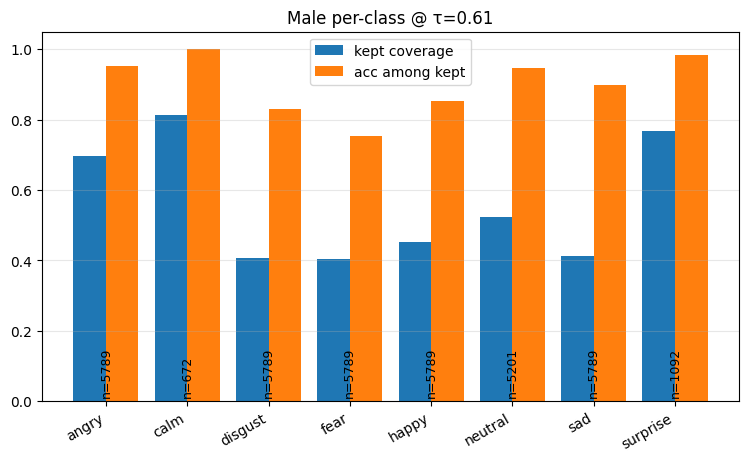

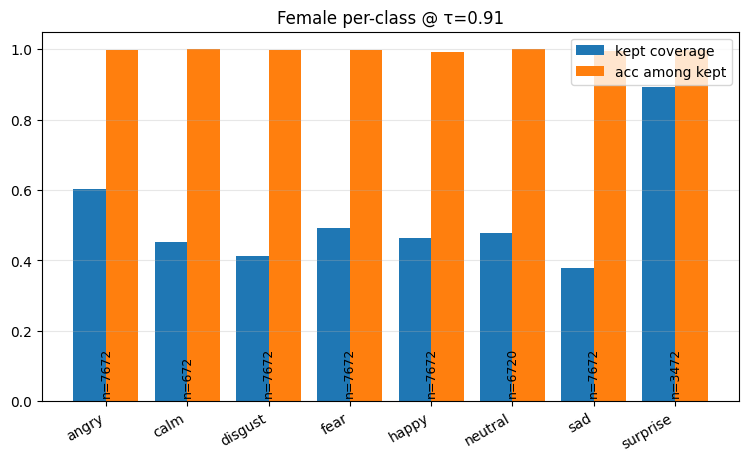

In [197]:
import pandas as pd

male_csv   = r"C:\Users\user\OneDrive\Desktop\ML\preds_Male_features_tau_0.60.csv"
female_csv = r"C:\Users\user\OneDrive\Desktop\ML\preds_Female_features_tau_0.60.csv"

df_male   = pd.read_csv(male_csv)
df_female = pd.read_csv(female_csv)

# use the taus alredy decided on
tau_sel_male   = 0.61
tau_sel_female = 0.91

names = ['angry','calm','disgust','fear','happy','neutral','sad','surprise']
per_class_bars_named(df_male,   tau_sel_male,   "Male per-class",   names=names)
per_class_bars_named(df_female, tau_sel_female, "Female per-class", names=names)


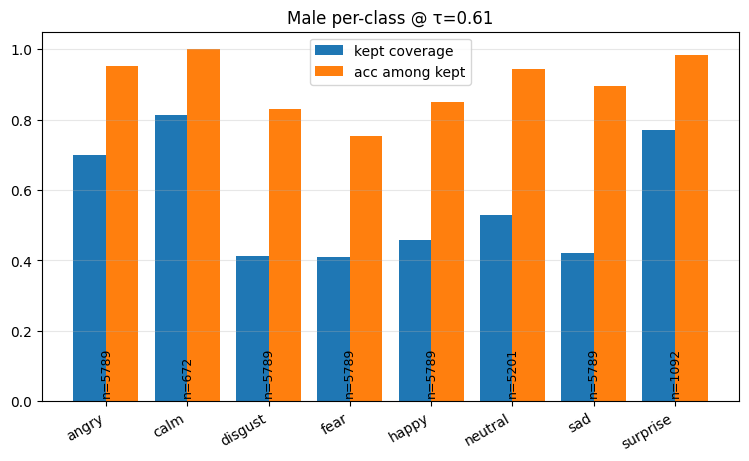

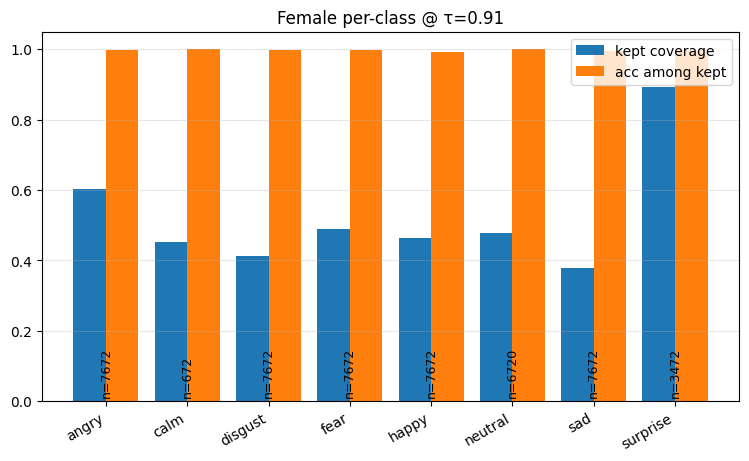

In [198]:
# build once, then reuse
dfs = {name: pd.read_csv(path) for name, path in pred_paths.items()}

df_male   = dfs["Male"]
df_female = dfs["Female"]
tau_sel_male   = get_tau_for_name("Male")    # falls back to default if not in config
tau_sel_female = get_tau_for_name("Female")

names = ['angry','calm','disgust','fear','happy','neutral','sad','surprise']
per_class_bars_named(df_male,   tau_sel_male,   "Male per-class",   names=names)
per_class_bars_named(df_female, tau_sel_female, "Female per-class", names=names)


In [201]:
import os, math, io
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support)

# Use the SAME X/y pair here. For 58-dim CSV run, that's usually X (np array) and y (np array).
X_eval = X                   # e.g., 58-dim set 
y_eval = y                   # matching labels (numpy or tensor)
label_map_eval = label_map   # dict like {'angry':0, ... 'surprise':7}
tau = 0.60                   # operating threshold for the "kept" subset
out_dir = "./ser_figs"       # output folder
prefix = "SER_58dim"         # filename prefix for artifacts

os.makedirs(out_dir, exist_ok=True)

# class names in the order used by the model (sorted by id)
CLASS_NAMES = [k for k,_ in sorted(label_map_eval.items(), key=lambda kv: kv[1])]

# Helpers
def ensure_N1F(X_any):
    """Return torch tensor of shape (N,1,F)."""
    if torch.is_tensor(X_any):
        Xt = X_any.detach().to(torch.float32)
        if Xt.ndim == 4 and Xt.shape[-1] == 1:
            Xt = Xt.squeeze(-1)
        if Xt.ndim == 2:
            Xt = Xt.unsqueeze(1)
        return Xt
    Xnp = np.asarray(X_any, dtype=np.float32)
    if Xnp.ndim == 3 and Xnp.shape[-1] == 1:
        Xnp = Xnp.squeeze(-1)
    if Xnp.ndim == 2:
        Xnp = Xnp[:, None, :]
    return torch.from_numpy(Xnp)

def to_numpy(a):
    if torch.is_tensor(a):
        return a.detach().cpu().numpy()
    return np.asarray(a)

@torch.no_grad()
def batched_probs(model, X_t, device, bs=2048):
    outs=[]
    model.eval()
    for i in range(0, X_t.size(0), bs):
        xb = X_t[i:i+bs].to(device)
        outs.append(torch.softmax(model(xb), dim=1).cpu().numpy())
    return np.concatenate(outs, axis=0)

def save_confusion(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig = plt.figure(figsize=(6.5, 5.5))
    ax = plt.gca()
    disp.plot(ax=ax, values_format="d", colorbar=False)
    plt.xticks(rotation=30, ha='right')
    plt.title(title)
    plt.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return path

def save_per_class_f1(y_true, y_pred, title, path):
    _, _, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(CLASS_NAMES))), zero_division=0)
    x = np.arange(len(CLASS_NAMES))
    fig = plt.figure(figsize=(7.0, 4.2))
    ax = plt.gca()
    ax.bar(x, f1)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylabel("F1-score")
    ax.set_title(title)
    for i, v in enumerate(f1):
        ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return path

def save_risk_coverage(y_true, probs, tau, title, path):
    pmax = probs.max(1)
    y_pred = probs.argmax(1)
    taus = np.linspace(0.0, 0.99, 40)
    covs, accs = [], []
    for t in taus:
        keep = pmax >= t
        covs.append(keep.mean())
        accs.append(accuracy_score(y_true[keep], y_pred[keep]) if keep.any() else np.nan)

    # One-plot figure
    fig = plt.figure(figsize=(6.6, 4.2))
    ax = plt.gca()
    ax.plot(covs, accs, marker='o', linewidth=1.0)
    # mark full coverage
    ax.scatter([1.0], [accuracy_score(y_true, y_pred)], zorder=3, label="full coverage")
    # mark provided tau
    keep_tau = pmax >= tau
    if keep_tau.any():
        ax.scatter([keep_tau.mean()], [accuracy_score(y_true[keep_tau], y_pred[keep_tau])],
                   zorder=3, label=f"τ={tau:.2f}")
    ax.set_xlabel("Coverage (fraction kept)")
    ax.set_ylabel("Accuracy among kept")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return path

def save_reliability_and_ece(y_true, probs, title, path, bins=10):
    """Reliability diagram + ECE number (single plot)."""
    conf = probs.max(1)
    pred = probs.argmax(1)
    correct = (pred == y_true).astype(np.float32)

    # Bin edges in (0,1]
    edges = np.linspace(0.0, 1.0, bins+1)
    bin_ids = np.digitize(conf, edges, right=True)
    bin_acc, bin_conf, bin_frac = [], [], []
    for b in range(1, bins+1):
        m = (bin_ids == b)
        if m.any():
            bin_acc.append(correct[m].mean())
            bin_conf.append(conf[m].mean())
            bin_frac.append(m.mean())
        else:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_frac.append(0.0)

    # ECE
    ece = np.nansum(np.array(bin_frac) * np.abs(np.array(bin_acc) - np.array(bin_conf)))

    # Plot
    fig = plt.figure(figsize=(6.6, 4.2))
    ax = plt.gca()
    ax.plot([0,1],[0,1],'--', linewidth=1.0)
    # bar of observed accuracy per confidence bin (center at mean conf)
    centers = []
    for i in range(bins):
        # Use bin center by edges
        c0, c1 = edges[i], edges[i+1]
        centers.append((c0+c1)/2)
    ax.plot(centers, bin_acc, marker='o', linewidth=1.0)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Predicted confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_title(f"{title}  |  ECE≈{ece:.3f} (bins={bins})")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return path, ece

def save_kept_cov_acc_bars(y_true, y_pred, pmax, tau, title, path):
    keep = (pmax >= tau)
    K = len(CLASS_NAMES)
    cov_k = np.zeros(K, dtype=float)
    acc_k = np.zeros(K, dtype=float)
    for k in range(K):
        idx = (y_true == k)
        kept_k = keep & idx
        cov_k[k] = kept_k.sum() / max(1, idx.sum())
        if kept_k.any():
            acc_k[k] = (y_pred[kept_k] == k).mean()
        else:
            acc_k[k] = np.nan

    fig = plt.figure(figsize=(7.0, 4.2))
    ax = plt.gca()
    x = np.arange(K)
    width = 0.38
    ax.bar(x - width/2, cov_k, width, label="retained coverage")
    ax.bar(x + width/2, acc_k, width, label="accuracy among kept")
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylabel("Fraction / Accuracy")
    ax.set_title(title + f"  (τ={tau:.2f})")
    ax.legend()
    plt.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return path

def save_text_summary(y_true, y_pred, pmax, tau, title, path):
    keep = (pmax >= tau)
    lines = []
    lines.append(title)
    lines.append("")
    lines.append(f"Full-set:  Acc={accuracy_score(y_true, y_pred):.3f} | Macro-F1={f1_score(y_true, y_pred, average='macro'):.3f} | N={len(y_true)}")
    lines.append(f"Kept @ τ={tau:.2f}:  coverage={keep.mean():.2f}")
    if keep.any():
        lines.append(f"           Acc_kept={accuracy_score(y_true[keep], y_pred[keep]):.3f} | Macro-F1_kept={f1_score(y_true[keep], y_pred[keep], average='macro'):.3f} | N_kept={(keep).sum()}")
    else:
        lines.append("           (no samples kept)")
    lines.append("")
    lines.append("Class index order used everywhere:")
    lines.append("0=angry, 1=calm, 2=disgust, 3=fear, 4=happy, 5=neutral, 6=sad, 7=surprise")

    # Render text into a figure (single plot with text only)
    fig = plt.figure(figsize=(7.0, 4.0))
    ax = plt.gca()
    ax.axis('off')
    ax.text(0.01, 0.98, "\n".join(lines), ha='left', va='top', family="monospace", fontsize=10)
    plt.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return path

def pil_load(path):
    return Image.open(path).convert("RGB")

def compose_report(tile_paths, cols, out_path, pad=24, bg=(255,255,255)):
    """tile_paths: list of image paths in reading order; cols: number of columns."""
    imgs = [pil_load(p) for p in tile_paths]
    # normalize widths per column to max width within that column
    rows = math.ceil(len(imgs) / cols)
    # compute each row height and column widths
    col_w = [0]*cols
    row_h = [0]*rows
    for r in range(rows):
        for c in range(cols):
            i = r*cols + c
            if i >= len(imgs): break
            w,h = imgs[i].size
            col_w[c] = max(col_w[c], w)
            row_h[r] = max(row_h[r], h)
    total_w = sum(col_w) + pad*(cols+1)
    total_h = sum(row_h) + pad*(rows+1)
    canvas = Image.new("RGB", (total_w, total_h), bg)
    y = pad
    for r in range(rows):
        x = pad
        for c in range(cols):
            i = r*cols + c
            if i >= len(imgs): break
            img = imgs[i]
            # paste top-left aligned within its cell
            canvas.paste(img, (x, y))
            x += col_w[c] + pad
        y += row_h[r] + pad
    canvas.save(out_path)
    return out_path

# Compute predictions
device = next(model.parameters()).device
X_t = ensure_N1F(X_eval)
probs = batched_probs(model, X_t, device)
y_true = to_numpy(y_eval).astype(int)
y_pred = probs.argmax(1)
pmax   = probs.max(1)

# sanity
assert len(y_true) == len(y_pred), f"Length mismatch after recompute: y={len(y_true)} vs y_pred={len(y_pred)}"

# Generate all single-plot figures
paths = {}

paths["summary"]     = save_text_summary(y_true, y_pred, pmax, tau, f"{prefix} — Summary", os.path.join(out_dir, f"{prefix}_summary.png"))
paths["risk_cov"]    = save_risk_coverage(y_true, probs, tau, f"{prefix} — Risk–Coverage", os.path.join(out_dir, f"{prefix}_risk_coverage.png"))
paths["reliability"], ece = save_reliability_and_ece(y_true, probs, f"{prefix} — Reliability", os.path.join(out_dir, f"{prefix}_reliability.png"))
paths["cm_full"]     = save_confusion(y_true, y_pred, f"{prefix} — Confusion (Full Set)", os.path.join(out_dir, f"{prefix}_cm_full.png"))
paths["f1_full"]     = save_per_class_f1(y_true, y_pred, f"{prefix} — Per-Class F1 (Full)", os.path.join(out_dir, f"{prefix}_perclass_f1.png"))
paths["kept_bars"]   = save_kept_cov_acc_bars(y_true, y_pred, pmax, tau, f"{prefix} — Kept Coverage / Acc", os.path.join(out_dir, f"{prefix}_kept_cov_acc.png"))

# kept confusion (include if some kept)
keep_mask = (pmax >= tau)
if keep_mask.any():
    paths["cm_kept"] = save_confusion(y_true[keep_mask], y_pred[keep_mask],
                                      f"{prefix} — Confusion (Kept @ τ={tau:.2f})",
                                      os.path.join(out_dir, f"{prefix}_cm_kept.png"))

# Compose into ONE PNG (2 cols × 3 rows, add kept-CM if present as a 7th panel)
tile_order = [
    paths["summary"],
    paths["risk_cov"],
    paths["reliability"],
    paths["cm_full"],
    paths["f1_full"],
    paths["kept_bars"],
]
if "cm_kept" in paths:
    tile_order.append(paths["cm_kept"])

report_path = os.path.join(out_dir, f"{prefix}_REPORT.png")
_ = compose_report(tile_order, cols=2, out_path=report_path, pad=28)

print("Saved individual figures to:", out_dir)
print("Combined report:", report_path)


Saved individual figures to: ./ser_figs
Combined report: ./ser_figs\SER_58dim_REPORT.png
